## ARC60 Data Analysis Notebook
This notebook was made during my 2026 mitacs summer internship at Dr. Paul Myer's lab in the University of Alberta. It is able to process and plot data from NEMO's ARC60 configuration output, Copernicus satellite data and other specific paper's data files as Von Appen et al. 2022 mooring EKE observations and Cole 2026 ITP tracks' spatial data. It is organized into 4 main cells containing:

1. Setup Cell
2. Shared Helper Functions
3. Processed Data Generating Functions
4. Graphing Functions

The main workflow involves running functions defined in Cell 3 that save processed data (mainly .npz files) in the processedData/ folder before running functions from cell 4 that read the processed data and generate graphs (.png files) stored in the figures/ folder. 

Above each of those cells there is a detailed list of its contents and every function in the notebook has a little explanatory text below its definition. For a more direct understanding on how everything runs go to the Usage Examples section after running the entire Four Main Cells section. 

The repository https://github.com/andresilvasquez/ARC60DataAnalysis also contains this code, all the figures generated and more code documentation

Finally all the graphs and the 3MT slide created for this project are available in the canva presentation https://canva.link/lmy1dwuagmi28ns

## Four Main Cells

### 1. Setup Cell:

Cell Contents (you can Ctrl+F items in this list to navigate inside the notebook):
1. Libraries
2. Time, Depth, Constants and other Definitions
3. Matplotlib Formatting
4. Path Definitions and Directory Creation
5. File Discovery and Indices Creation
6. Model Grid Geometry
7. Satellite Grid Geometry
8. Model Bounding Box
9. Satellite Bounding Box
10. Canadian Basin Mask For Analysis
11. Depth Level Indices
12. Von Appen Moorings Data Loading
13. Bathymetry >100 Masks

In [3]:
# 1. LIBRARIES ───────────────────────────────────────────────────────────────────
import glob
import re
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pickle
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from scipy import stats
import matplotlib.tri as mtri
import matplotlib.colors as mcolors
import warnings
from datetime import datetime
from datetime import timedelta
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
import scipy.io as sio

# 2. TIME, DEPTH, CONSTANTS AND OTHER DEFINITIONS ----------------------------------------------
YEAR_START = 1994
YEAR_END   = 1999
SAT_YEAR_START = 1994
SAT_YEAR_END   = 1999

OMEGA = 7.2921e-5   
G     = 9.81 
R    = 6371.0

SEASONS = {
    'JFM': [1, 2, 3],
    'AMJ': [4, 5, 6],
    'JAS': [7, 8, 9],
    'OND': [10, 11, 12],
}

MONTHS = {
    'Jan': [1],  'Feb': [2],  'Mar': [3],  'Apr': [4],
    'May': [5],  'Jun': [6],  'Jul': [7],  'Aug': [8],
    'Sep': [9],  'Oct': [10], 'Nov': [11], 'Dec': [12],
}

TARGET_DEPTHS = [0, 50, 100, 200]
DEPTH_BOUNDARIES = {
    50:  (0,   50),
    100: (50,  100),
    200: (100, 200),
}

SOV_SCALES_KM  = [7, 30, 60, 120, 240, 480] # matching Cole
BUTTER_ORDER   = 4   # Butterworth filter order
RESAMPLE_DX_KM = 0.5   # uniform grid spacing in km

ITP_DATE_RANGES = {
    70 : (datetime(2013,  8, 25), datetime(2014,  7, 15)),
    77 : (datetime(2014,  3, 10), datetime(2014, 10,  2)),
    78 : (datetime(2014,  3, 11), datetime(2014,  8,  6)),
    79 : (datetime(2014,  3, 21), datetime(2014,  8, 11)),
    80 : (datetime(2014,  8, 13), datetime(2015,  5, 24)),
    113: (datetime(2019,  9, 20), datetime(2021,  1, 14)),
    114: (datetime(2019,  9, 22), datetime(2020,  9, 29)),
}

_JUL_OCT_MONTHS = [7, 8, 9, 10]    # season definitions for ITP averaging
_NOV_JUN_MONTHS = [11, 12, 1, 2, 3, 4, 5, 6]

# other global variables
_GRID_LAT  = None
_GRID_LON  = None
_CB_MASK_PLOT = None
_TRI_CACHE = {}
PROFILE_DEPTH_SLICE_U = slice(0, 26)   
PROFILE_DEPTH_SLICE_T = slice(0, 26)

# 3. MATPLOTLIB FORMATTING ---------------------------------------------
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif']  = ['cmr10', 'Computer Modern Roman', 'DejaVu Serif']
matplotlib.rcParams['axes.formatter.use_mathtext'] = True

# field meta for each graph labels
_FIELD_META = {
    'speed'          : {'label': 'Ocean Current Speed',                     'unit': r' (m/s)'},
    'fwt348'         : {'label': 'Freshwater Thickness',                    'unit': r' (m)'},
    'EKE'            : {'label': 'Eddy Kinetic Energy',                     'unit': r' (m$^2$/s$^2$)'},
    'ssh_std'        : {'label': 'SSH Standard Deviation',                  'unit': r' (m)'},
    'model_geo_speed': {'label': 'Model Geostrophic Speed',                 'unit': r' (m/s)'},
    'sat_speed'      : {'label': 'Satellite Geostrophic Speed',             'unit': r' (m/s)'},
    'sat_sla_std'    : {'label': 'SLA Standard Deviation',                  'unit': r' (m)'},
    'ssh_anom'       : {'label': 'SSH Anomaly',                             'unit': r' (m)'},  
    'bering_corr' : {'label': 'Bering Strait Transport vs SSH Anomaly Correlation', 'unit' : ' Pearson r'},
}

# SOV season defintions for graph calls
_OCT_JUN = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
_JUL_SEP = ['Jul', 'Aug', 'Sep']

# 4. PATH DEFINITIONS AND DIRECTORY CREATION-----------------------------------------------------
DATA_PATH     = Path("/mnt/storage7/clark/NEMO/Simulations/ARC60/Model_Runs/ARC60-ECP004")
EKE_PATH      = Path("/mnt/storage7/clark/NEMO/Analysis/ARC60/EKE_percell/NcFiles/IndividualDays")
PROCESSED_DIR = Path("../processedData")
FIGURES_DIR   = Path("../figures")
MESH_ZGR  = Path("/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_mesh_zgr.nc")
CB_MASK_FILE = Path('/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_CanadianBasinMask.nc')
VAPPEN_FILE = Path('/mnt/storage6/myers/DATA/EKE/vonAppen-etal_2022.tab')
BERING_DIR = Path('/mnt/storage6/myers/ANALYSIS/TRANSPORTS-ARC60/BERING/')
MESH_HGR = Path('/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_mesh_hgr.nc')
SAT_PATH       = Path("/mnt/storage6/myers/DATA/Copernicus-SeaLevel/SEALEVEL_GLO_PHY_L4_MY_008_047/"
                      "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411")

BATHY_DIR = PROCESSED_DIR / 'bathy_masks'
GRID_DIR = PROCESSED_DIR / 'grids'
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
SPEED_DIR = PROCESSED_DIR / "speed"
FWT_DIR = PROCESSED_DIR / "fwt"
EKE_DIR = PROCESSED_DIR / "eke"
VERTICAL_PROFILES_DIR = PROCESSED_DIR / "vertical_profiles"
GRID_FILE     = GRID_DIR / "grid.npz"
SAT_GRID_FILE = GRID_DIR / "sat_grid.npz"
SAT_SLA_DIR = PROCESSED_DIR / "sat_sla"
SAT_GEOSPEED_DIR = PROCESSED_DIR / "sat_geospeed"
SSH_STD_DIR = PROCESSED_DIR / "ssh_std"
SOV_PROFILE_DIR = PROCESSED_DIR / "sov_profiles"
MODEL_GEOSPEED_DIR = PROCESSED_DIR / "model_geospeed"
SSH_ANOM_DIR = PROCESSED_DIR / "ssh_anom"
BERING_CORR_DIR = PROCESSED_DIR / 'bering_corr'
ITP_TRANSECT_DIR = PROCESSED_DIR / 'itp_transects'
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
itp_dir = FIGURES_DIR / 'itp_ke'

PROCESSED_DIR.mkdir(exist_ok=True)
GRID_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
BATHY_DIR.mkdir(exist_ok=True)
TRI_CACHE_DIR.mkdir(exist_ok=True)
SPEED_DIR.mkdir(exist_ok=True)
FWT_DIR.mkdir(exist_ok=True)
EKE_DIR.mkdir(exist_ok=True)
VERTICAL_PROFILES_DIR.mkdir(exist_ok=True)
SAT_SLA_DIR.mkdir(exist_ok=True)
SAT_GEOSPEED_DIR.mkdir(exist_ok=True)
SSH_STD_DIR.mkdir(exist_ok=True)
SOV_PROFILE_DIR.mkdir(exist_ok=True)
MODEL_GEOSPEED_DIR.mkdir(exist_ok=True)
SSH_ANOM_DIR.mkdir(exist_ok=True)
BERING_CORR_DIR.mkdir(exist_ok=True)
ITP_TRANSECT_DIR.mkdir(exist_ok=True)
TRI_CACHE_DIR.mkdir(exist_ok=True)
itp_dir.mkdir(exist_ok=True)

# 5. FILE DISCOVERY AND INDICES CREATION ------------------------------------------------
_DATE_RE_UV = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_grid[UV]')
_DATE_RE_T  = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_gridT')
_DATE_RE_EKE = re.compile(r'EKE_y(\d{4})m(\d{2})d(\d{2})')
_DATE_RE_ICE = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_icemod')
_DATE_RE_SAT = re.compile(r'_l4_(\d{4})(\d{2})(\d{2})_\d{8}\.nc$')

def _parse_date_re(filepath, regex):
    m = regex.search(Path(filepath).name)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))
    return None

def _build_file_index(files, regex, y0, y1):
    index = {}
    for f in files:
        parsed = _parse_date_re(f, regex)
        if parsed:
            y, mo, d = parsed
            if y0 <= y <= y1:
                index[datetime(y, mo, d)] = f
    return dict(sorted(index.items()))

sat_index = {}

all_u   = glob.glob(str(DATA_PATH / "gridU"  / "*_gridU.nc"))
all_v   = glob.glob(str(DATA_PATH / "gridV"  / "*_gridV.nc"))
all_t   = glob.glob(str(DATA_PATH / "gridT"  / "*_gridT.nc"))
all_eke = glob.glob(str(EKE_PATH  / "*.nc"))
all_ice  = glob.glob(str(DATA_PATH / "icemod" / "*_icemod.nc"))
_all_sat = glob.glob(str(SAT_PATH / "**" / "*.nc"), recursive=True)

for _f in _all_sat:
    _m = _DATE_RE_SAT.search(Path(_f).name)
    if _m:
        _y, _mo, _d = int(_m.group(1)), int(_m.group(2)), int(_m.group(3))
        if SAT_YEAR_START <= _y <= SAT_YEAR_END:
            sat_index[datetime(_y, _mo, _d)] = _f

u_index   = _build_file_index(all_u,   _DATE_RE_UV,  YEAR_START, YEAR_END)
v_index   = _build_file_index(all_v,   _DATE_RE_UV,  YEAR_START, YEAR_END)
t_index   = _build_file_index(all_t,   _DATE_RE_T,   YEAR_START, YEAR_END)
eke_index = _build_file_index(all_eke, _DATE_RE_EKE, YEAR_START, YEAR_END)
ice_index = _build_file_index(all_ice, _DATE_RE_ICE, YEAR_START, YEAR_END)
sat_index = dict(sorted(sat_index.items()))

common_dates     = sorted(set(u_index)   & set(v_index))
common_dates_t   = sorted(set(t_index))
common_dates_eke = sorted(set(eke_index) & set(t_index))  # EKE needs e3tfrom gridT
sat_dates = sorted(sat_index.keys())

print(f"U/V pairs   : {len(common_dates)}")
print(f"gridT files : {len(common_dates_t)}")
print(f"EKE files   : {len(common_dates_eke)}")
print(f"Icemod files: {len(ice_index)}")
print(f"  First: {common_dates[0].date()}   Last: {common_dates[-1].date()}")
print(f"\nSatellite files : {len(sat_dates)}")
print(f"  First: {sat_dates[0].date()}   Last: {sat_dates[-1].date()}")


# 6. MODEL GRID GEOMETRY -------------------------------------------------
# (loaded once from first file of each type) 
# U/V grid (velocity)
with xr.open_dataset(list(u_index.values())[0]) as ds:
    nav_lat        = ds['nav_lat'].load()        # (7025, 7500) full grid
    nav_lon        = ds['nav_lon'].load()
    actual_depth_u = ds['depthu'].values         # (50,) depth levels in m

# T grid (temperature, SSH, FWT) 
with xr.open_dataset(list(t_index.values())[0]) as ds:
    nav_lat_t      = ds['nav_lat_grid_T'].load() 
    nav_lon_t      = ds['nav_lon_grid_T'].load()
    actual_depth_t = ds['deptht'].values         

print(f"\nGrid shape   : {nav_lat.shape}")
print(f"U depth levels: {len(actual_depth_u)}")
print(f"T depth levels: {len(actual_depth_t)}")

# horizontal cell dimensions from mesh file 
with xr.open_dataset(MESH_HGR) as ds:
    e1t = ds['e1t'].values.squeeze()   # (7025, 7500)
    e2t = ds['e2t'].values.squeeze()   # (7025, 7500)

print(f"e1t range: {e1t[e1t > 0].min():.0f} – {e1t.max():.0f} m")
print(f"e2t range: {e2t[e2t > 0].min():.0f} – {e2t.max():.0f} m")

# 7. SATELLITE GRID GEOMETRY (60°N–90°N, all longitudes) ----------------------------------
with xr.open_dataset(list(sat_index.values())[0]) as _ds:
    _sat_lat_full = _ds['latitude'].values    # (1440,) 1D regular
    _sat_lon_full = _ds['longitude'].values   # (2880,) 1D regular

_SAT_LAT_FULL_MASK = (_sat_lat_full >= 60) & (_sat_lat_full <= 90)
_SAT_LON_FULL_MASK = np.ones(len(_sat_lon_full), dtype=bool)  # all longitudes
SAT_LAT_SLICE_FULL = slice(
    int(np.where(_SAT_LAT_FULL_MASK)[0][0]),
    int(np.where(_SAT_LAT_FULL_MASK)[0][-1]) + 1
)
SAT_LON_SLICE_FULL = slice(0, len(_sat_lon_full))   # all longitudes
sat_lat_full_arr = _sat_lat_full[SAT_LAT_SLICE_FULL]
sat_lon_full_arr = _sat_lon_full[SAT_LON_SLICE_FULL]

print(f"Satellite full  : lat {sat_lat_full_arr[0]:.4f} → {sat_lat_full_arr[-1]:.4f}  ({len(sat_lat_full_arr)} pts)")
print(f"                  lon {sat_lon_full_arr[0]:.4f} → {sat_lon_full_arr[-1]:.4f}  ({len(sat_lon_full_arr)} pts)")

# 8. MODEL BOUNDING BOX -----------------------------------------------------
#(cropped=TRUE reduced spatial region for only canandian basin graphs) 
CROP_LON_MIN, CROP_LON_MAX = -180, -110
CROP_LAT_MIN, CROP_LAT_MAX =   65,   85

_in_box = (
    (nav_lat.values >= CROP_LAT_MIN) & (nav_lat.values <= CROP_LAT_MAX) &
    (nav_lon.values >= CROP_LON_MIN) & (nav_lon.values <= CROP_LON_MAX) &
    (nav_lat.values > 0)
)

_box_rows = np.where(_in_box.any(axis=1))[0]
_box_cols = np.where(_in_box.any(axis=0))[0]
CROP_ROW_SLICE = slice(int(_box_rows[0]), int(_box_rows[-1]) + 1)
CROP_COL_SLICE = slice(int(_box_cols[0]), int(_box_cols[-1]) + 1)
CROP_ROW_MIN   = int(_box_rows[0])
CROP_COL_MIN   = int(_box_cols[0])
print(f"\nBounding box crop:")
print(f"  rows {CROP_ROW_MIN} → {_box_rows[-1]}  ({len(_box_rows)} rows)")
print(f"  cols {CROP_COL_MIN} → {_box_cols[-1]}  ({len(_box_cols)} cols)")


# 9. SATELLITE BOUNDING BOX -------------------------------------------------------
_lat_mask = (_sat_lat_full >= CROP_LAT_MIN) & (_sat_lat_full <= CROP_LAT_MAX)
_lon_mask = (_sat_lon_full >= CROP_LON_MIN) & (_sat_lon_full <= CROP_LON_MAX)
SAT_LAT_SLICE = slice(int(np.where(_lat_mask)[0][0]),  int(np.where(_lat_mask)[0][-1])  + 1)
SAT_LON_SLICE = slice(int(np.where(_lon_mask)[0][0]),  int(np.where(_lon_mask)[0][-1])  + 1)
sat_lat = _sat_lat_full[SAT_LAT_SLICE]   # 1D (n_lat,)
sat_lon = _sat_lon_full[SAT_LON_SLICE]   # 1D (n_lon,)

print(f"Satellite crop  : lat {sat_lat[0]:.4f} → {sat_lat[-1]:.4f}  ({len(sat_lat)} pts)")
print(f"                  lon {sat_lon[0]:.4f} → {sat_lon[-1]:.4f}  ({len(sat_lon)} pts)")
print(f"Satellite grid shape: ({len(sat_lat)}, {len(sat_lon)})")

# 10. CANADIAN BASIN MASK FOR ANALYSIS (area where operations are done) -------------------
with xr.open_dataset(CB_MASK_FILE) as ds:
    _cb_full = ds['tmask'].values
CB_MASK = _cb_full[CROP_ROW_SLICE, CROP_COL_SLICE] > 0.5
print(f"\nCB mask shape (cropped): {CB_MASK.shape}")
print(f"CB mask active points  : {CB_MASK.sum()}")

# horizontal cell areas for area weighted averaging
CELL_AREA = (e1t * e2t)[CROP_ROW_SLICE, CROP_COL_SLICE].astype(np.float32)
print(f"Cell area shape (cropped): {CELL_AREA.shape}")
print(f"Cell area range: {CELL_AREA.min():.0f} – {CELL_AREA.max():.0f} m²")

# CB bounding box (smallest box that encloses the CB mask) -----------------
# (reduces the computational cost of the window averages in the sov analysis)
_cb_rows = np.where(_cb_full.any(axis=1))[0]
_cb_cols = np.where(_cb_full.any(axis=0))[0]
CB_ROW_SLICE = slice(int(_cb_rows[0]), int(_cb_rows[-1]) + 1)
CB_COL_SLICE = slice(int(_cb_cols[0]), int(_cb_cols[-1]) + 1)
CB_ROW_MIN   = int(_cb_rows[0])
CB_COL_MIN   = int(_cb_cols[0])

# CB-region nav_lat/lon and cell sizes (for the box filter)
CB_NAV_LAT  = nav_lat.values[CB_ROW_SLICE, CB_COL_SLICE]   # (n_cb_rows, n_cb_cols)
CB_NAV_LON  = nav_lon.values[CB_ROW_SLICE, CB_COL_SLICE]
CB_E1T      = e1t[CB_ROW_SLICE, CB_COL_SLICE].astype(np.float32)   # zonal spacing (m)
CB_E2T      = e2t[CB_ROW_SLICE, CB_COL_SLICE].astype(np.float32)   # meridional spacing (m)
CB_MASK_SOV = _cb_full[CB_ROW_SLICE, CB_COL_SLICE] > 0.5           # (n_cb_rows, n_cb_cols)

print(f"\nCB bounding box for scale-of-variability:")
print(f"  rows {CB_ROW_MIN} → {_cb_rows[-1]}  ({CB_MASK_SOV.shape[0]} rows)")
print(f"  cols {CB_COL_MIN} → {_cb_cols[-1]}  ({CB_MASK_SOV.shape[1]} cols)")
print(f"  CB mask active points in box: {CB_MASK_SOV.sum()}")
print(f"  Mean e1t (zonal spacing)    : {CB_E1T[CB_MASK_SOV].mean()/1000:.2f} km")
print(f"  Mean e2t (meridional spacing): {CB_E2T[CB_MASK_SOV].mean()/1000:.2f} km")


# 11. DEPTH LEVEL INDICES ------------------------------------------------------------
# depth indices for U grid 
print("\nU-grid single-level depth mapping:")
single_depth_idx_u = {}
for target in TARGET_DEPTHS:
    idx = int(np.argmin(np.abs(actual_depth_u - target)))
    single_depth_idx_u[target] = idx
    print(f"  Target {target:>4} m  →  level {idx:2d}  (actual: {actual_depth_u[idx]:.2f} m)")

integrated_depth_idx_u = {}
print("\nU-grid integrated depth mapping:")
for target, (lower, upper) in DEPTH_BOUNDARIES.items():
    mask = (actual_depth_u >= lower) & (actual_depth_u <= upper) if lower == 0 \
           else (actual_depth_u > lower) & (actual_depth_u <= upper)
    idx = np.where(mask)[0]
    integrated_depth_idx_u[target] = idx
    print(f"  depth={target:>3}m ({lower}–{upper} m)  →  "
          f"{len(idx)} levels  "
          f"[{actual_depth_u[idx[0]]:.1f} – {actual_depth_u[idx[-1]]:.1f} m]")

# depth indices for T grid (EKE) 
print("\nT-grid single-level depth mapping:")
single_depth_idx_t = {}
for target in TARGET_DEPTHS:
    idx = int(np.argmin(np.abs(actual_depth_t - target)))
    single_depth_idx_t[target] = idx
    print(f"  Target {target:>4} m  →  level {idx:2d}  (actual: {actual_depth_t[idx]:.2f} m)")

integrated_depth_idx_t = {}
print("\nT-grid integrated depth mapping:")
for target, (lower, upper) in DEPTH_BOUNDARIES.items():
    mask = (actual_depth_t >= lower) & (actual_depth_t <= upper) if lower == 0 \
           else (actual_depth_t > lower) & (actual_depth_t <= upper)
    idx = np.where(mask)[0]
    integrated_depth_idx_t[target] = idx
    print(f"  depth={target:>3}m ({lower}–{upper} m)  →  "
          f"{len(idx)} levels  "
          f"[{actual_depth_t[idx[0]]:.1f} – {actual_depth_t[idx[-1]]:.1f} m]")


# 12. VON APPEN MOORINGS DATA LOADING ------------------------------------------------
df = pd.read_csv(
    VAPPEN_FILE,
    sep      = '\t',
    skiprows = 300,       # skip all metadata up to and including the */ line
    header   = 0,         # row 300 is the column header
    na_values = [''],
)

df.columns = df.columns.str.strip() # clean column names — strip whitespace

print(f"Loaded {len(df)} mooring records")
print(f"Columns: {list(df.columns)}")
print(f"\nLat range : {df['Latitude'].min():.2f} → {df['Latitude'].max():.2f}")
print(f"Lon range : {df['Longitude'].min():.2f} → {df['Longitude'].max():.2f}")
print(f"Depth top : {df['Depth top [m]'].min():.0f} → {df['Depth top [m]'].max():.0f} m")
print(f"\nEKE mean range: {df['EKE mean [m**2/s**2]'].min():.2e} → {df['EKE mean [m**2/s**2]'].max():.2e} m²/s²")
print(f"Valid EKE mean : {df['EKE mean [m**2/s**2]'].notna().sum()} / {len(df)}")

# 13. BATHYMETRY >100 MASKS -----------------------------------------------------------------
with xr.open_dataset(MESH_ZGR) as ds:
    hdept_full = ds['hdept'].isel(t=0).values.astype(np.float32)  # (7025, 7500)

hdept_crop = hdept_full[CROP_ROW_SLICE, CROP_COL_SLICE]           # (2865, 3489)

# compute 2 model bathy masks 
BATHY_MASK_100      = (hdept_crop > 100.0)   # bounding box used cropped=True data
bathy_full_mask     = (hdept_full > 100.0)   # full grid    used cropped=False data

print(f"Model bbox mask  : {BATHY_MASK_100.sum()} deep pixels "
      f"({100*BATHY_MASK_100.mean():.1f}%)")
print(f"Model full mask  : {bathy_full_mask.sum()} deep pixels "
      f"({100*bathy_full_mask.mean():.1f}%)")

# build KD-tree on full model grid for satellite regridding 
print("Building KD-tree on full model grid...")
first_u_file = list(u_index.values())[0]
with xr.open_dataset(first_u_file) as ds:
    nav_lat_full = ds['nav_lat'].values.ravel()
    nav_lon_full = ds['nav_lon'].values.ravel()

_tree = cKDTree(np.column_stack([nav_lat_full, nav_lon_full]))

# satellite bbox bathy mask 
bbox_lat_min = float(nav_lat.values.min())
bbox_lat_max = float(nav_lat.values.max())
bbox_lon_min = float(nav_lon.values.min())
bbox_lon_max = float(nav_lon.values.max())

sat_lat_bbox_mask = (sat_lat >= bbox_lat_min) & (sat_lat <= bbox_lat_max)
sat_lon_bbox_mask = (sat_lon >= bbox_lon_min) & (sat_lon <= bbox_lon_max)

sat_lat_bbox = sat_lat[sat_lat_bbox_mask]
sat_lon_bbox = sat_lon[sat_lon_bbox_mask]

_sat_lon_bbox2d, _sat_lat_bbox2d = np.meshgrid(sat_lon_bbox, sat_lat_bbox)
sat_bbox_points = np.column_stack([_sat_lat_bbox2d.ravel(),
                                   _sat_lon_bbox2d.ravel()])
_, idx_bbox = _tree.query(sat_bbox_points, workers=-1)
BATHY_MASK_100_SAT_BBOX = bathy_full_mask.ravel()[idx_bbox].reshape(
    _sat_lat_bbox2d.shape)

print(f"Satellite bbox mask : {BATHY_MASK_100_SAT_BBOX.shape}  "
      f"{BATHY_MASK_100_SAT_BBOX.sum()} deep pixels")

# satellite full grid bathy mask 
_sat_lon2d, _sat_lat2d = np.meshgrid(sat_lon, sat_lat)
sat_full_points = np.column_stack([_sat_lat2d.ravel(), _sat_lon2d.ravel()])
_, idx_full = _tree.query(sat_full_points, workers=-1)
BATHY_MASK_100_SAT = bathy_full_mask.ravel()[idx_full].reshape(_sat_lat2d.shape)

print(f"Satellite full mask : {BATHY_MASK_100_SAT.shape}  "
      f"{BATHY_MASK_100_SAT.sum()} deep pixels")

# save all 4 masks 
_masks = {
    'bathy_mask_100m_model_bbox.npz' : BATHY_MASK_100,
    'bathy_mask_100m_model_full.npz' : bathy_full_mask,
    'bathy_mask_100m_sat_bbox.npz'   : BATHY_MASK_100_SAT_BBOX,
    'bathy_mask_100m_sat_full.npz'   : BATHY_MASK_100_SAT,
}

for fname, mask in _masks.items():
    p = BATHY_DIR / fname
    if not p.exists():
        np.savez_compressed(p, bathy_mask=mask.astype(np.uint8))
        print(f"Saved -> {p.name}")
    else:
        print(f"Already exists — {p.name}")

del bathy_full_mask, nav_lat_full, nav_lon_full, _tree
del idx_bbox, idx_full, sat_bbox_points, sat_full_points

print("\nAll bathy masks ready.")

U/V pairs   : 2186
gridT files : 2186
EKE files   : 2186
Icemod files: 2186
  First: 1994-01-01   Last: 1999-12-31

Satellite files : 2191
  First: 1994-01-01   Last: 1999-12-31

Grid shape   : (7025, 7500)
U depth levels: 50
T depth levels: 50
e1t range: 36 – 1219 m
e2t range: 36 – 1224 m
Satellite full  : lat 60.0625 → 89.9375  (240 pts)
                  lon -179.9375 → 179.9375  (2880 pts)

Bounding box crop:
  rows 4115 → 6979  (2865 rows)
  cols 531 → 4019  (3489 cols)
Satellite crop  : lat 65.0625 → 84.9375  (160 pts)
                  lon -179.9375 → -110.0625  (560 pts)
Satellite grid shape: (160, 560)

CB mask shape (cropped): (2865, 3489)
CB mask active points  : 1536992
Cell area shape (cropped): (2865, 3489)
Cell area range: 107177 – 1047762 m²

CB bounding box for scale-of-variability:
  rows 4067 → 7024  (2958 rows)
  cols 1833 → 4213  (2381 cols)
  CB mask active points in box: 1536992
  Mean e1t (zonal spacing)    : 0.78 km
  Mean e2t (meridional spacing): 0.84 km

U-g

### 2. Shared Helper Functions

Cell Contents:
1. Grid and Coordinate Geometry
2. Mask Loaders
3. Data Reading Functions
4. Data Writting Functions
5. Time Period and Label Utilities
6. Scientific Computations
7. Plot Utilities

In [4]:
# 1. GRID AND COORDINATE GEOMETRY -----------------------------------------------------------
def _save_grid_once():
    """saves full grid once"""
    if GRID_FILE.exists():
        return
    print(f"Saving grid file → {GRID_FILE}")
    np.savez_compressed(
        GRID_FILE,
        nav_lat = nav_lat.values,
        nav_lon = nav_lon.values,
    )
    print("Grid file saved.")
    
def _save_sat_grid_once():
    """saves satellite grid once"""
    if SAT_GRID_FILE.exists():
        return
    print(f"Saving satellite grid → {SAT_GRID_FILE}")
    np.savez_compressed(SAT_GRID_FILE, lat=sat_lat, lon=sat_lon)
    print("Satellite grid saved.")
    
def _load_grid():
    """loads full grid lat and lon"""
    if not GRID_FILE.exists():
        raise FileNotFoundError(f"Grid file not found: {GRID_FILE}\nRun _save_grid_once() first.")
    g = np.load(GRID_FILE)
    return g['nav_lat'], g['nav_lon']

def _ensure_grid():
    """assigns gird lat and lon to global variables"""
    global _GRID_LAT, _GRID_LON
    if _GRID_LAT is None:
        _GRID_LAT, _GRID_LON = _load_grid()

def _get_crop_slices(cropped=True):
    """extracts row and col slices and min depending if it is cropped or not"""
    if cropped:
        return CROP_ROW_SLICE, CROP_COL_SLICE, CROP_ROW_MIN, CROP_COL_MIN
    else:
        n_rows, n_cols = nav_lat.shape
        return slice(0, n_rows), slice(0, n_cols), 0, 0

def _get_sat_crop_slices(cropped=True):
    """same as _get_crop_slices but for sattelite data"""
    if cropped:
        return SAT_LAT_SLICE, SAT_LON_SLICE, sat_lat, sat_lon
    else:
        return SAT_LAT_SLICE_FULL, SAT_LON_SLICE_FULL, sat_lat_full_arr, sat_lon_full_arr

def _get_triangulation(lat, lon, step):
    """Build or load cached Delaunay triangulation for tripcolor plotting."""
    key = (step, lat.shape)
    if key in _TRI_CACHE:
        return _TRI_CACHE[key]
    cache_file = TRI_CACHE_DIR / f"triangulation_step{step}_{lat.shape[0]}x{lat.shape[1]}.pkl"
    if cache_file.exists():
        print(f"Loading cached triangulation from {cache_file.name} ...")
        with open(cache_file, 'rb') as f:
            triang, mask_s = pickle.load(f)
        _TRI_CACHE[key] = (triang, mask_s)
        return triang, mask_s
    print("Building triangulation (first time only) ...")
    fill_mask = (lat <= 0)
    lat_s  = lat[::step, ::step]
    lon_s  = lon[::step, ::step]
    mask_s = fill_mask[::step, ::step]
    triang = mtri.Triangulation(lon_s[~mask_s], lat_s[~mask_s])
    with open(cache_file, 'wb') as f:
        pickle.dump((triang, mask_s), f)
    print(f"Triangulation cached to {cache_file.name}")
    _TRI_CACHE[key] = (triang, mask_s)
    return triang, mask_s

# 2. MASK LOADERS ---------------------------------------------------------
def _ensure_mask():
    """ loads global CB mask variable"""
    global _CB_MASK_PLOT
    if _CB_MASK_PLOT is None:
        with xr.open_dataset(CB_MASK_FILE) as ds:
            _CB_MASK_PLOT = ds['tmask'].values
    return _CB_MASK_PLOT

def _load_bathy_mask(source='model', full=False):
    """
    Load the static 100m bathymetry mask.
    source : 'model' or 'sat'
    full   : bool
        False → bounding box crop (model: 2865x3489, sat: cropped to bbox)
        True  → full domain      (model: 7025x7500, sat: full 0.125deg grid)
    """
    if source == 'model':
        fname = 'bathy_mask_100m_model_full.npz' if full \
                else 'bathy_mask_100m_model_bbox.npz'
    else:
        fname = 'bathy_mask_100m_sat_full.npz' if full \
                else 'bathy_mask_100m_sat_bbox.npz'

    p = BATHY_DIR / fname
    if not p.exists():
        # fallback to old location for backward compatibility
        p = PROCESSED_DIR / 'bathy_mask_100m.npz'
        if not p.exists():
            return None

    return np.load(p)['bathy_mask'].astype(bool)

def _load_ice_mask(field_path):
    """loads the corresponding ice_threshold=0.15 ice mask npz"""
    p = Path(field_path)
    ice_path = p.parent / f"{p.stem}_icemask.npz"
    if not ice_path.exists():
        return None
    f = np.load(ice_path)
    return f['ice_ever'].astype(bool)

# 3. DATA READING FUNCTIONS -------------------------------------------------------------- 
def _resolve_npz(file_input, search_dir=None):
    """
    Resolve a .npz file path, searching recursively in search_dir if relative.
    Creates a matching output subdirectory under FIGURES_DIR.
    """
    if search_dir is None:
        search_dir = PROCESSED_DIR

    path = Path(file_input)
    if path.suffix != '.npz':
        path = path.with_suffix('.npz')

    if not path.is_absolute():
        matched = next(search_dir.rglob(path.name), None)
        if matched is None:
            raise FileNotFoundError(
                f"File '{path.name}' not found under {search_dir}.\n"
                f"Available: {[f.name for f in sorted(search_dir.rglob('*.npz'))][:10]}"
            )
        path = matched
    else:
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

    subfolder  = path.parent.name
    output_dir = FIGURES_DIR / subfolder
    output_dir.mkdir(parents=True, exist_ok=True)

    return path, output_dir

def _load_npz(path):
    """loads processed data .npz and assigns metadata"""
    f = np.load(path)

    if 'field' in f:
        data = f['field']
    elif 'speed' in f:
        data = f['speed']
    elif 'rval' in f:
        data = f['rval']
    else:
        raise KeyError(f"No recognized data key ('field', 'speed', or 'rval') in {path.name}")

    field_name = str(f['field_name']) if 'field_name' in f else \
                 'bering_corr'        if 'rval' in f       else 'speed'

    meta = {
        'period'     : str(f['period'])     if 'period'     in f else '',
        'depth_info' : str(f['depth_info']) if 'depth_info' in f else '',
        'integrated' : str(f['integrated']) == 'True' if 'integrated' in f else False,
        'field_name' : field_name,
        'depth_m'    : str(f['depth_m'])    if 'depth_m'    in f else 'none',
        'row_min'    : int(f['row_min'])    if 'row_min'    in f else None,
        'col_min'    : int(f['col_min'])    if 'col_min'    in f else None,
    }
    return data, meta

def _load_sov_profile(npz_file):
    """loads sov dara and assings it to the required variables to graph"""
    path = Path(npz_file)
    # if only a name/stem was passed, look it up in SOV_PROFILE_DIR
    if not path.is_absolute() and not path.exists():
        path = SOV_PROFILE_DIR / path.name   # ← .name not .with_suffix('.npz')
    # ensure .npz extension
    if path.suffix != '.npz':
        path = path.with_suffix('.npz')
    if not path.exists():
        raise FileNotFoundError(
            f"SOV profile not found: {path}\n"
            f"Available: {[f.name for f in sorted(SOV_PROFILE_DIR.glob('sov_*.npz'))]}"
        )
    f         = np.load(path)
    depths    = f['depths']
    scales_km = [int(x) for x in f['scales_km']]
    meta      = {'period': str(f['period']), 'n_days': str(f['n_days'])}

    ke_mean = {'total': f['ke_mean_total']}
    ke_std  = {'total': f['ke_std_total']}
    sp_mean = {'total': f['sp_mean_total']}
    sp_std  = {'total': f['sp_std_total']}

    for l in scales_km:
        ke_mean[l] = f[f'ke_mean_lp_{l}']
        ke_std[l]  = f[f'ke_std_lp_{l}']
        sp_mean[l] = f[f'sp_mean_lp_{l}']
        sp_std[l]  = f[f'sp_std_lp_{l}']

    return depths, scales_km, ke_mean, ke_std, sp_mean, sp_std, meta

def _read_full_uv(date, row_slice=None, col_slice=None):
    """
    Load U and V for one date for cropped or full grid
    Returns u_3d, v_3d of shape (n_levels, n_cb_rows, n_cb_cols).
    n_levels = 26 (surface to ~200 m).
    """
    uf = u_index[date]
    vf = v_index[date]
    if row_slice is None: row_slice = CROP_ROW_SLICE
    if col_slice is None: col_slice = CROP_COL_SLICE
    with xr.open_dataset(uf) as ds:
        u_3d = ds['vozocrtx'].isel(
            time_counter=0,
            depthu=PROFILE_DEPTH_SLICE_U,
            y=row_slice,
            x=col_slice,
        ).values
    with xr.open_dataset(vf) as ds:
        v_3d = ds['vomecrty'].isel(
            time_counter=0,
            depthv=PROFILE_DEPTH_SLICE_U,
            y=row_slice,
            x=col_slice,
        ).values
    u_3d[np.abs(u_3d) > 1e10] = np.nan
    v_3d[np.abs(v_3d) > 1e10] = np.nan
    return u_3d.astype(np.float32), v_3d.astype(np.float32)

def _read_full_eke(date, row_slice=None, col_slice=None):
    """same as _read_full_uv but for eke"""
    if row_slice is None: row_slice = CROP_ROW_SLICE
    if col_slice is None: col_slice = CROP_COL_SLICE
    ef = eke_index[date]
    with xr.open_dataset(ef) as ds:
        eke_3d = ds['EKE'].isel(
            z=PROFILE_DEPTH_SLICE_T,
            y=row_slice,
            x=col_slice,
        ).values
    eke_3d[np.abs(eke_3d) > 1e10] = np.nan
    return eke_3d.astype(np.float32)

def _read_uv_cb(date):
    """same as _read_full_uv but cropped to CB bounding box only (for SOV analysis)"""
    uf = u_index[date]
    vf = v_index[date]
    with xr.open_dataset(uf) as ds:
        u_3d = ds['vozocrtx'].isel(
            time_counter = 0,
            depthu       = PROFILE_DEPTH_SLICE_U,
            y            = CB_ROW_SLICE,
            x            = CB_COL_SLICE,
        ).values
    with xr.open_dataset(vf) as ds:
        v_3d = ds['vomecrty'].isel(
            time_counter = 0,
            depthv       = PROFILE_DEPTH_SLICE_U,
            y            = CB_ROW_SLICE,
            x            = CB_COL_SLICE,
        ).values
    u_3d[np.abs(u_3d) > 1e10] = np.nan
    v_3d[np.abs(v_3d) > 1e10] = np.nan
    return u_3d.astype(np.float32), v_3d.astype(np.float32)

def loadBeringTransport(year_start=1994, year_end=1999):
    """Load daily Bering Strait volume transport from .mat files"""
    dates = []
    vol   = []

    for date in common_dates:   # common_dates already filtered to your year range
        if not (year_start <= date.year <= year_end):
            continue
        fname = (BERING_DIR /
                 f"ARC60_ECP004_ARC60_BeringSt_"
                 f"y{date.year:04d}m{date.month:02d}d{date.day:02d}_TSUV.mat")
        if not fname.exists():
            continue
        mat  = sio.loadmat(fname, simplify_cells=True)
        key  = list(k for k in mat if not k.startswith('_'))[0]
        flux = float(mat[key]['totalVolFlux'])
        dates.append(date)
        vol.append(flux)

    vol = np.array(vol, dtype=np.float64)

    # QC: remove unrealistic southward transport (< -6 Sv)
    vol[vol / 1e6 < -6] = np.nan

    print(f"Loaded {len(dates)} Bering transport values")
    print(f"  Mean : {np.nanmean(vol)/1e6:.3f} Sv")
    print(f"  Range: {np.nanmin(vol)/1e6:.3f} – {np.nanmax(vol)/1e6:.3f} Sv")
    print(f"  NaNs : {np.sum(np.isnan(vol))}")

    return dates, vol

def loadITPTrack(itp_num):
    """
    Load raw ITP track and return as numpy array (n, 4): year, day, lon, lat.
    Skips comment lines and the %endofdata footer.
    """
    fname = ITP_TRANSECT_DIR / f"itp_track_{itp_num:03d}.txt"
    if not fname.exists():
        raise FileNotFoundError(f"Track file not found: {fname}")
    rows = []
    with open(fname) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('%') or not line:
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                rows.append((int(parts[0]), float(parts[1]),
                             float(parts[2]), float(parts[3])))
            except ValueError:
                continue
    return np.array(rows, dtype=np.float64)   # (n, 4)

def _load_multiyear_timeseries(field_name, depth=None, integrated=False,
                                year_start=1994, year_end=1999):
    """Load and concatenate annual timeseries npz files into one sorted array."""
    all_dates, all_values = [], []
    for year in range(year_start, year_end + 1):
        if field_name == 'fwt348':
            fname = next(PROCESSED_DIR.rglob(f"timeseries_fwt_{year}.npz"), None)
        else:
            suffix = '_int' if integrated else ''
            prefix = 'speed' if field_name == 'speed' else 'eke'
            fname  = next(PROCESSED_DIR.rglob(f"timeseries_{prefix}_{year}_{depth}{suffix}.npz"), None)
        if fname is None:
            print(f"  Missing timeseries for {field_name} {year} — skipping")
            continue
        f = np.load(fname)
        all_dates.extend([datetime.strptime(str(d), '%Y-%m-%d') for d in f['dates']])
        all_values.extend(f['values'].tolist())
    if not all_dates:
        raise FileNotFoundError(f"No timeseries files found for {field_name} depth={depth}")
    sorted_pairs = sorted(zip(all_dates, all_values))
    dates  = [p[0] for p in sorted_pairs]
    values = np.array([p[1] for p in sorted_pairs], dtype=np.float64)
    return dates, values
    
# 4. DATA WRITTING FUNCTIONS ----------------------------------------------------------------------
def _save_field(out_path, field, label, depth_info, depth_m, integrated, n_days, field_name, row_min, col_min):
    """general .npz processed data saving function"""
    np.savez_compressed(
        out_path,
        field      = field,
        period     = np.array(label),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        n_days     = np.array(str(n_days)),
        field_name = np.array(field_name),
        row_min    = np.array(row_min),
        col_min    = np.array(col_min),
    )

def _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info, depth_m, integrated, field_name):
    """saves timeseries data"""
    np.savez_compressed(
        ts_path,
        values     = np.array(ts_values, dtype=np.float32),
        dates      = np.array(ts_dates),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        period     = np.array(label),
        field_name = np.array(field_name),
    )

def _save_vprofile(out_path, profile_values, depths, label, field_name, n_days):
    """Save a vertical profile: (n_depths,) array + depth axis."""
    np.savez_compressed(
        out_path,
        values     = np.array(profile_values, dtype=np.float32),
        depths     = np.array(depths, dtype=np.float32),
        period     = np.array(label),
        field_name = np.array(field_name),
        n_days     = np.array(str(n_days)),
    )



def _save_sat_field(out_path, field, label, depth_info, field_name, n_days, lat_arr, lon_arr):
    """Save a 2D satellite field with its own 1D lat/lon arrays."""
    np.savez_compressed(
        out_path,
        field      = field,
        period     = np.array(label),
        depth_info = np.array(depth_info),
        field_name = np.array(field_name),
        n_days     = np.array(str(n_days)),
        lat        = lat_arr,
        lon        = lon_arr,
    )

def _save_ice_mask(out_path, ice_ever_covered, period, field_name):
    """Save a boolean mask of pixels ever ice-covered during the period"""
    np.savez_compressed(
        out_path,
        ice_ever   = ice_ever_covered.astype(np.uint8),  # 1=ever ice, 0=never ice
        period     = np.array(period),
        field_name = np.array(field_name),
    )

def _save_sov_profile(out_path, ke_mean, ke_std, sp_mean, sp_std,
                      scales_km, depths, label, n_days):
    """Save SOV profiles (mean + std) to a single compressed npz"""
    data = {
        'depths'        : np.array(depths,     dtype=np.float32),
        'scales_km'     : np.array(scales_km,  dtype=np.float32),
        'period'        : np.array(label),
        'n_days'        : np.array(str(n_days)),
        'ke_mean_total' : ke_mean['total'],
        'ke_std_total'  : ke_std['total'],
        'sp_mean_total' : sp_mean['total'],
        'sp_std_total'  : sp_std['total'],
    }
    for l in scales_km:
        data[f'ke_mean_lp_{l}'] = ke_mean[l]
        data[f'ke_std_lp_{l}']  = ke_std[l]
        data[f'sp_mean_lp_{l}'] = sp_mean[l]
        data[f'sp_std_lp_{l}']  = sp_std[l]

    np.savez_compressed(out_path, **data)

# 5. TIMEPERIOD AND LABEL UTILITIES -------------------------------------------------
def _parse_timeperiod(timePeriod):
    """Parse a date string, year int, or season key into (label, [dates])."""
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in common_dates if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No dates found for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in common_dates if d.month in months]
        if not selected:
            raise ValueError(f"No dates found for season {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(f"timePeriod must be 'yYYYYmMMdDD', int year, or one of {list(SEASONS.keys())}.")

def _parse_timeperiod_sat(timePeriod):
    """
    Same logic as _parse_timeperiod but draws from sat_dates pool.
    Also handles month strings ('Jan', 'Feb', ...) across all years in sat range.
    """
    pool = sat_dates
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        if date not in sat_index:
            raise ValueError(f"No satellite file for {date.date()}")
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in pool if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No satellite dates for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in pool if d.month in months]
        if not selected:
            raise ValueError(f"No satellite dates for season {timePeriod}")
        return timePeriod, selected
    elif isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in pool if d.month in months]
        if not selected:
            raise ValueError(f"No satellite dates for month {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(
            f"timePeriod must be 'yYYYYmMMdDD', int year, "
            f"season {list(SEASONS.keys())}, or month {list(MONTHS.keys())}. Got: {timePeriod!r}"
        )

def _parse_timeperiod_ssh(timePeriod):
    """
    Like _parse_timeperiod but draws from common_dates_t (gridT files)
    and also handles MONTHS strings ('Jan', 'Feb', ...).
    """
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        if date not in t_index:
            raise ValueError(f"No gridT file for {date.date()}")
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in common_dates_t if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No gridT dates for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in common_dates_t if d.month in months]
        if not selected:
            raise ValueError(f"No gridT dates for season {timePeriod}")
        return timePeriod, selected
    elif isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in common_dates_t if d.month in months]
        if not selected:
            raise ValueError(f"No gridT dates for month {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(
            f"timePeriod must be 'yYYYYmMMdDD', int year, "
            f"season {list(SEASONS.keys())}, or month {list(MONTHS.keys())}. "
            f"Got: {timePeriod!r}"
        )

def _depth_info_str(depth, integrated):
    """to handle specific depths speed, eke and fwt plot titles"""
    if depth == 0:
        return 'at the Surface'
    elif integrated:
        lo, hi = DEPTH_BOUNDARIES[depth]
        return f'integrated from {lo} to {hi} m'
    else:
        return f'at {depth} m Depth'

def _make_title(meta):
    """Build a plot title string from field npz metadata."""
    period     = meta['period']
    field_name = meta['field_name']
    depth_m    = meta['depth_m']
    integrated = meta['integrated']

    if re.match(r'y\d{4}m\d{2}d\d{2}', period):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', period)
        dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        period_str = dt.strftime('%B %d %Y')
        avg_str    = ''
    else:
        period_str = period
        avg_str    = 'Average '

    field_label = _FIELD_META.get(field_name, {}).get('label', field_name)
    unit_str    = _FIELD_META.get(field_name, {}).get('unit', '')

    _no_avg_no_depth = {'ssh_std', 'model_geo_speed', 'sat_speed',
                    'sat_sla_std', 'fwt348', 'bering_corr'}
    if field_name in _no_avg_no_depth:
        return ' '.join(p for p in ['ARC60', period_str, field_label + unit_str] if p)

    if depth_m in ('none', 'None', 'surface'):
        depth_str = ''
        avg_str   = ''
    elif depth_m == '0':
        depth_str = 'At Surface'
        avg_str   = ''
    elif not integrated:
        depth_str = f'At {depth_m} m Depth'
        avg_str   = ''
    else:
        lo, hi    = DEPTH_BOUNDARIES[int(depth_m)]
        depth_str = f'From {lo} to {hi} m Depth'

    return ' '.join(p for p in ['ARC60', period_str, avg_str + field_label + unit_str, depth_str] if p)

def _make_vprofile_title(meta):
    """Build a plot title string for vertical profile figures."""
    period     = meta['period']
    field_name = meta['field_name']
    if re.match(r'y\d{4}m\d{2}d\d{2}', period):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', period)
        dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        period_str = dt.strftime('%B %d %Y')
        avg_str    = ''
    else:
        period_str = period
        avg_str    = 'Canadian Basin Average\n'
    field_label = _FIELD_META.get(field_name, {}).get('label', field_name)
    return ' '.join(p for p in ['ARC60', period_str, avg_str, field_label, 'Vertical Profile'] if p)

def _decyear_to_datetime(year, dec_day):
    """Convert integer year + fractional day-of-year to datetime."""
    return datetime(int(year), 1, 1) + timedelta(days=dec_day - 1)

def _parse_date_from_ke_stem(stem):
    """
    Extract datetime from itp_070_y1995m06d15_ke_profiles stem.
    Returns datetime or None.
    """
    m = re.search(r'y(\d{4})m(\d{2})d(\d{2})', stem)
    if not m:
        return None
    return datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))


def _parse_itp_from_ke_stem(stem):
    """Extract ITP number from stem."""
    m = re.match(r'itp_(\d{3})', stem)
    return int(m.group(1)) if m else None

# 6. SCIENTIFIC COMPUTATIONS --------------------------------------------------------
def _weighted_vertical_average(field_3d, e3_3d):
    """given a field and e3 depth values returns the weighted vert avg"""
    e3_safe  = np.where(np.isfinite(e3_3d), e3_3d, 0.0)
    total_e3 = np.nansum(e3_safe, axis=0)
    result   = np.nansum(field_3d * e3_safe, axis=0) / np.where(total_e3 > 0, total_e3, np.nan)
    result[np.all(~np.isfinite(field_3d), axis=0)] = np.nan
    return result

def _compute_speed(u, v):
    """grid cell centered speed calculation"""
    u_t   = 0.5 * (u + np.roll(u, 1, axis=-1))
    v_t   = 0.5 * (v + np.roll(v, 1, axis=-2))
    speed = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed[~np.isfinite(u) & ~np.isfinite(v)] = np.nan
    return speed

def _masked_weighted_mean(field_2d):
    """Area-weighted spatial mean over the Canadian Basin mask (2D field)."""
    weights = CELL_AREA[CB_MASK]
    values  = field_2d[CB_MASK]
    valid   = np.isfinite(values)
    if not valid.any():
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))

def _masked_weighted_mean_3d(field_3d):
    """
    Area-weighted spatial mean over CB mask at each depth level.
    """
    weights = CELL_AREA[CB_MASK]   # (n_mask_pts,)
    n_depths = field_3d.shape[0]
    profile  = np.full(n_depths, np.nan, dtype=np.float64)
    for k in range(n_depths):
        vals  = field_3d[k][CB_MASK]
        valid = np.isfinite(vals)
        if valid.any():
            profile[k] = np.sum(vals[valid] * weights[valid]) / np.sum(weights[valid])
    return profile.astype(np.float32)

def _box_average_2d(field_2d, half_nx, half_ny):
    """
    Fast 2D box (running mean) filter using the integral image trick.
    NaN values are excluded from the average (nanmean behaviour).
    Cost is O(ny*nx) regardless of window size.
    """
    ny, nx = field_2d.shape

    valid  = np.isfinite(field_2d)
    f_safe = np.where(valid, field_2d, 0.0).astype(np.float64)
    cnt    = valid.astype(np.float64)

    # 2D cumulative sums
    cs_f = np.cumsum(np.cumsum(f_safe, axis=0), axis=1)
    cs_c = np.cumsum(np.cumsum(cnt,    axis=0), axis=1)

    # pad top and left with zeros so the box-sum formula works at boundaries
    def _pad(arr):
        out = np.zeros((ny + 1, nx + 1), dtype=np.float64)
        out[1:, 1:] = arr
        return out

    cs_f = _pad(cs_f)
    cs_c = _pad(cs_c)

    # box boundary indices clipped to array limits
    r1 = np.clip(np.arange(ny) - half_ny,     0, ny).astype(int)
    r2 = np.clip(np.arange(ny) + half_ny + 1, 0, ny).astype(int)
    c1 = np.clip(np.arange(nx) - half_nx,     0, nx).astype(int)
    c2 = np.clip(np.arange(nx) + half_nx + 1, 0, nx).astype(int)

    R1, C1 = np.meshgrid(r1, c1, indexing='ij')
    R2, C2 = np.meshgrid(r2, c2, indexing='ij')

    # integral image box-sum formula
    box_sum = cs_f[R2, C2] - cs_f[R1, C2] - cs_f[R2, C1] + cs_f[R1, C1]
    box_cnt = cs_c[R2, C2] - cs_c[R1, C2] - cs_c[R2, C1] + cs_c[R1, C1]

    with np.errstate(invalid='ignore', divide='ignore'):
        smoothed = np.where(box_cnt > 0, box_sum / box_cnt, np.nan)

    return smoothed.astype(np.float32)


def _compute_half_windows(scale_km):
    """
    Convert a scale in km to half-window sizes in grid cells,
    using the median actual cell sizes inside the CB mask.
    """
    scale_m = scale_km * 1000.0
    med_e1t = float(np.median(CB_E1T[CB_MASK_SOV]))
    med_e2t = float(np.median(CB_E2T[CB_MASK_SOV]))
    half_nx = max(1, int(round(scale_m / (2.0 * med_e1t))))
    half_ny = max(1, int(round(scale_m / (2.0 * med_e2t))))
    return half_nx, half_ny


def _cb_stats_profile(field_3d):
    """
    Area-weighted mean AND variance over the CB mask at each depth level.
    Variance here is the spatial variance across CB pixels — it represents
    how much the KE/speed varies horizontally across the basin at each depth,
    which gives the shaded ± 1 std band in the Cole-style plots.
    """
    cb_area  = (CB_E1T * CB_E2T)          # (ny_cb, nx_cb) — cell areas in m²
    weights  = cb_area[CB_MASK_SOV]        # (n_mask_pts,)
    n_levels = field_3d.shape[0]

    mean_profile = np.full(n_levels, np.nan, dtype=np.float64)
    std_profile  = np.full(n_levels, np.nan, dtype=np.float64)

    for k in range(n_levels):
        vals  = field_3d[k][CB_MASK_SOV]   # (n_mask_pts,)
        valid = np.isfinite(vals)
        if valid.sum() < 2:
            continue
        v = vals[valid]
        w = weights[valid]
        w_sum  = w.sum()
        w_mean = np.sum(v * w) / w_sum

        # weighted variance: Σ w*(x - μ)² / Σ w
        w_var  = np.sum(w * (v - w_mean)**2) / w_sum

        mean_profile[k] = w_mean
        std_profile[k]  = np.sqrt(w_var)

    return mean_profile.astype(np.float32), std_profile.astype(np.float32)

def downsampleITPTrack(itp_num, method='daily', filter_dates=True):
    """
    Reduce ITP track to ARC60 resolution (one position per day).
    method       : 'daily' or 'nearest'
    filter_dates : bool — if True, restrict to the date range in Table 1 of
                   Cole (2026); if False, use all available positions
    """
    raw   = loadITPTrack(itp_num)
    years = raw[:, 0].astype(int)
    days  = raw[:, 1]
    lons  = raw[:, 2]
    lats  = raw[:, 3]

    # ── apply date filter from Table 1 ───────────────────────────────────────
    if filter_dates and itp_num in ITP_DATE_RANGES:
        t_start, t_end = ITP_DATE_RANGES[itp_num]
        keep = np.ones(len(raw), dtype=bool)
        for i in range(len(raw)):
            dt = _decyear_to_datetime(years[i], days[i])
            keep[i] = (t_start <= dt <= t_end)
        years = years[keep]
        days  = days[keep]
        lons  = lons[keep]
        lats  = lats[keep]
        print(f"ITP-{itp_num}: {keep.sum()} / {len(raw)} positions within "
              f"Table 1 date range ({t_start.date()} -- {t_end.date()})")

    if len(days) == 0:
        print(f"ITP-{itp_num}: no positions remain after date filtering")
        return np.empty((0, 3))

    # ── bin to daily resolution ───────────────────────────────────────────────
    int_days = days.astype(int)
    rows_out = []

    for (yr, dy) in sorted(set(zip(years.tolist(), int_days.tolist()))):
        mask = (years == yr) & (int_days == dy)
        if mask.sum() == 0:
            continue
        if method == 'daily':
            lon_out  = float(np.mean(lons[mask]))
            lat_out  = float(np.mean(lats[mask]))
            day_out  = float(np.mean(days[mask]))
        elif method == 'nearest':
            fracs    = days[mask] - dy
            idx      = int(np.argmin(np.abs(fracs - 0.5)))
            lon_out  = float(lons[mask][idx])
            lat_out  = float(lats[mask][idx])
            day_out  = float(days[mask][idx])
        else:
            raise ValueError(f"method must be 'daily' or 'nearest', got {method!r}")

        dec_year = yr + (day_out - 1) / 365.0
        rows_out.append((dec_year, lon_out, lat_out))

    result = np.array(rows_out, dtype=np.float64)
    print(f"ITP-{itp_num}: {len(raw)} raw -> {len(result)} daily positions")
    return result   # (n_days, 3): decimal_year, lon, lat

def _find_nearest_model_ij(lon_pt, lat_pt):
    """
    Find the (row, col) index in the FULL model grid (7025 x 7500)
    closest to (lon_pt, lat_pt).
    Returns full-grid indices directly usable in isel.
    """
    lat_grid = nav_lat.values   # (7025, 7500) — full grid
    lon_grid = nav_lon.values
    dist = (lat_grid - lat_pt)**2 + (lon_grid - lon_pt)**2
    ij   = np.unravel_index(np.argmin(dist), dist.shape)
    return ij

def _haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance in km between two points."""
    dlon = np.radians(lon2 - lon1)
    dlat = np.radians(lat2 - lat1)
    a    = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * \
           np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def _butter_lowpass(data_1d, cutoff_km, dx_km, order=4):
    """
    Apply a zero-phase low-pass Butterworth filter to a 1D signal
    sampled at uniform spacing dx_km.
    """
    nan_mask = ~np.isfinite(data_1d)
    if nan_mask.all():
        return np.full_like(data_1d, np.nan)

    # replace NaNs with 0 for filtering
    d = data_1d.copy()
    d[nan_mask] = 0.0

    # Nyquist frequency in cycles/km
    nyq = 1.0 / (2.0 * dx_km)
    # cutoff in cycles/km = 1/cutoff_km
    cutoff_freq = 1.0 / cutoff_km
    Wn = cutoff_freq / nyq   # normalised cutoff [0, 1]

    # clamp to valid range — if track is too short for this scale Wn >= 1
    if Wn >= 1.0:
        return np.full_like(data_1d, np.nan)

    b, a   = butter(order, Wn, btype='low')
    filtered = filtfilt(b, a, d)

    # restore NaNs
    filtered[nan_mask] = np.nan
    return filtered.astype(np.float32)


def _resample_to_uniform(dist_km, u, v, dx=RESAMPLE_DX_KM):
    """
    Resample (u, v) from irregular distance positions to a uniform
    dx-km grid using linear interpolation.  NaN at edges beyond data range.
    """
    dist_reg = np.arange(dist_km[0], dist_km[-1] + dx, dx)
    n_reg    = len(dist_reg)
    n_levels = u.shape[1]

    u_reg = np.full((n_reg, n_levels), np.nan, dtype=np.float32)
    v_reg = np.full((n_reg, n_levels), np.nan, dtype=np.float32)

    for k in range(n_levels):
        # only interpolate where we have valid data
        valid = np.isfinite(u[:, k]) & np.isfinite(v[:, k])
        if valid.sum() < 2:
            continue
        fu = interp1d(dist_km[valid], u[valid, k],
                      kind='linear', bounds_error=False, fill_value=np.nan)
        fv = interp1d(dist_km[valid], v[valid, k],
                      kind='linear', bounds_error=False, fill_value=np.nan)
        u_reg[:, k] = fu(dist_reg).astype(np.float32)
        v_reg[:, k] = fv(dist_reg).astype(np.float32)

    return dist_reg, u_reg, v_reg


def _running_average(dt_dates, values, window_days):
    """timeseries running avg for a specific number of days window"""
    values = np.asarray(values, dtype=np.float64)
    s = pd.Series(values, index=pd.DatetimeIndex(dt_dates))
    running = s.rolling(window=window_days, center=True,
                        min_periods=window_days // 2).mean()
    return running.values

def _load_and_average_sov(period_keys, scales_km):
    """Load monthly SOV profile files and return their simple mean across periods."""
    ke_mean_acc = {k: None for k in ['total'] + list(scales_km)}
    sp_mean_acc = {k: None for k in ['total'] + list(scales_km)}
    ke_std_acc  = {k: None for k in ['total'] + list(scales_km)}
    sp_std_acc  = {k: None for k in ['total'] + list(scales_km)}
    depths   = None
    n_loaded = 0

    for key in period_keys:
        fname = SOV_PROFILE_DIR / f"sov_{key}.npz"
        if not fname.exists():
            print(f"  Missing: {fname.name} -- skipping")
            continue
        d, sc, ke_m, ke_s, sp_m, sp_s, _ = _load_sov_profile(fname)
        if depths is None:
            depths = d
        for k in ['total'] + list(scales_km):
            if ke_mean_acc[k] is None:
                ke_mean_acc[k] = ke_m[k].astype(np.float64)
                sp_mean_acc[k] = sp_m[k].astype(np.float64)
                ke_std_acc[k]  = ke_s[k].astype(np.float64)
                sp_std_acc[k]  = sp_s[k].astype(np.float64)
            else:
                ke_mean_acc[k] += ke_m[k]
                sp_mean_acc[k] += sp_m[k]
                ke_std_acc[k]  += ke_s[k]
                sp_std_acc[k]  += sp_s[k]
        n_loaded += 1

    if n_loaded == 0:
        raise FileNotFoundError(f"No SOV profiles found for keys: {period_keys}")

    ke_mean_out, sp_mean_out, ke_std_out, sp_std_out = {}, {}, {}, {}
    for k in ['total'] + list(scales_km):
        ke_mean_out[k] = (ke_mean_acc[k] / n_loaded).astype(np.float32)
        sp_mean_out[k] = (sp_mean_acc[k] / n_loaded).astype(np.float32)
        ke_std_out[k]  = (ke_std_acc[k]  / n_loaded).astype(np.float32)
        sp_std_out[k]  = (sp_std_acc[k]  / n_loaded).astype(np.float32)

    return depths, ke_mean_out, ke_std_out, sp_mean_out, sp_std_out, n_loaded

def _band_profile(mean_dict, std_dict, lo_scale, hi_scale):
    """
    Extract energy in one spatial scale band as difference of adjacent low-pass profiles
    Example: from >30 - >7 scales creates 7-30 band
    """
    if lo_scale is None:
        m = mean_dict['total'] - mean_dict[hi_scale]
        s = np.sqrt(std_dict['total']**2 + std_dict[hi_scale]**2)
    elif hi_scale is None:
        m = mean_dict[lo_scale]
        s = std_dict[lo_scale]
    else:
        m = mean_dict[lo_scale] - mean_dict[hi_scale]
        s = np.sqrt(std_dict[lo_scale]**2 + std_dict[hi_scale]**2)
    return m, s

# 7. PLOT UTILITIES -------------------------------------------------------------
def _format_cbar(cbar, labelsize=22, offset_size=20):
    """scientific notation and label size for color bar"""
    cbar.ax.tick_params(labelsize=labelsize)
    cbar.ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    cbar.ax.yaxis.get_offset_text().set_fontsize(offset_size)
    cbar.ax.yaxis.get_offset_text().set_position((2, 1))

def _overlay_ice_cartopy(ax, ice_mask, lat2d, lon2d,
                         ice_color='lightblue', ice_alpha=0.5, transform=None):
    """overlays the ice mask over the plot"""
    if ice_mask is None:
        return
    if transform is None:
        transform = ccrs.PlateCarree()
    ice_f = ice_mask.astype(float)
    ice_f[~ice_mask] = np.nan
    ax.pcolormesh(lon2d, lat2d, ice_f,
                  cmap=mcolors.ListedColormap([ice_color]),
                  vmin=0.5, vmax=1.5,
                  shading='auto', alpha=ice_alpha,
                  transform=transform, zorder=3, rasterized=True)

def _apply_bathy_to_valid(data, show_bathy, source='model', full=False):
    """valid data: only data below 100 m depth"""
    if not show_bathy:
        return data[np.isfinite(data)]
    bathy_mask = _load_bathy_mask(source=source, full=full)
    if bathy_mask is None:
        return data[np.isfinite(data)]
    deep_valid = np.isfinite(data) & bathy_mask
    return data[deep_valid]

def _sov_band_defs(scales_km):
    """Return list of (lo, hi, label) tuples defining each SOV scale band."""
    defs = [(None, scales_km[0], f'$<${scales_km[0]} km')]
    for i in range(len(scales_km) - 1):
        defs.append((scales_km[i], scales_km[i+1],
                     f'{scales_km[i]}-{scales_km[i+1]} km'))
    defs.append((scales_km[-1], None, f'$>${scales_km[-1]} km'))
    return defs

def _insert_gap_nans(lon, lat, max_lon_jump=10.0):
    """
    Insert NaN rows where longitude jumps more than max_lon_jump degrees
    to prevent lines wrapping around the antimeridian.
    """
    lon_out = [lon[0]]
    lat_out = [lat[0]]

    for i in range(1, len(lon)):
        if abs(lon[i] - lon[i-1]) > max_lon_jump:
            lon_out.append(np.nan)
            lat_out.append(np.nan)
        lon_out.append(lon[i])
        lat_out.append(lat[i])

    return np.array(lon_out), np.array(lat_out)

### 3. Processed Data Generating Functions

Cell Contents:
1. Speed Spatial Map and Timeseries
2. Freshwater Thickness Spatial Map and Timeseries
3. Eddy Kinetic Energy Spatial Map and Timeseries
4. Vertical Profiles
5. Satellite Data
6. Model SSH
7. Model Geostrophic Speed
8. First Cole Comparison (Window Averages)
9. Second Cole Comparison (ITP Tracks)
10. Bering Strait Correlation

In [21]:
# =============================================================================
# 1. SPEED SPATIAL MAPS AND TIMESERIES
# =============================================================================
def SingleFilePreprocessing(date, depth, integrated=False,
                             row_slice=None, col_slice=None):
    """
    Load U and V velocity for one date at a single depth level or
    thickness-weighted vertical average over a depth range.
    Returns cropped (u, v) float32 arrays of shape (n_rows, n_cols).
    """
    if row_slice is None: row_slice = CROP_ROW_SLICE
    if col_slice is None: col_slice = CROP_COL_SLICE

    if depth not in TARGET_DEPTHS:
        raise ValueError(f"depth must be one of {TARGET_DEPTHS}, got {depth}")
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0.")
    uf = u_index[date]
    vf = v_index[date]
    if not integrated:
        d_idx = single_depth_idx_u[depth]
        with xr.open_dataset(uf) as ds:
            u = ds['vozocrtx'].isel(time_counter=0, depthu=d_idx).values
        with xr.open_dataset(vf) as ds:
            v = ds['vomecrty'].isel(time_counter=0, depthv=d_idx).values
        u[np.abs(u) > 1e10] = np.nan
        v[np.abs(v) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_u[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(uf) as ds:
            u_3d = ds['vozocrtx'].isel(time_counter=0, depthu=idx_slice).values
            e3u  = ds['e3u'].isel(time_counter=0,      depthu=idx_slice).values
        with xr.open_dataset(vf) as ds:
            v_3d = ds['vomecrty'].isel(time_counter=0, depthv=idx_slice).values
            e3v  = ds['e3v'].isel(time_counter=0,      depthv=idx_slice).values
        u_3d[np.abs(u_3d) > 1e10] = np.nan
        v_3d[np.abs(v_3d) > 1e10] = np.nan
        e3u[ np.abs(e3u)  > 1e10] = np.nan
        e3v[ np.abs(e3v)  > 1e10] = np.nan
        u = _weighted_vertical_average(u_3d, e3u)
        v = _weighted_vertical_average(v_3d, e3v)
    u = u[row_slice, col_slice]
    v = v[row_slice, col_slice]
    return u.astype(np.float32), v.astype(np.float32)

def speedField(timePeriod, depth, integrated=False, timeseries=False, cropped=True):
    """
    Compute temporal mean speed field or daily CB mask timeseries.
    timeseries=False: accumulate mean U and V over all dates, interpolate
                      to T-grid once, compute speed from the mean fields.
    timeseries=True : compute area-weighted CB mask mean speed per day.
    """
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix     = '' if cropped else 'full_'
    label, selected_dates = _parse_timeperiod(timePeriod)
    suffix     = '_int' if integrated else ''
    out_path = SPEED_DIR / f"{prefix}speed_{label}_{depth}{suffix}.npz" 
    ts_path    = SPEED_DIR / f"timeseries_speed_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing speed timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"speed ts {label}"):
            u, v = SingleFilePreprocessing(date, depth, integrated=integrated,
                                           row_slice=row_slice, col_slice=col_slice)
            speed = _compute_speed(u, v)
            ts_values.append(_masked_weighted_mean(speed))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del u, v, speed
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'speed')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing speed field | Period: {label} | Depth: {depth}m | integrated: {integrated} | cropped: {cropped}")
    u_sum = v_sum = n_valid_u = n_valid_v = None
    for date in tqdm(selected_dates, desc=f"speed {label}"):
        u, v = SingleFilePreprocessing(date, depth, integrated=integrated,
                                       row_slice=row_slice, col_slice=col_slice)
        u_fin, v_fin = np.isfinite(u), np.isfinite(v)
        if u_sum is None:
            u_sum     = np.where(u_fin, u, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u, 0.0)
            v_sum     += np.where(v_fin, v, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u, v
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    speed = _compute_speed(u_mean, v_mean)
    _save_field(out_path, speed, label, depth_info, depth, integrated,
            len(selected_dates), 'speed', row_min, col_min)
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# 2. FRESHWATER THICKNESS SPATIAL MAP AND TIMESERIES
# =============================================================================

def SingleFileFWT(date, row_slice=None, col_slice=None):
    """Load fwt348 (freshwater thickness) for one date from gridT."""
    if row_slice is None: row_slice = CROP_ROW_SLICE
    if col_slice is None: col_slice = CROP_COL_SLICE
    tf = t_index[date]
    with xr.open_dataset(tf) as ds:
        fwt = ds['fwt348'].isel(time_counter=0).values
    fwt[np.abs(fwt) > 1e10] = np.nan
    fwt = fwt[row_slice, col_slice]
    return fwt.astype(np.float32)


def fwtField(timePeriod, timeseries=False, cropped=True):
    """Same logic as speedField but for freshwater thickness (fwt348)."""
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix     = '' if cropped else 'full_'
    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in t_index]
    if not selected_dates:
        raise ValueError(f"No gridT files found for {label}")

    out_path   = FWT_DIR / f"{prefix}fwt_{label}.npz"
    ts_path    = FWT_DIR / f"timeseries_fwt_{label}.npz"
    depth_info = 'full column'

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing FWT timeseries | Period: {label}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"fwt ts {label}"):
            fwt = SingleFileFWT(date, row_slice=row_slice, col_slice=col_slice)
            ts_values.append(_masked_weighted_mean(fwt))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del fwt
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         'none', False, 'fwt348')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing FWT field | Period: {label}")
    fwt_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"fwt {label}"):
        fwt = SingleFileFWT(date, row_slice=row_slice, col_slice=col_slice)
        fin = np.isfinite(fwt)
        if fwt_sum is None:
            fwt_sum = np.where(fin, fwt, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            fwt_sum += np.where(fin, fwt, 0.0)
            n_valid += fin.astype(np.int32)
        del fwt
    fwt_mean = (fwt_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    fwt_mean[n_valid == 0] = np.nan
    _save_field(out_path, fwt_mean, label, depth_info, 'none', False,
                len(selected_dates), 'fwt348', row_min, col_min)
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# 3. EDDY KINETIC ENERGY SPATIAL MAPS
# =============================================================================

def SingleFileEKE(date, depth, integrated=False, row_slice=None, col_slice=None):
    """
    Same logic as SingleFilePreprocessing but for EKE.
    Reads from EKE files (z dimension) and uses e3t from gridT for integration.
    """
    if row_slice is None: row_slice = CROP_ROW_SLICE
    if col_slice is None: col_slice = CROP_COL_SLICE    
    ef = eke_index[date]
    tf = t_index[date]
    if not integrated:
        d_idx = single_depth_idx_t[depth]
        with xr.open_dataset(ef) as ds:
            eke = ds['EKE'].isel(z=d_idx).values
        eke[np.abs(eke) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_t[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(ef) as ds:
            eke_3d = ds['EKE'].isel(z=idx_slice).values
        with xr.open_dataset(tf) as ds:
            e3t = ds['e3t'].isel(time_counter=0, deptht=idx_slice).values
        eke_3d[np.abs(eke_3d) > 1e10] = np.nan
        e3t[   np.abs(e3t)    > 1e10] = np.nan
        eke = _weighted_vertical_average(eke_3d, e3t)
    eke = eke[row_slice, col_slice]
    return eke.astype(np.float32)


def ekeField(timePeriod, depth, integrated=False, timeseries=False, cropped=True):
    """
    Same logic as speedField but for EKE.
    No C-grid interpolation needed — EKE is already at cell centres.
    """
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix     = '' if cropped else 'full_'
    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index and d in t_index]
    if not selected_dates:
        raise ValueError(f"No EKE/gridT files found for {label}")

    suffix     = '_int' if integrated else ''
    out_path   = EKE_DIR / f"{prefix}eke_{label}_{depth}{suffix}.npz"
    ts_path    = EKE_DIR / f"timeseries_eke_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing EKE timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"eke ts {label}"):
            eke = SingleFileEKE(date, depth, integrated=integrated,
                                row_slice=row_slice, col_slice=col_slice)
            ts_values.append(_masked_weighted_mean(eke))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del eke
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'EKE')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing EKE field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    eke_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"eke {label}"):
        eke = SingleFileEKE(date, depth, integrated=integrated,
                            row_slice=row_slice, col_slice=col_slice)
        fin = np.isfinite(eke)
        if eke_sum is None:
            eke_sum = np.where(fin, eke, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke, 0.0)
            n_valid += fin.astype(np.int32)
        del eke
    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    _save_field(out_path, eke_mean, label, depth_info, depth, integrated,
                len(selected_dates), 'EKE', row_min, col_min)
    print(f"Saved → {out_path.name}")
    return out_path

def depthWeightedMeanEKE(
    file_groups,
    out_name,
    out_dir=None,
):
    """
    Compute a depth-weighted mean EKE field from a list of integrated
    layer files, then average across all groups (e.g. years).
    file_groups : list of dicts, each with keys matching DEPTH_BOUNDARIES:
    e.g. [ {50: 'full_eke_1998_50_int.npz', 100: 'full_eke_1998_100_int.npz',
         200: 'full_eke_1998_200_int.npz'}, {50: 'full_eke_1999_50_int.npz',
         100: 'full_eke_1999_100_int.npz', 200: 'full_eke_1999_200_int.npz'}, ]
    """
    if out_dir is None:
        out_dir = EKE_DIR
    out_path = Path(out_dir) / f"{out_name}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    # depth layer thicknesses from DEPTH_BOUNDARIES
    # e.g. 50→(0,50)=50m, 100→(50,100)=50m, 200→(100,200)=100m
    layer_weights = {k: (hi - lo) for k, (lo, hi) in DEPTH_BOUNDARIES.items()}
    total_weight  = sum(layer_weights.values())
    print(f"Layer thicknesses: {layer_weights}  (total: {total_weight} m)")

    field_sum = None
    n_groups  = 0
    row_min = col_min = None

    for group in file_groups:
        # ── depth-weighted sum for this group ─────────────────────────────────
        dw_sum    = None
        dw_weight = 0.0

        for depth_key, fname in group.items():
            path, _ = _resolve_npz(fname)
            data, meta = _load_npz(path)

            if row_min is None:
                row_min = meta['row_min']
                col_min = meta['col_min']

            w = layer_weights[int(depth_key)]
            if dw_sum is None:
                dw_sum = np.where(np.isfinite(data), data * w, 0.0).astype(np.float64)
                valid_w = np.where(np.isfinite(data), w, 0.0).astype(np.float64)
            else:
                dw_sum  += np.where(np.isfinite(data), data * w, 0.0)
                valid_w += np.where(np.isfinite(data), w, 0.0)

        # normalize by actual valid weight at each pixel
        group_mean = np.where(valid_w > 0, dw_sum / valid_w, np.nan).astype(np.float32)

        if field_sum is None:
            field_sum  = np.where(np.isfinite(group_mean), group_mean, 0.0).astype(np.float64)
            n_valid_px = np.isfinite(group_mean).astype(np.int32)
        else:
            field_sum  += np.where(np.isfinite(group_mean), group_mean, 0.0)
            n_valid_px += np.isfinite(group_mean).astype(np.int32)

        n_groups += 1
        print(f"  Group {n_groups} done — shape: {group_mean.shape}")

    # ── average across groups ──────────────────────────────────────────────────
    final = (field_sum / np.where(n_valid_px > 0, n_valid_px, 1)).astype(np.float32)
    final[n_valid_px == 0] = np.nan

    _save_field(out_path, final,
                label      = out_name,
                depth_info = f'depth-weighted mean 0–200 m ({n_groups} periods)',
                depth_m    = '200',
                integrated = True,
                n_days     = n_groups,
                field_name = 'EKE',
                row_min    = row_min,
                col_min    = col_min)

    print(f"Saved → {out_path.name}")
    print(f"  Shape: {final.shape}  |  Valid pixels: {np.isfinite(final).sum()}")
    return out_path


# =============================================================================
# 4. VERTICAL PROFILES (speed and eke)
# =============================================================================

def speedVerticalProfile(timePeriod):
    """
    Compute vertical profile of speed (horizontally averaged over CB mask)
    for the given time period.
    Strategy:
      1. Accumulate mean u_3d and v_3d over all dates (all 50 depth levels).
      2. C-grid interpolation once on the temporal mean fields.
      3. Compute speed at each depth level.
      4. Area-weighted horizontal mean over CB mask per depth → (50,) profile.
    """
    label, selected_dates = _parse_timeperiod(timePeriod)
    out_path = VERTICAL_PROFILES_DIR / f"vprofile_speed_{label}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    print(f"Computing speed vertical profile | Period: {label} ({len(selected_dates)} days)")

    u_sum = v_sum = n_valid_u = n_valid_v = None

    for date in tqdm(selected_dates, desc=f"vprofile speed {label}"):
        u_3d, v_3d = _read_full_uv(date)   # (50, n_rows, n_cols)

        u_fin = np.isfinite(u_3d)
        v_fin = np.isfinite(v_3d)

        if u_sum is None:
            u_sum     = np.where(u_fin, u_3d, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v_3d, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u_3d, 0.0)
            v_sum     += np.where(v_fin, v_3d, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u_3d, v_3d

    # temporal mean (50, n_rows, n_cols)
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    del u_sum, v_sum, n_valid_u, n_valid_v

    # C-grid interpolation at each depth level (vectorized over depth)
    u_t = 0.5 * (u_mean + np.roll(u_mean, 1, axis=-1))   # (50, n_rows, n_cols)
    v_t = 0.5 * (v_mean + np.roll(v_mean, 1, axis=-2))
    speed_3d = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed_3d[~np.isfinite(u_mean) & ~np.isfinite(v_mean)] = np.nan
    del u_mean, v_mean, u_t, v_t

    # horizontal area-weighted mean over CB mask at each depth
    profile = _masked_weighted_mean_3d(speed_3d)   # (50,)
    del speed_3d

    _save_vprofile(out_path, profile,
               actual_depth_u[PROFILE_DEPTH_SLICE_U],
               label, 'speed', len(selected_dates))
    print(f"Saved → {out_path.name}")
    return out_path


def ekeVerticalProfile(timePeriod):
    """
    Compute vertical profile of EKE (horizontally averaged over CB mask)
    for the given time period.
    Strategy:
      1. Accumulate mean EKE_3d over all dates (all 50 depth levels).
      2. Area-weighted horizontal mean over CB mask per depth → (50,) profile.
    """
    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index]
    if not selected_dates:
        raise ValueError(f"No EKE files found for {label}")

    out_path = VERTICAL_PROFILES_DIR / f"vprofile_eke_{label}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    print(f"Computing EKE vertical profile | Period: {label} ({len(selected_dates)} days)")

    eke_sum = None
    n_valid = None

    for date in tqdm(selected_dates, desc=f"vprofile eke {label}"):
        eke_3d = _read_full_eke(date)   # (50, n_rows, n_cols)
        fin    = np.isfinite(eke_3d)

        if eke_sum is None:
            eke_sum = np.where(fin, eke_3d, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke_3d, 0.0)
            n_valid += fin.astype(np.int32)
        del eke_3d

    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    del eke_sum, n_valid

    profile = _masked_weighted_mean_3d(eke_mean)   # (50,)
    del eke_mean

    _save_vprofile(out_path, profile,
               actual_depth_t[PROFILE_DEPTH_SLICE_T],
               label, 'EKE', len(selected_dates))
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# 5. SATELLITE DATA Copernicus geostrophic speed and SLA
# =============================================================================

def SingleFileSat(date, mask_ice=False, lat_slice=None, lon_slice=None):
    """
    Load one Copernicus file, crop to bounding box.
    Applies flag_ice mask (>15% ice concentration) to ugos, vgos, sla.
    Returns ugos, vgos, sla, ice_flag  (all cropped, NaN over ice for first 3).
    """
    if lat_slice is None: lat_slice = SAT_LAT_SLICE
    if lon_slice is None: lon_slice = SAT_LON_SLICE    
    f = sat_index[date]
    with xr.open_dataset(f, mask_and_scale=True) as ds:
        ugos     = ds['ugos'].isel(    time=0, latitude=lat_slice,
                                       longitude=lon_slice).values
        vgos     = ds['vgos'].isel(    time=0, latitude=lat_slice,
                                       longitude=lon_slice).values
        sla      = ds['sla'].isel(     time=0, latitude=lat_slice,
                                       longitude=lon_slice).values
        flag_ice = ds['flag_ice'].isel(time=0, latitude=lat_slice,
                                       longitude=lon_slice).values
    ice = (flag_ice == 1)
    if mask_ice:
        ugos[ice] = np.nan
        vgos[ice] = np.nan
        sla[ ice] = np.nan
 
    return (ugos.astype(np.float32),
            vgos.astype(np.float32),
            sla.astype(np.float32),
            ice)           # boolean (ny_sat, nx_sat)

def satSpeedField(timePeriod, cropped=True, mask_ice=False):
    """
    Temporal mean geostrophic speed over the period.
    Also saves a companion ice mask npz: sat_speed_{label}_icemask.npz if mask_ice=True
    """

    lat_slice, lon_slice, lat_arr, lon_arr = _get_sat_crop_slices(cropped)
    prefix     = '' if cropped else 'full_'
    label, selected_dates = _parse_timeperiod_sat(timePeriod)
    out_path = SAT_GEOSPEED_DIR / f"{prefix}sat_speed_{label}.npz"
    ice_path = SAT_GEOSPEED_DIR / f"{prefix}sat_speed_{label}_icemask.npz"

    if out_path.exists() and (not mask_ice or ice_path.exists()):
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
 
    _save_sat_grid_once()
    print(f"Computing sat speed | Period: {label} ({len(selected_dates)} days)")
 
    u_sum = v_sum = n_valid_u = n_valid_v = None
    ice_ever = None
 
    for date in tqdm(selected_dates, desc=f"sat speed {label}"):
        ugos, vgos, _, ice_flag = SingleFileSat(date, mask_ice, lat_slice, lon_slice)  

        if mask_ice:
            if ice_ever is None:
                ice_ever = ice_flag.copy()
            else:
                ice_ever &= ice_flag            
 
        u_fin = np.isfinite(ugos)
        v_fin = np.isfinite(vgos)
        if u_sum is None:
            u_sum     = np.where(u_fin, ugos, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, vgos, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, ugos, 0.0)
            v_sum     += np.where(v_fin, vgos, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del ugos, vgos
 
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    speed = np.sqrt(u_mean**2 + v_mean**2).astype(np.float32)
    speed[~np.isfinite(u_mean) & ~np.isfinite(v_mean)] = np.nan
 
    if not out_path.exists():
        _save_sat_field(out_path, speed, label, 'at the Surface',
                        'sat_speed', len(selected_dates), lat_arr, lon_arr)
        print(f"Saved → {out_path.name}")
    
    if mask_ice and ice_ever is not None and not ice_path.exists():
        _save_ice_mask(ice_path, ice_ever, label, 'satellite')
        print(f"Saved → {ice_path.name}")
 
    return out_path
 

def satSLAStd(timePeriod, mask_ice=False, cropped=True):
    """
    Standard deviation of daily SLA over the period.
    Also saves a companion ice mask npz: sat_sla_std_{label}_icemask.npz if mask_ice=True
    """
    lat_slice, lon_slice, lat_arr, lon_arr = _get_sat_crop_slices(cropped)
    prefix     = '' if cropped else 'full_'
    label, selected_dates = _parse_timeperiod_sat(timePeriod)
    out_path = SAT_SLA_DIR / f"{prefix}sat_sla_std_{label}.npz"
    ice_path = SAT_SLA_DIR / f"{prefix}sat_sla_std_{label}_icemask.npz"
 
    if out_path.exists() and (not mask_ice or ice_path.exists()):
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
 
    _save_sat_grid_once()
    print(f"Computing sat SLA std | Period: {label} ({len(selected_dates)} days)")
 
    sla_sum    = None
    sla_sum_sq = None
    n_valid    = None
    ice_ever   = None
 
    for date in tqdm(selected_dates, desc=f"sat SLA std {label}"):
        _, _, sla, ice_flag = SingleFileSat(date, mask_ice, lat_slice, lon_slice)   # now returns 4 values
 
        # track pixels ever ice-covered
        if mask_ice:
            if ice_ever is None:
                ice_ever = ice_flag.copy()
            else:
                ice_ever &= ice_flag   
 
        fin      = np.isfinite(sla)
        sla_safe = np.where(fin, sla, 0.0).astype(np.float64)
 
        if sla_sum is None:
            sla_sum    = sla_safe.copy()
            sla_sum_sq = sla_safe ** 2
            n_valid    = fin.astype(np.int32)
        else:
            sla_sum    += sla_safe
            sla_sum_sq += sla_safe ** 2
            n_valid    += fin.astype(np.int32)
        del sla
 
    n_safe   = np.where(n_valid > 0, n_valid, 1).astype(np.float64)
    mean     = sla_sum    / n_safe
    mean_sq  = sla_sum_sq / n_safe
    variance = np.maximum(mean_sq - mean ** 2, 0.0)
    sla_std  = np.sqrt(variance).astype(np.float32)
    sla_std[n_valid == 0] = np.nan
 
    if isinstance(timePeriod, int):
        depth_info = f'daily std over {label}'
    elif timePeriod in SEASONS:
        depth_info = f'daily std — {label} seasons {SAT_YEAR_START}–{SAT_YEAR_END}'
    elif timePeriod in MONTHS:
        depth_info = f'daily std — {label} months {SAT_YEAR_START}–{SAT_YEAR_END}'
    else:
        depth_info = f'daily std over {label}'
 
    if not out_path.exists():
        _save_sat_field(out_path, sla_std, label, depth_info,
                        'sat_sla_std', len(selected_dates), lat_arr, lon_arr)
        print(f"Saved → {out_path.name}")
 
    if mask_ice and ice_ever is not None and not ice_path.exists():
        _save_ice_mask(ice_path, ice_ever, label, 'satellite')
        print(f"Saved → {ice_path.name}")
 
    return out_path


# =============================================================================
# 6. MODEL SSH (std and anomaly fields)
# =============================================================================

def SingleFileSSH(date, ice_threshold=0.15, mask_ice=False,
                  row_slice=None, col_slice=None):
    """
    Load sea surface height (sossheig) for one date from gridT.
    Optionally masks ice-covered pixels (flag_ice > ice_threshold) to NaN.
    """
    if row_slice is None: row_slice = CROP_ROW_SLICE
    if col_slice is None: col_slice = CROP_COL_SLICE
    tf = t_index[date]
    with xr.open_dataset(tf) as ds:
        ssh = ds['sossheig'].isel(
            time_counter=0,
            y_grid_T=row_slice,
            x_grid_T=col_slice,
        ).values
    ssh[np.abs(ssh) > 1e10] = np.nan

    if mask_ice and date in ice_index:    # ← wrap in mask_ice check
        with xr.open_dataset(ice_index[date]) as ds_ice:
            ice_frac = ds_ice['ileadfra'].isel(
                time_counter=0,
                y=row_slice,
                x=col_slice,
            ).values
        ice_frac[np.abs(ice_frac) > 1e10] = np.nan
        ssh[ice_frac > ice_threshold] = np.nan
    elif mask_ice:
        print(f"  Warning: no icemod file for {date.date()} — SSH not ice-masked for this day")

    return ssh.astype(np.float32)

def modelSSHStd(timePeriod, ice_threshold=0.15, cropped=True, mask_ice=False):
    """Compute temporal std of SSH over the period."""
    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix = '' if cropped else 'full_'
    if isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in common_dates_t if d.month in months]
        label    = timePeriod
    else:
        label, selected = _parse_timeperiod(timePeriod)
        selected = [d for d in selected if d in t_index]
 
    if not selected:
        raise ValueError(f"No gridT files found for period {timePeriod!r}")
 
    out_path  = SSH_STD_DIR / f"{prefix}model_ssh_std_{label}.npz"
    ice_path  = SSH_STD_DIR / f"{prefix}model_ssh_std_{label}_icemask.npz"
 
    if out_path.exists() and (not mask_ice or ice_path.exists()):
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
 
    _save_grid_once()
    print(f"Computing model SSH std | Period: {label} ({len(selected)} days)")
 
    ssh_sum    = None
    ssh_sum_sq = None
    n_valid    = None
    ice_ever   = None   # bool array, same shape as cropped SSH
 
    for date in tqdm(selected, desc=f"SSH std {label}"):
        ssh = SingleFileSSH(date, mask_ice=mask_ice, ice_threshold=ice_threshold,
                            row_slice=row_slice, col_slice=col_slice) 
        # track pixels ever ice-covered
        if mask_ice:
            if date in ice_index:
                with xr.open_dataset(ice_index[date]) as ds_ice:
                    ice_frac = ds_ice['ileadfra'].isel(
                        time_counter=0,
                        y=row_slice,
                        x=col_slice,
                    ).values
                ice_frac[np.abs(ice_frac) > 1e10] = np.nan
                day_ice = (ice_frac > 0.15)
            else:
                day_ice = np.zeros(ssh.shape, dtype=bool)

            if ice_ever is None:
                ice_ever = day_ice.copy()
            else:
                ice_ever &= day_ice
 
        fin      = np.isfinite(ssh)
        ssh_safe = np.where(fin, ssh, 0.0).astype(np.float64)
 
        if ssh_sum is None:
            ssh_sum    = ssh_safe.copy()
            ssh_sum_sq = ssh_safe ** 2
            n_valid    = fin.astype(np.int32)
        else:
            ssh_sum    += ssh_safe
            ssh_sum_sq += ssh_safe ** 2
            n_valid    += fin.astype(np.int32)
        del ssh
 
    n_safe   = np.where(n_valid > 0, n_valid, 1).astype(np.float64)
    mean     = ssh_sum    / n_safe
    mean_sq  = ssh_sum_sq / n_safe
    variance = np.maximum(mean_sq - mean ** 2, 0.0)
    ssh_std  = np.sqrt(variance).astype(np.float32)
    ssh_std[n_valid == 0] = np.nan
 
    if isinstance(timePeriod, int):
        depth_info = f'daily std over {label}'
    elif timePeriod in SEASONS:
        depth_info = f'daily std — {label} seasons {YEAR_START}–{YEAR_END}'
    elif timePeriod in MONTHS:
        depth_info = f'daily std — {label} months {YEAR_START}–{YEAR_END}'
    else:
        depth_info = f'daily std over {label}'
 
    if not out_path.exists():
        _save_field(out_path, ssh_std, label, depth_info,
                    'surface', False, len(selected), 'ssh_std', row_min, col_min)
        print(f"Saved → {out_path.name}")
 
    if mask_ice and ice_ever is not None and not ice_path.exists():
        _save_ice_mask(ice_path, ice_ever, label, 'model')
        print(f"Saved → {ice_path.name}")
 
    return out_path

def sshAnomalyField(timePeriod, cropped=True):
    """
    Temporal mean of daily SSH anomalies
    ssh_anom(i,j) = ssh(i,j) - nanmean (ssh over all valid points <100 m)
    """
    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix = '' if cropped else 'full_'
    label, selected = _parse_timeperiod_ssh(timePeriod)
    selected = [d for d in selected if d in t_index]
    if not selected:
        raise ValueError(f"No gridT files found for {timePeriod!r}")

    out_path = SSH_ANOM_DIR / f"{prefix}ssh_anom_{label}.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    _save_grid_once()
    print(f"Computing SSH anomaly | Period: {label} ({len(selected)} days)")

    anom_sum = None
    n_valid  = None

    for date in tqdm(selected, desc=f"SSH anom {label}"):
        ssh = SingleFileSSH(date, row_slice=row_slice, col_slice=col_slice)

        # subtract the spatial mean over deep (>100 m) valid bounding-box points only
        BATHY_MASK_100 = _load_bathy_mask(source='model', full=~cropped)
        deep_valid = np.isfinite(ssh) & BATHY_MASK_100
        spatial_mean = float(np.nanmean(ssh[deep_valid]))
        if not np.isfinite(spatial_mean):
            continue   # skip fully-masked days (e.g. complete ice cover)

        anom = (ssh - spatial_mean).astype(np.float32)
        anom[~np.isfinite(ssh)] = np.nan

        fin = np.isfinite(anom)
        if anom_sum is None:
            anom_sum = np.where(fin, anom, 0.0).astype(np.float64)
            n_valid  = fin.astype(np.int32)
        else:
            anom_sum += np.where(fin, anom, 0.0)
            n_valid  += fin.astype(np.int32)
        del ssh, anom

    if anom_sum is None:
        raise ValueError(f"No valid SSH data found for {timePeriod!r}")

    anom_mean = (anom_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    anom_mean[n_valid == 0] = np.nan

    # depth_info string
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        depth_info = f'SSH anomaly on {label}'
    elif isinstance(timePeriod, int):
        depth_info = f'mean SSH anomaly — {label}'
    elif timePeriod in SEASONS:
        depth_info = f'mean SSH anomaly — {label} ({YEAR_START}–{YEAR_END})'
    elif timePeriod in MONTHS:
        depth_info = f'mean SSH anomaly — {label} ({YEAR_START}–{YEAR_END})'
    else:
        depth_info = f'SSH anomaly {label}'

    _save_field(out_path, anom_mean, label, depth_info,
                'surface', False, len(selected), 'ssh_anom', row_min, col_min)
    print(f"Saved → {out_path.name}")
    return out_path
    
# =============================================================================
# 7. MODEL GEOSTROPHIC SPEED
# =============================================================================

def modelGeoSpeedField(timePeriod, ice_threshold=0.15, smooth_ssh=False, smooth_km=10, mask_ice=False, cropped=True):
    """Compute temporal mean of model geostrophic speed."""
    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix = '' if cropped else 'full_'
    nav_lat_region = nav_lat_t.values[row_slice, col_slice]
    f_coriolis     = (2 * OMEGA * np.sin(np.deg2rad(nav_lat_region))).astype(np.float32)
    e1t_region     = e1t[row_slice, col_slice].astype(np.float32)
    e2t_region     = e2t[row_slice, col_slice].astype(np.float32)
    label, selected = _parse_timeperiod(timePeriod)
    selected = [d for d in selected if d in t_index]
    if not selected:
        raise ValueError(f"No gridT files found for period {timePeriod!r}")

    suffix   = f"_smooth{int(smooth_km)}km" if smooth_ssh else ""
    out_path = MODEL_GEOSPEED_DIR / f"{prefix}model_geo_speed_{label}{suffix}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    _save_grid_once()
    print(f"Computing model geo speed | Period: {label} | "
          f"smooth_ssh={smooth_ssh}" +
          (f" ({smooth_km} km)" if smooth_ssh else ""))

    # precompute smoothing window once if needed
    if smooth_ssh:
        scale_m = smooth_km * 1000.0
        med_e1t = float(np.median(e1t_region[np.isfinite(e1t_region)]))
        med_e2t = float(np.median(e2t_region[np.isfinite(e2t_region)]))
        half_nx = max(1, int(round(scale_m / (2.0 * med_e1t))))
        half_ny = max(1, int(round(scale_m / (2.0 * med_e2t))))
        print(f"  SSH box window: half_nx={half_nx} cells  "
              f"half_ny={half_ny} cells  "
              f"(~{half_nx*med_e1t/1000:.1f} / {half_ny*med_e2t/1000:.1f} km actual)")

    ug_sum = vg_sum = n_valid_u = n_valid_v = None

    for date in tqdm(selected, desc=f"model geo speed {label}"):
        ssh = SingleFileSSH(date, mask_ice=mask_ice, row_slice=row_slice, col_slice=col_slice)

        # optionally smooth SSH before computing gradients
        if smooth_ssh:
            ssh = _box_average_2d(ssh, half_nx, half_ny)

        d_ssh_dy = (np.roll(ssh, -1, axis=0) - np.roll(ssh,  1, axis=0))
        d_ssh_dx = (np.roll(ssh, -1, axis=1) - np.roll(ssh,  1, axis=1))

        u_g = -(G / f_coriolis) * d_ssh_dy / (2.0 * e2t_region)
        v_g =  (G / f_coriolis) * d_ssh_dx / (2.0 * e1t_region)

        for arr in (u_g, v_g):
            arr[[0, -1], :] = np.nan
            arr[:, [0, -1]] = np.nan
        u_g[~np.isfinite(ssh)] = np.nan
        v_g[~np.isfinite(ssh)] = np.nan

        u_fin = np.isfinite(u_g)
        v_fin = np.isfinite(v_g)

        if ug_sum is None:
            ug_sum    = np.where(u_fin, u_g, 0.0).astype(np.float64)
            vg_sum    = np.where(v_fin, v_g, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            ug_sum    += np.where(u_fin, u_g, 0.0)
            vg_sum    += np.where(v_fin, v_g, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del ssh, u_g, v_g

    ug_mean = (ug_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    vg_mean = (vg_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    ug_mean[n_valid_u == 0] = np.nan
    vg_mean[n_valid_v == 0] = np.nan

    speed = np.sqrt(ug_mean**2 + vg_mean**2).astype(np.float32)
    speed[~np.isfinite(ug_mean) & ~np.isfinite(vg_mean)] = np.nan

    depth_info = f'at the Surface{", SSH smoothed " + str(smooth_km) + " km" if smooth_ssh else ""}'
    _save_field(out_path, speed, label, depth_info,
                'surface', False, len(selected), 'model_geo_speed', row_min, col_min)
    print(f"Saved → {out_path.name}")
    return out_path
    
# =============================================================================
# 8. FIRST COLE COMPARISON (WINDOW AVERAGES)
# =============================================================================

def sovProfiles(timePeriod):
    """
    Compute scale-of-variability KE and speed vertical profiles
    following Cole (2026) Section 3, adapted for the model 2D grid.
    For each scale l in SOV_SCALES_KM the daily low-pass filtered velocity
    u_l (box average over a window ~l km) is computed at each depth level.
    Band KE (e.g. 7–30 km) is computed in the plotting function as
      ke_lp_7 - ke_lp_30.
    """
    # ── parse time period ─────────────────────────────────────────────────────
    if isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in common_dates if d.month in months]
        label    = timePeriod
    else:
        label, selected = _parse_timeperiod(timePeriod)

    if not selected:
        raise ValueError(f"No U/V dates found for period {timePeriod!r}")

    out_path = SOV_PROFILE_DIR / f"sov_{label}.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    n_levels = PROFILE_DEPTH_SLICE_U.stop        # 26
    depths   = actual_depth_u[PROFILE_DEPTH_SLICE_U]
    ny_cb, nx_cb = CB_MASK_SOV.shape

    print(f"Computing SOV profiles | Period: {label} ({len(selected)} days)")
    print(f"  Scales: {SOV_SCALES_KM} km  |  Depth levels: {n_levels}"
          f"  ({depths[0]:.1f}–{depths[-1]:.1f} m)")

    # precompute half-window sizes once for all scales
    half_windows = {}
    for l in SOV_SCALES_KM:
        half_windows[l] = _compute_half_windows(l)
        hnx, hny = half_windows[l]
        print(f"  Scale {l:>4} km → half_nx={hnx} cells  half_ny={hny} cells"
              f"  (~{hnx * float(np.median(CB_E1T[CB_MASK_SOV]))/1000:.1f} /"
              f" {hny * float(np.median(CB_E2T[CB_MASK_SOV]))/1000:.1f} km actual)")

    # ── accumulators ──────────────────────────────────────────────────────────
    n_days_acc = 0

    # total
    ke_s1_tot = np.zeros(n_levels, dtype=np.float64)
    ke_s2_tot = np.zeros(n_levels, dtype=np.float64)
    sp_s1_tot = np.zeros(n_levels, dtype=np.float64)
    sp_s2_tot = np.zeros(n_levels, dtype=np.float64)

    # per scale
    ke_s1_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    ke_s2_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    sp_s1_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    sp_s2_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    n_lp      = {l: np.zeros(n_levels, dtype=np.int32)   for l in SOV_SCALES_KM}
    n_tot     = np.zeros(n_levels, dtype=np.int32)

    # precompute CB area weights once
    cb_area   = (CB_E1T * CB_E2T)           # (ny_cb, nx_cb)
    cb_weights = cb_area[CB_MASK_SOV]        # (n_mask_pts,) — constant

    def _daily_cb_profile(field_3d):
        """Area-weighted mean over CB mask at each depth for one daily field"""
        profile = np.full(n_levels, np.nan, dtype=np.float64)
        for k in range(n_levels):
            vals  = field_3d[k][CB_MASK_SOV]
            valid = np.isfinite(vals)
            if valid.any():
                v = vals[valid]
                w = cb_weights[valid]
                profile[k] = np.sum(v * w) / np.sum(w)
        return profile

    # ── main loop ─────────────────────────────────────────────────────────────
    for date in tqdm(selected, desc=f"SOV {label}"):
        u_3d, v_3d = _read_uv_cb(date)   # (n_levels, ny_cb, nx_cb)

        # ── total: C-grid interpolation → daily KE and speed → CB profile ─────
        u_t = 0.5 * (u_3d + np.roll(u_3d, 1, axis=-1))
        v_t = 0.5 * (v_3d + np.roll(v_3d, 1, axis=-2))
        ke_d = 0.5 * (u_t**2 + v_t**2)
        sp_d = np.sqrt(u_t**2 + v_t**2)
        land = ~np.isfinite(u_3d) & ~np.isfinite(v_3d)
        ke_d[land] = np.nan
        sp_d[land] = np.nan

        ke_prof = _daily_cb_profile(ke_d)   # (26,)
        sp_prof = _daily_cb_profile(sp_d)   # (26,)

        fin = np.isfinite(ke_prof)
        ke_s1_tot[fin] += ke_prof[fin]
        ke_s2_tot[fin] += ke_prof[fin]**2
        sp_s1_tot[fin] += sp_prof[fin]
        sp_s2_tot[fin] += sp_prof[fin]**2
        n_tot[fin]     += 1

        # ── per scale ─────────────────────────────────────────────────────────
        for l in SOV_SCALES_KM:
            hnx, hny = half_windows[l]
            u_lp = np.empty_like(u_3d)
            v_lp = np.empty_like(v_3d)
            for k in range(n_levels):
                u_lp[k] = _box_average_2d(u_3d[k], hnx, hny)
                v_lp[k] = _box_average_2d(v_3d[k], hnx, hny)

            ke_lp_d = 0.5 * (u_lp**2 + v_lp**2)
            sp_lp_d = np.sqrt(u_lp**2 + v_lp**2)

            ke_lp_prof = _daily_cb_profile(ke_lp_d)   # (26,)
            sp_lp_prof = _daily_cb_profile(sp_lp_d)   # (26,)

            fin_lp = np.isfinite(ke_lp_prof)
            ke_s1_lp[l][fin_lp] += ke_lp_prof[fin_lp]
            ke_s2_lp[l][fin_lp] += ke_lp_prof[fin_lp]**2
            sp_s1_lp[l][fin_lp] += sp_lp_prof[fin_lp]
            sp_s2_lp[l][fin_lp] += sp_lp_prof[fin_lp]**2
            n_lp[l][fin_lp]     += 1

        del u_3d, v_3d, u_t, v_t, ke_d, sp_d

    # ── compute mean and std from accumulated (26,) vectors ──────────────────
    def _mean_std_1d(s1, s2, n):
        """From sum, sum-of-squares and count compute mean and temporal std"""
        safe_n = np.where(n > 0, n, 1).astype(np.float64)
        mean   = np.where(n > 0, s1 / safe_n, np.nan).astype(np.float32)
        var    = np.maximum(s2 / safe_n - (s1 / safe_n)**2, 0.0)
        std    = np.where(n > 0, np.sqrt(var), np.nan).astype(np.float32)
        return mean, std

    ke_mean_prof = {'total': _mean_std_1d(ke_s1_tot, ke_s2_tot, n_tot)[0]}
    ke_std_prof  = {'total': _mean_std_1d(ke_s1_tot, ke_s2_tot, n_tot)[1]}
    sp_mean_prof = {'total': _mean_std_1d(sp_s1_tot, sp_s2_tot, n_tot)[0]}
    sp_std_prof  = {'total': _mean_std_1d(sp_s1_tot, sp_s2_tot, n_tot)[1]}

    for l in SOV_SCALES_KM:
        m, s = _mean_std_1d(ke_s1_lp[l], ke_s2_lp[l], n_lp[l])
        ke_mean_prof[l] = m
        ke_std_prof[l]  = s
        m, s = _mean_std_1d(sp_s1_lp[l], sp_s2_lp[l], n_lp[l])
        sp_mean_prof[l] = m
        sp_std_prof[l]  = s

    # ── save ──────────────────────────────────────────────────────────────────
    _save_sov_profile(
        out_path,
        ke_mean_prof, ke_std_prof,
        sp_mean_prof, sp_std_prof,
        SOV_SCALES_KM, depths, label, len(selected),
    )
    print(f"Saved → {out_path.name}")
    return out_path

# =============================================================================
# 9. SECOND COLE COMPARISON (ITP TRACKS)
# =============================================================================

def buildITPTransect(itp_num, method='daily', filter_dates=True):
    """
    Build and save the spatial transect (positions + cumulative distance)
    for a given ITP, filtered to the Table 1 date range.
    This only needs to be run once per ITP.
    """
    out_path = ITP_TRANSECT_DIR / f"itp_{itp_num:03d}_transect.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    track = downsampleITPTrack(itp_num, method=method,
                               filter_dates=filter_dates)
    if len(track) == 0:
        raise ValueError(f"No track positions for ITP-{itp_num}")

    dec_year = track[:, 0]
    lons     = track[:, 1]
    lats     = track[:, 2]
    n_pos    = len(track)

    # cumulative along-track distance
    dist_km = np.zeros(n_pos, dtype=np.float32)
    for i in range(1, n_pos):
        dist_km[i] = dist_km[i-1] + _haversine_km(
            lons[i-1], lats[i-1], lons[i], lats[i])

    np.savez_compressed(
        out_path,
        lon      = lons.astype(np.float32),
        lat      = lats.astype(np.float32),
        dist_km  = dist_km,
        dec_year = dec_year,
        itp_num  = np.array(itp_num),
    )
    print(f"ITP-{itp_num}: {n_pos} positions saved  "
          f"(total distance: {dist_km[-1]:.1f} km)")
    return out_path

def extractTransectModelUV(itp_num, date_str):
    """
    For a given date, extract model U and V at every position in the
    ITP spatial transect (regardless of when the ITP was actually there).
    """
    # ── parse date ────────────────────────────────────────────────────────────
    m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', date_str)
    if not m:
        raise ValueError(f"date_str must be 'yYYYYmMMdDD', got {date_str!r}")
    dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    if dt not in u_index:
        raise ValueError(f"No U/V model files found for {dt.date()}")

    out_path = ITP_TRANSECT_DIR / f"itp_{itp_num:03d}_{date_str}_uv.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    # ── load transect positions ───────────────────────────────────────────────
    transect_path = ITP_TRANSECT_DIR / f"itp_{itp_num:03d}_transect.npz"
    if not transect_path.exists():
        print(f"Transect not found — building it first...")
        buildITPTransect(itp_num)

    t    = np.load(transect_path)
    lons = t['lon']
    lats = t['lat']
    dist_km = t['dist_km']
    n_pos   = len(lons)
    n_levels = PROFILE_DEPTH_SLICE_U.stop   # 26

    print(f"Extracting model U/V for ITP-{itp_num} transect "
          f"on {dt.date()}  ({n_pos} positions) ...")

    u_out = np.full((n_pos, n_levels), np.nan, dtype=np.float32)
    v_out = np.full((n_pos, n_levels), np.nan, dtype=np.float32)

    # open U and V files once outside the loop — much faster
    with xr.open_dataset(u_index[dt]) as ds_u, \
         xr.open_dataset(v_index[dt]) as ds_v:

        u_full = ds_u['vozocrtx'].isel(
            time_counter = 0,
            depthu       = PROFILE_DEPTH_SLICE_U,
        ).values   # (n_levels, 7025, 7500) — load once

        v_full = ds_v['vomecrty'].isel(
            time_counter = 0,
            depthv       = PROFILE_DEPTH_SLICE_U,
        ).values

    u_full[np.abs(u_full) > 1e10] = np.nan
    v_full[np.abs(v_full) > 1e10] = np.nan

    print("  Model fields loaded — extracting columns ...")

    for i, (lon_pt, lat_pt) in enumerate(
            tqdm(zip(lons, lats), total=n_pos, desc='Columns')):
        row, col = _find_nearest_model_ij(float(lon_pt), float(lat_pt))
        u_out[i] = u_full[:, row, col]
        v_out[i] = v_full[:, row, col]

    del u_full, v_full

    np.savez_compressed(
        out_path,
        u       = u_out,
        v       = v_out,
        depths  = actual_depth_u[PROFILE_DEPTH_SLICE_U],
        dist_km = dist_km,
        lon     = lons,
        lat     = lats,
        date    = np.array(date_str),
        itp_num = np.array(itp_num),
    )
    print(f"Saved -> {out_path.name}")
    return out_path

def computeTransectKEProfiles(itp_num, date_str, erase=False):
    """
    Compute Cole-style spatial-scale KE and speed vertical profiles
    along the ITP transect for a given model date.
    Method (following Cole 2026 Section 3):
      1. Load transect U/V for this date
      2. Resample to uniform 0.5 km grid (linear interpolation)
      3. At each depth, apply 4th-order zero-phase Butterworth low-pass
         filter at each scale l: u_l = LP(u, l)
      4. KE_l(z) = mean along track of 0.5*(u_l² + v_l²) at depth z
      5. Band KE = KE_l1 - KE_l2
    """
    transect_uv  = ITP_TRANSECT_DIR / f"itp_{itp_num:03d}_{date_str}_uv.npz"
    out_path     = ITP_TRANSECT_DIR / \
                   f"itp_{itp_num:03d}_{date_str}_ke_profiles.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        if erase and transect_uv.exists():
            transect_uv.unlink()
            print(f"Erased: {transect_uv.name}")
        return out_path

    # ── load transect UV ──────────────────────────────────────────────────────
    if not transect_uv.exists():
        print(f"Transect UV not found — extracting...")
        extractTransectModelUV(itp_num, date_str)

    f       = np.load(transect_uv)
    u       = f['u']          # (n_pos, n_levels)
    v       = f['v']
    depths  = f['depths']     # (n_levels,)
    dist_km = f['dist_km']    # (n_pos,)
    n_pos   = len(dist_km)
    n_levels = len(depths)

    print(f"Computing KE profiles | ITP-{itp_num} | {date_str} "
          f"| {n_pos} positions | {dist_km[-1]:.1f} km total")

    # ── resample to uniform 0.5 km grid ──────────────────────────────────────
    dist_reg, u_reg, v_reg = _resample_to_uniform(dist_km, u, v)
    n_reg = len(dist_reg)
    print(f"  Resampled: {n_pos} -> {n_reg} points "
          f"({RESAMPLE_DX_KM} km spacing)")

    # ── compute profiles ──────────────────────────────────────────────────────
    def _track_mean_ke(u_2d, v_2d):
        """Mean of 0.5*(u²+v²) along track per depth level."""
        ke  = 0.5 * (u_2d**2 + v_2d**2)
        return np.nanmean(ke, axis=0)   # (n_levels,)

    def _track_mean_speed(u_2d, v_2d):
        """Mean of sqrt(u²+v²) along track per depth level."""
        sp  = np.sqrt(u_2d**2 + v_2d**2)
        return np.nanmean(sp, axis=0)   # (n_levels,)

    # total (unfiltered)
    ke_total    = _track_mean_ke(u_reg, v_reg)
    speed_total = _track_mean_speed(u_reg, v_reg)

    # per scale — low-pass filter at each scale along the track
    # for each depth level independently
    ke_lp    = {}
    speed_lp = {}

    for l in SOV_SCALES_KM:
        u_lp = np.full_like(u_reg, np.nan)
        v_lp = np.full_like(v_reg, np.nan)

        for k in range(n_levels):
            u_lp[:, k] = _butter_lowpass(u_reg[:, k], l, RESAMPLE_DX_KM,
                                          order=BUTTER_ORDER)
            v_lp[:, k] = _butter_lowpass(v_reg[:, k], l, RESAMPLE_DX_KM,
                                          order=BUTTER_ORDER)

        ke_lp[l]    = _track_mean_ke(u_lp, v_lp)
        speed_lp[l] = _track_mean_speed(u_lp, v_lp)
        print(f"  Scale {l:>4} km done")

    # ── save ──────────────────────────────────────────────────────────────────
    data = {
        'depths'      : depths,
        'scales_km'   : np.array(SOV_SCALES_KM, dtype=np.float32),
        'ke_total'    : ke_total.astype(np.float32),
        'speed_total' : speed_total.astype(np.float32),
        'date'        : np.array(date_str),
        'itp_num'     : np.array(itp_num),
        'n_pos'       : np.array(n_pos),
        'n_reg'       : np.array(n_reg),
        'dx_km'       : np.array(RESAMPLE_DX_KM),
        'total_km'    : np.array(dist_km[-1]),
    }
    for l in SOV_SCALES_KM:
        data[f'ke_lp_{l}']    = ke_lp[l].astype(np.float32)
        data[f'speed_lp_{l}'] = speed_lp[l].astype(np.float32)

    np.savez_compressed(out_path, **data)
    print(f"Saved -> {out_path.name}")

    # ── optionally erase the transect UV file ─────────────────────────────────
    if erase and transect_uv.exists():
        transect_uv.unlink()
        print(f"Erased: {transect_uv.name}")

    return out_path

def averageITPKEProfiles(out_name='itp_ke_avg_all'):
    """
    Average all available ITP KE profiles across ITPs and time.
    Saves All dates, Jul-Oct only and Nov-Jun only
    """
    out_path = ITP_TRANSECT_DIR / f"{out_name}.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    # ── discover all available ke_profile files ───────────────────────────────
    all_files = sorted(ITP_TRANSECT_DIR.glob('itp_*_ke_profiles.npz'))
    print(f"Found {len(all_files)} KE profile files")

    if not all_files:
        raise FileNotFoundError(f"No KE profile files in {ITP_TRANSECT_DIR}")

    # ── load one file to get depths and scales ────────────────────────────────
    _f0      = np.load(all_files[0])
    depths   = _f0['depths']
    scales_km = [int(x) for x in _f0['scales_km']]
    n_levels  = len(depths)
    all_keys = ['total'] + [str(l) for l in scales_km]

    date_groups = {}
    for fpath in all_files:
        dt = _parse_date_from_ke_stem(fpath.stem)
        if dt is None:
            continue
        if dt not in date_groups:
            date_groups[dt] = []
        date_groups[dt].append(fpath)

    dates_sorted = sorted(date_groups.keys())
    print(f"Unique dates: {len(dates_sorted)}  "
          f"({dates_sorted[0].date()} -- {dates_sorted[-1].date()})")

    # ── per-date: mean and variance across ITPs ───────────────────────────────
    daily_mean  = {k: [] for k in all_keys}
    daily_var   = {k: [] for k in all_keys}
    daily_dates = []

    for dt in tqdm(dates_sorted, desc="Averaging across ITPs per date"):
        files_today = date_groups[dt]
        profiles    = {k: [] for k in all_keys}

        for fpath in files_today:
            f = np.load(fpath)
            profiles['total'].append(f['ke_total'])
            for l in scales_km:
                profiles[str(l)].append(f[f'ke_lp_{l}'])

        day_ok = True
        day_m  = {}
        day_v  = {}
        for k in all_keys:
            arr = np.array(profiles[k], dtype=np.float64)
            if arr.shape[0] == 0:
                day_ok = False
                break
            day_m[k] = np.nanmean(arr, axis=0)
            day_v[k] = np.nanvar(arr, axis=0, ddof=1) \
                       if arr.shape[0] > 1 else np.zeros(n_levels)

        if not day_ok:
            continue

        for k in all_keys:
            daily_mean[k].append(day_m[k])
            daily_var[k].append(day_v[k])
        daily_dates.append(dt)

    print(f"Valid daily estimates: {len(daily_dates)}")

    # ── temporal averaging function (law of total variance) ───────────────────
    def _temporal_avg(means_list, vars_list):
        """
        Given lists of daily mean and daily itp-variance arrays,
        compute the temporal mean and combined std.
        Law of total variance:
          var_total = var(daily_means) + mean(daily_itp_vars)
          std_total = sqrt(var_total)
        """
        if len(means_list) == 0:
            return (np.full(n_levels, np.nan, dtype=np.float32),
                    np.full(n_levels, np.nan, dtype=np.float32), 0)

        M = np.array(means_list, dtype=np.float64)   # (n_days, n_levels)
        V = np.array(vars_list,  dtype=np.float64)   # (n_days, n_levels)

        mu          = np.nanmean(M, axis=0)
        var_temporal = np.nanvar(M, axis=0, ddof=1) if M.shape[0] > 1 \
                       else np.zeros(n_levels)
        var_itp_mean = np.nanmean(V, axis=0)
        var_total    = var_temporal + var_itp_mean
        std_total    = np.sqrt(np.maximum(var_total, 0.0))

        return mu.astype(np.float32), std_total.astype(np.float32), len(means_list)

    # ── compute averages for three periods ────────────────────────────────────
    def _filter_by_months(months_keep):
        idx    = [i for i, dt in enumerate(daily_dates)
                  if dt.month in months_keep]
        m_filt = {k: [daily_mean[k][i] for i in idx] for k in all_keys}
        v_filt = {k: [daily_var[k][i]  for i in idx] for k in all_keys}
        return m_filt, v_filt, len(idx)

    periods = {
        'all'    : list(range(1, 13)),
        'jul_oct': _JUL_OCT_MONTHS,
        'nov_jun': _NOV_JUN_MONTHS,
    }

    results = {}
    for period_name, months in periods.items():
        m_filt, v_filt, n_days = _filter_by_months(months)
        print(f"\nPeriod '{period_name}': {n_days} daily estimates")
        results[period_name] = {}
        for k in all_keys:
            mu, std, n = _temporal_avg(m_filt[k], v_filt[k])
            results[period_name][k] = (mu, std)
            print(f"  ke_{k} at 50m: "
                  f"mean={mu[10]:.2e}  std={std[10]:.2e}")

    # ── save ──────────────────────────────────────────────────────────────────
    data = {
        'depths'    : depths,
        'scales_km' : np.array(scales_km, dtype=np.float32),
        'n_files'   : np.array(len(all_files)),
        'n_dates'   : np.array(len(daily_dates)),
    }

    for period_name in periods:
        for k in all_keys:
            mu, std = results[period_name][k]
            data[f'{period_name}_ke_mean_{k}'] = mu
            data[f'{period_name}_ke_std_{k}']  = std

    # store n_days per period
    for period_name, months in periods.items():
        n = len([dt for dt in daily_dates if dt.month in months])
        data[f'{period_name}_n_days'] = np.array(n)

    np.savez_compressed(out_path, **data)
    print(f"\nSaved -> {out_path.name}")
    return out_path


# =============================================================================
# 10. BERING STRAIT CORRELATION
# =============================================================================

def beringSSHCorrelation(bering_dates, bering_vol, cropped=True, anom=True, out_name=None):
    """
    Compute Pearson correlation between daily Bering Strait volume transport
    and SSH (or SSH anomaly) at each model grid point.

    anom=False → correlate with raw SSH
    anom=True  → correlate with SSH anomaly (ssh - spatial mean over valid points)
    """
    row_slice, col_slice, row_min, col_min = _get_crop_slices(cropped)
    prefix = '' if cropped else 'full_'
    suffix   = '_anom' if anom else ''
    out_name = out_name or f"bering_ssh{suffix}_corr"
    out_path = BERING_CORR_DIR / f"{prefix}{out_name}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    valid_pairs = [(d, v) for d, v in zip(bering_dates, bering_vol)
                   if d in t_index and np.isfinite(v)]
    print(f"Valid date pairs (transport + SSH): {len(valid_pairs)}")
    print(f"Mode: {'SSH anomaly' if anom else 'raw SSH'}")

    n_rows = row_slice.stop - row_slice.start
    n_cols = col_slice.stop - col_slice.start
    shape  = (n_rows, n_cols)

    n_acc  = np.zeros(shape, dtype=np.int32)
    sum_x  = np.zeros(shape, dtype=np.float64)
    sum_y  = np.zeros(shape, dtype=np.float64)
    sum_xy = np.zeros(shape, dtype=np.float64)
    sum_x2 = np.zeros(shape, dtype=np.float64)
    sum_y2 = np.zeros(shape, dtype=np.float64)

    n_skipped = 0
    for date, flux in tqdm(valid_pairs, desc=f"Bering-SSH{'anom' if anom else ''} corr"):
        ssh = SingleFileSSH(date, row_slice=row_slice, col_slice=col_slice)

        if anom:
            spatial_mean = float(np.nanmean(ssh))
            if not np.isfinite(spatial_mean):
                n_skipped += 1
                del ssh
                continue
            field = ssh - spatial_mean
            field[~np.isfinite(ssh)] = np.nan
        else:
            field = ssh

        fin = np.isfinite(field)
        x   = float(flux)

        n_acc[fin]  += 1
        sum_x[fin]  += x
        sum_y[fin]  += field[fin]
        sum_xy[fin] += x * field[fin]
        sum_x2[fin] += x * x
        sum_y2[fin] += field[fin] ** 2

        del ssh, field

    if n_skipped:
        print(f"  Skipped {n_skipped} fully-masked days")

    # ── compute r and p ───────────────────────────────────────────────────────
    n    = n_acc.astype(np.float64)
    safe = n >= 2

    rval = np.full(shape, np.nan, dtype=np.float32)
    pval = np.full(shape, np.nan, dtype=np.float32)

    num = n[safe] * sum_xy[safe] - sum_x[safe] * sum_y[safe]
    den = np.sqrt(
        np.maximum(n[safe] * sum_x2[safe] - sum_x[safe]**2, 0) *
        np.maximum(n[safe] * sum_y2[safe] - sum_y[safe]**2, 0)
    )

    r_safe = np.clip(np.where(den > 0, num / den, 0.0), -1.0, 1.0)
    rval[safe] = r_safe.astype(np.float32)

    n_s    = n[safe]
    t_stat = r_safe * np.sqrt(n_s - 2) / np.sqrt(np.maximum(1 - r_safe**2, 1e-12))
    pval[safe] = (2 * stats.t.sf(np.abs(t_stat), df=n_s - 2)).astype(np.float32)

    np.savez_compressed(
        out_path,
        rval    = rval,
        pval    = pval,
        n       = n_acc.astype(np.int32),
        row_min = np.array(row_min),
        col_min = np.array(col_min),
        period  = np.array(f"{valid_pairs[0][0].year}-{valid_pairs[-1][0].year}"),
        anom    = np.array(anom),
    )
    print(f"Saved → {out_path.name}")
    print(f"  r range: {np.nanmin(rval):.3f} – {np.nanmax(rval):.3f}")
    print(f"  Significant pixels (p<0.05): "
          f"{np.sum(pval < 0.05)} / {np.sum(safe)}")
    return out_path


### 4. Graphing Functions

Cell Contents:
1. General Spatial Field
2. Satellite Data Spatial Field
3. Vertical Profiles
4. Timeseries
5. Spatial Model and Sat Fields Comparing Function
6. First Cole Comparison Fig. 5
7. First Cole Comparison Fig. 7
8. Graph ITP Tracks in Map
9. Plot U or V Along IPT Track Distance
10. Second Cole Comparison Fig. 5 and Fig. 7
11. Overlay Von Appen Moorings Over EKE Spatial Fields

In [6]:
# =============================================================================
# 1. GENERAL SPATIAL FIELD 
# =============================================================================
def graphFunction(
    field_file,
    cmap='plasma',
    vmin=None,           # necessary parameters when comparing fields
    vmax=None,           # so they match the min and max values
    show=True,
    save=False,
    central_longitude=0,
    step=4,              # for good resolution step=4, for quick testing step=32
    show_mask=False,
    mask_color='red',
    mask_linewidth=1.5,
    cmap_min=2,          # to avoid plotting extremely low
    cmap_max=98,         # and high data points that affect the colormap
    show_ice=False,
    ice_color='lightblue',
    ice_alpha=1.0,
    show_bathy   = False,
    bathy_color  = 'tan',
    full = False,
):
    """
    Plot a 2D field npz on a NorthPolarStereo Cartopy projection using tripcolor.
    Supports optional Canadian Basin mask contour, ice mask, and bathymetry overlays.
    full=True uses Arctic-wide extent; full=False uses the bounding box extent.
    """
    path, output_dir = _resolve_npz(field_file)
    print(f"Loading {path.name} ...")
    data, meta = _load_npz(path)

    _ensure_grid()
    lat_full, lon_full = _GRID_LAT, _GRID_LON
    row_min   = meta['row_min']
    col_min   = meta['col_min']
    row_slice = slice(row_min, row_min + data.shape[0])
    col_slice = slice(col_min, col_min + data.shape[1])
    lat = lat_full[row_slice, col_slice]
    lon = lon_full[row_slice, col_slice]

    triang, mask_s = _get_triangulation(lat, lon, step)
    data_s    = data[::step, ::step]
    data_flat = data_s[~mask_s]

    if not np.any(np.isfinite(data_flat)):
        raise ValueError("Field contains no valid data.")

    nan_at_vertex = ~np.isfinite(data_flat)
    triangle_mask = np.any(nan_at_vertex[triang.triangles], axis=1)
    triang.set_mask(triangle_mask)

    valid = _apply_bathy_to_valid(data, show_bathy, source='model', full=full)
    _vmin = float(np.percentile(valid, cmap_min)) if vmin is None else vmin
    _vmax = float(np.percentile(valid, cmap_max)) if vmax is None else vmax

    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})

    legend_handles = []
    lat_s = lat[::step, ::step]
    lon_s = lon[::step, ::step]

    if full:
        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-180, -135, 65, 82], crs=ccrs.PlateCarree())
    
    if show_bathy:
        bathy_mask = _load_bathy_mask(source='model', full=full)
        if bathy_mask is not None:
            bathy_s    = bathy_mask[::step, ::step]
            bathy_flat = bathy_s[~mask_s]
            # set shallow pixels to NaN — they simply won't be drawn
            data_flat  = np.where(bathy_flat, data_flat, np.nan)
            legend_handles.append(
                mlines.Line2D([], [], color=bathy_color, marker='s',
                              markersize=18, linewidth=0,
                              label='Depth $<$ 100 m'))
    
    pcm = ax.tripcolor(triang, data_flat, cmap=cmap, vmin=_vmin, vmax=_vmax,
                       transform=data_crs)  
    
    if show_mask:
        cb_mask   = _ensure_mask()
        fill_pts  = (nav_lat.values <= 0)
        mask_plot = np.where(fill_pts, np.nan, cb_mask.astype(float))
        ax.contour(nav_lon.values, nav_lat.values, mask_plot,
                   levels=[0.5], colors=mask_color,
                   linewidths=mask_linewidth, transform=data_crs, zorder=4)
        legend_handles.append(
            mlines.Line2D([], [], color=mask_color, linewidth=mask_linewidth,
                          label='Canadian Basin Mask'))

    if show_ice:
        ice_mask = _load_ice_mask(path)
        if ice_mask is not None:
            ice_plot = np.where(ice_mask[::step, ::step], 1.0, np.nan).astype(np.float32)
            ax.pcolormesh(lon_s, lat_s, ice_plot,
                          cmap=mcolors.ListedColormap([ice_color]),
                          alpha=ice_alpha, transform=data_crs,
                          zorder=3, shading='auto', rasterized=True)
            legend_handles.append(
                mlines.Line2D([], [], color=ice_color, marker='s',
                              markersize=18, linewidth=0, label='Ice Covered Region'))

    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper left', fontsize=18, framealpha=0.8)
    
    ax.set_facecolor(bathy_color)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3,          zorder=3)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)
    _format_cbar(cbar)
    ax.set_title(_make_title(meta), fontsize=20, pad=12)
    plt.tight_layout()

    if save:
        fname = output_dir / f"{path.stem}.png" if vmin == None else output_dir / f"{path.stem}Comparison.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# 2. SATELLITE DATA SPATIAL FIELD 
# =============================================================================
def graphSatField(
    field_file,
    cmap              = 'plasma',
    vmin              = None,       # for direct comparison
    vmax              = None,       # to match min and max in colormap
    cmap_min          = 2,
    cmap_max          = 98,
    show              = True,
    save              = False,
    central_longitude = 0,
    show_ice          = False,
    ice_color         = 'lightblue',
    ice_alpha         = 1.0,
    show_bathy        = False,
    bathy_color       = 'tan',
    bathy_alpha       = 1.0,
    full              = False,
):
    """
    Same as graphFunction but for satellite fields stored on a regular lat/lon grid.
    Uses pcolormesh instead of tripcolor. Supports ice and bathymetry overlays.
    full=True uses Arctic-wide extent; full=False uses the bounding box extent.
    """
    path, output_dir = _resolve_npz(field_file)
    print(f"Loading {path.name} ...")
    f    = np.load(path)
    data = f['field'].copy()   # copy so we can mask without modifying the file
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'field_name' : str(f['field_name']),
        'lat'        : f['lat'],
        'lon'        : f['lon'],
    }
    lat  = meta['lat']    # 1D (n_lat,)
    lon  = meta['lon']    # 1D (n_lon,)
    lon2d, lat2d = np.meshgrid(lon, lat)

    legend_handles = []

    # ── bathy mask — apply to data before colour scale ────────────────────────
    if show_bathy:
        bathy_mask = _load_bathy_mask(source='sat', full=full)
        if bathy_mask is not None:
            data = np.where(bathy_mask, data, np.nan)
            legend_handles.append(
                mlines.Line2D([], [], color=bathy_color, marker='s',
                              markersize=18, linewidth=0,
                              label='Depth $<$ 100 m'))

    # ── colour scale (computed on masked data) ────────────────────────────────
    valid = data[np.isfinite(data)]
    if valid.size == 0:
        raise ValueError("Field contains no valid data after masking.")
    _vmin = vmin if vmin is not None else float(np.percentile(valid, cmap_min))
    _vmax = vmax if vmax is not None else float(np.percentile(valid, cmap_max))

    # ── figure ────────────────────────────────────────────────────────────────
    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()
    fig, ax  = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
    ax.set_facecolor('lightgray')
    # ── extent ────────────────────────────────────────────────────────────────
    if full:
        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-180, -135, 65, 82], crs=ccrs.PlateCarree())

    pcm = ax.pcolormesh(
        lon2d, lat2d, data,
        cmap=cmap, vmin=_vmin, vmax=_vmax,
        transform=data_crs, shading='auto', rasterized=True,
        zorder=1,
    )
    
    # ── ice mask overlay ──────────────────────────────────────────────────────
    if show_ice:
        ice_mask = _load_ice_mask(path)
        if ice_mask is not None:
            _overlay_ice_cartopy(ax, ice_mask, lat2d, lon2d,
                                 ice_color=ice_color, ice_alpha=ice_alpha,
                                 transform=data_crs)
            legend_handles.append(
                mlines.Line2D([], [], color=ice_color, marker='s',
                              markersize=18, linewidth=0,
                              label='Ice Covered Region'))

    # ── legend ────────────────────────────────────────────────────────────────
    if legend_handles:
        ax.legend(handles=legend_handles,
                  loc='upper left', fontsize=18, framealpha=0.8)

    # ── map features ──────────────────────────────────────────────────────────
    ax.set_facecolor(bathy_color)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3,          zorder=3)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # ── colorbar ─────────────────────────────────────────────────────────────
    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)
    _format_cbar(cbar)

    # ── title ─────────────────────────────────────────────────────────────────
    field_name = meta['field_name']
    field_str  = {
        'sat_speed'   : 'Satellite Geostrophic Speed (m/s)',
        'sat_sla_std' : 'Satellite SLA Std Dev (m)',
    }.get(field_name, field_name)
    ax.set_title(
        f"Copernicus {meta['period']} {field_str}",
        fontsize=20, pad=12,
    )

    plt.tight_layout()

    # ── save ──────────────────────────────────────────────────────────────────
    if save:
        fname = output_dir / f"{path.stem}.png" if vmin == None else output_dir / f"{path.stem}Comparison.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

# =============================================================================
# 3. VERTICAL PROFILES 
# =============================================================================
def graphVerticalProfile(npz_file, color='steelblue', show=True, save=False):
    """Plot a single vertical profile (depth vs field value) from a vprofile npz file."""
    path, output_dir = _resolve_npz(npz_file, search_dir=VERTICAL_PROFILES_DIR)

    f      = np.load(path)
    values = f['values']
    depths = f['depths']
    meta   = {
        'period'     : str(f['period']),
        'field_name' : str(f['field_name']),
        'n_days'     : str(f['n_days']),
    }
    finfo = _FIELD_META.get(meta['field_name'],
                            {'label': meta['field_name'], 'unit': meta['field_name']})

    fig, ax = plt.subplots(figsize=(5, 8))
    ax.plot(values, depths, 'o-', color=color, linewidth=1.5, markersize=4)
    ax.invert_yaxis()
    ax.set_xlabel(finfo['unit'], fontsize=18)
    ax.set_ylabel('Depth (m)', fontsize=18)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    ax.xaxis.get_offset_text().set_fontsize(18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    ax.set_title(_make_vprofile_title(meta), fontsize=18, pad=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        fname = output_dir / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# 4. TIMESERIES 
# =============================================================================
def graphTimeseriesMultiyear(
    field_name,
    depth=None,
    integrated=False,
    year_start=1994,
    year_end=1999,
    color='C0',
    linewidth=0.8,
    alpha_daily=0.4,
    show_monthly=True,
    monthly_color='steelblue',
    monthly_linewidth=1.8,
    show_annual_means=True,
    annual_mean_color='black',
    annual_mean_linewidth=2.0,
    show_mean=True,
    mean_color='red',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
):
    """
    Plot multi-year daily timeseries for a given variable and depth over the
    Canadian Basin mask, with optional 30-day running average, annual mean
    segments, and yearly period mean lines.
    """
    if field_name not in _FIELD_META:
        raise ValueError(f"field_name must be one of {list(_FIELD_META.keys())}")
    if field_name != 'fwt348' and depth is None:
        raise ValueError("depth must be specified for speed and EKE")

    finfo = _FIELD_META[field_name]

    print(f"Loading timeseries: {field_name}  depth={depth}  integrated={integrated}")
    dates, values = _load_multiyear_timeseries(
        field_name, depth=depth, integrated=integrated,
        year_start=year_start, year_end=year_end)
    print(f"  {len(dates)} daily values ({dates[0].date()} → {dates[-1].date()})")

    monthly = _running_average(dates, values, 30) if show_monthly else None

    if field_name == 'fwt348':
        depth_str = ''
    elif depth == 0:
        depth_str = 'At Surface'
    elif not integrated:
        depth_str = f'At {depth} m Depth'
    else:
        lo, hi = DEPTH_BOUNDARIES[int(depth)]
        depth_str = f'From {lo} to {hi} m Depth'

    title = ' '.join(p for p in [
        'ARC60', f'{year_start} to {year_end}', 'Average',
        finfo['label'], depth_str, '(Canadian Basin)'
    ] if p)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, values, color=color, linewidth=linewidth,
            alpha=alpha_daily, label='Daily')

    if show_monthly:
        ax.plot(dates, monthly, color=monthly_color,
                linewidth=monthly_linewidth, label='30-day running average')

    if show_annual_means:
        dates_arr  = np.array(dates)
        values_arr = np.array(values)
        first = True
        for year in range(year_start, year_end + 1):
            year_mask  = np.array([d.year == year for d in dates])
            year_vals  = values_arr[year_mask]
            year_dates = dates_arr[year_mask]
            if not np.any(np.isfinite(year_vals)):
                continue
            ymean = np.nanmean(year_vals)
            ax.hlines(ymean, xmin=year_dates[0], xmax=year_dates[-1],
                      colors=annual_mean_color, linewidth=annual_mean_linewidth,
                      label='Annual mean' if first else None)
            first = False

    if show_mean:
        valid_mean = np.nanmean(values)
        ax.axhline(valid_mean, color=mean_color, linestyle='--', linewidth=1.2,
                   label=f'Period mean = {valid_mean:.4f}')

    for year in range(year_start + 1, year_end + 1):
        ax.axvline(datetime(year, 1, 1), color='gray', linewidth=0.5,
                   linestyle=':', alpha=0.6)

    if vmin is not None or vmax is not None:
        ax.set_ylim(vmin, vmax)

    ax.set_xlabel('Date', fontsize=18)
    ax.set_ylabel(finfo['unit'], fontsize=18)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    ax.set_title(title, fontsize=18, pad=10)
    ax.legend(fontsize=15, loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        suffix  = '_int' if integrated else ''
        depth_s = '' if field_name == 'fwt348' else f'_{depth}{suffix}'
        ts_dir  = FIGURES_DIR / 'timeseries'
        ts_dir.mkdir(exist_ok=True)
        fname   = ts_dir / f"timeseries_{field_name}{depth_s}_{year_start}_{year_end}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax

# =============================================================================
# 5. SPATIAL MODEL AND SAT FIELDS COMPARING FUNCTION (same min and max in cbar) 
# =============================================================================
def graphComparison(
    model_file,
    sat_file,
    step=4,
    show_bathy=True,
    cmap_min=2,
    cmap_max=98,
    save=True,
    show=False
):
    """Side-by-side comparison of a model field and a satellite with a shared colorbar"""
    path_model, _ = _resolve_npz(model_file)
    data_model, _ = _load_npz(path_model)

    valid_model = _apply_bathy_to_valid(data_model, show_bathy)
    _vmin_model = float(np.percentile(valid_model, cmap_min)) 
    _vmax_model = float(np.percentile(valid_model, cmap_max))

    path_sat, _ = _resolve_npz(sat_file)
    f_sat    = np.load(path_sat)
    data_sat = f_sat['field']
    if show_bathy:
        data_sat = np.where(BATHY_MASK_100_SAT, data_sat, np.nan)
    valid_sat = data_sat[np.isfinite(data_sat)]
    _vmin_sat = float(np.percentile(valid_sat, cmap_min))
    _vmax_sat = float(np.percentile(valid_sat, cmap_max))

    vmin = min(_vmin_model, _vmin_sat)
    vmax = max(_vmax_model, _vmax_sat)

    print(f'_vmin_model: {_vmin_model:2f}, _vmin_sat: {_vmin_sat:2f}, vmin: {vmin:2f} \n')
    print(f'_vmax_model: {_vmax_model:2f}, _vmax_sat: {_vmax_sat:2f}, vmin: {vmax:2f} \n')

    graphFunction(model_file, show_bathy=show_bathy, step=step, vmin=vmin, vmax=vmax, save=save, show=show)
    graphSatField(sat_file, show_bathy=show_bathy, vmin=vmin, vmax=vmax, save=save, show=show)

    return print('finished both plots')   
    
# =============================================================================
# 6. FIRST COLE COMPARISON FIG. 5 (KE BANDS AS IN 7-30 PROFILES)
# =============================================================================
def graphSOVBandProfiles(
    timePeriod=None,
    speed=False,          #if True produces the speed profiles
    oct_jun_months=None,
    jul_sep_months=None,
    alpha_shade=0.20,
    oct_jun_color='blue',
    jul_sep_color='red',
    single_color='steelblue',
    figsize=(16, 10),
    show=True,
    save=False,
):
    """
    Plot SOV KE or speed profiles for each spatial scale band in separate panels as Cole's Fig. 5
    timePeriod=None → two-season comparison (Oct-Jun vs Jul-Sep).
    timePeriod='Jan' or 1995 → single period, one color.
    """
    if oct_jun_months is None: oct_jun_months = _OCT_JUN
    if jul_sep_months is None: jul_sep_months = _JUL_SEP

    scales_km = SOV_SCALES_KM
    band_defs = _sov_band_defs(scales_km)
    n_panels  = len(band_defs)
    ylabel    = r'Speed (m s$^{-1}$)' if speed else r'KE (m$^2$ s$^{-2}$)'
    two_season = (timePeriod is None)

    if two_season:
        print("Loading Oct-Jun profiles ...")
        depths, ke_m_oj, ke_s_oj, sp_m_oj, sp_s_oj, _ = \
            _load_and_average_sov(oct_jun_months, scales_km)
        print("Loading Jul-Sep profiles ...")
        _, ke_m_js, ke_s_js, sp_m_js, sp_s_js, _ = \
            _load_and_average_sov(jul_sep_months, scales_km)
        title_period = 'Oct-Jun vs Jul-Sep'
    else:
        key = str(timePeriod)
        print(f"Loading SOV profile: {key} ...")
        depths, ke_mean, ke_std, sp_mean, sp_std, _ = \
            _load_and_average_sov([key], scales_km)
        title_period = key

    ncols = 4
    nrows = (n_panels + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes_flat = axes.flatten()

    for idx, (lo, hi, band_label) in enumerate(band_defs):
        ax = axes_flat[idx]
        if two_season:
            mean_oj = sp_m_oj if speed else ke_m_oj
            std_oj  = sp_s_oj if speed else ke_s_oj
            mean_js = sp_m_js if speed else ke_m_js
            std_js  = sp_s_js if speed else ke_s_js
            m_oj, s_oj = _band_profile(mean_oj, std_oj, lo, hi)
            m_js, s_js = _band_profile(mean_js, std_js, lo, hi)
            ax.plot(m_oj, depths, color=oct_jun_color, lw=2,
                    label='Oct-Jun' if idx == 0 else None)
            ax.fill_betweenx(depths, np.maximum(m_oj - s_oj, 0), m_oj + s_oj,
                             color=oct_jun_color, alpha=alpha_shade, linewidth=0)
            ax.plot(m_js, depths, color=jul_sep_color, lw=2,
                    label='Jul-Sep' if idx == 0 else None)
            ax.fill_betweenx(depths, np.maximum(m_js - s_js, 0), m_js + s_js,
                             color=jul_sep_color, alpha=alpha_shade, linewidth=0)
        else:
            mean_d = sp_mean if speed else ke_mean
            std_d  = sp_std  if speed else ke_std
            m, s   = _band_profile(mean_d, std_d, lo, hi)
            ax.plot(m, depths, color=single_color, lw=2)
            ax.fill_betweenx(depths, np.maximum(m - s, 0), m + s,
                             color=single_color, alpha=alpha_shade, linewidth=0)

        ax.invert_yaxis()
        ax.set_xlabel(ylabel, fontsize=18)
        if idx % ncols == 0:
            ax.set_ylabel('Depth (m)', fontsize=18)
        ax.set_title(band_label, fontsize=18)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=18)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax.xaxis.get_offset_text().set_fontsize(18)
        if idx == 0 and two_season:
            ax.legend(fontsize=16, loc='lower right', frameon=False)

    for idx in range(n_panels, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    var_label = 'Speed' if speed else 'KE'
    plt.suptitle(f'ARC60 SOV {var_label}  {title_period}', fontsize=18, y=1.01)
    plt.tight_layout()

    if save:
        suffix      = 'speed' if speed else 'ke'
        safe_period = str(title_period).replace(' ', '_').replace('/', '_')
        sov_dir     = FIGURES_DIR / 'sov'
        sov_dir.mkdir(exist_ok=True)
        fname = sov_dir / f"sov_band_{suffix}_{safe_period}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes


# =================================================================================
# 7. FIRST COLE COMPARISON FIG. 7 (SPATIAL SCALES AS IN >7 PROFILES AND FRACTION OF KE)
# =================================================================================
def graphSOVFullPanel(
    timePeriod=None,
    all_months=None,
    oct_jun_months=None,
    jul_sep_months=None,
    speed=False,
    alpha_shade=0,
    figsize=None,
    show=True,
    save=False,
):
    """
    Produces plots as in Cole's Fig. 7
    timePeriod=None  → 6-panel figure (all seasons / Oct-Jun / Jul-Sep),
                       top row: absolute KE or speed low-pass profiles,
                       bottom row: fraction of total KE at each depth.
    timePeriod='Jan' or timePeriod=1994 (or any single month/year string)
                     → 2-panel figure (profile + fraction) for that period only.
    """
    scales_km = SOV_SCALES_KM
    scale_cfg = [
        ('total',      'Total',                      '-',  2.5),
        (scales_km[0], f'$>${scales_km[0]} km', '-.', 2.5),
        (scales_km[1], f'$>${scales_km[1]} km', '--', 2.5),
        (scales_km[2], f'$>${scales_km[2]} km', ':',  2.5),
        (scales_km[3], f'$>${scales_km[3]} km', '--', 2.5),
        (scales_km[4], f'$>${scales_km[4]} km', '-.', 2.5),
        (scales_km[5], f'$>${scales_km[5]} km', ':',  2.5),
    ]
    n_scales = len(scale_cfg)

    def _gray_ramp(n): return [str(v) for v in np.linspace(0.05, 0.65, n)]
    def _blue_ramp(n): return ['#08306B','#08519C','#2171B5','#4292C6','#6BAED6','#9ECAE1','#C6DBEF'][:n]
    def _red_ramp(n):  return ['#67000D','#A50F15','#CB181D','#EF3B2C','#FC4E2A','#FD8D3C','#FEB24C'][:n]

    top_xlabel = r'Speed (m s$^{-1}$)' if speed else r'KE (m$^2$ s$^{-2}$)'
    var_label  = 'Speed' if speed else 'KE'

    if timePeriod is not None:
        if isinstance(timePeriod, int):
            label    = str(timePeriod)
        elif isinstance(timePeriod, str):
            label    = timePeriod
        else:
            raise ValueError(f"timePeriod must be int (year) or str (month/season), got {timePeriod!r}")
    
        sov_file = SOV_PROFILE_DIR / f"sov_{label}.npz"
        if not sov_file.exists():
            raise FileNotFoundError(f"SOV profile not found: {sov_file}")
    
        print(f"Loading {sov_file.name} ...")
        depths, scales_km_loaded, ke_mean, ke_std, sp_mean, sp_std, meta = _load_sov_profile(sov_file)
    
        # pick which metric to plot
        mean_d = sp_mean if speed else ke_mean
    
        colors   = _gray_ramp(n_scales)
        _figsize = figsize or (10, 8)
        fig, axes = plt.subplots(1, 2, figsize=_figsize, sharey=True)
        ax_top = axes[0]
        ax_bot = axes[1]
    
        total_mean = mean_d['total']
    
        for i, (k, lbl, ls, lw) in enumerate(scale_cfg):
            m   = mean_d[k]
            clr = colors[i]
    
            ax_top.plot(m, depths, color=clr, ls=ls, lw=lw)
    
            with np.errstate(invalid='ignore', divide='ignore'):
                frac = np.where(
                    np.isfinite(total_mean) & (total_mean > 0),
                    m / total_mean, np.nan
                )
            ax_bot.plot(frac, depths, color=clr, ls=ls, lw=lw, label=lbl)
    
        ax_top.invert_yaxis()
        ax_top.set_xlabel(top_xlabel,   fontsize=16)
        ax_top.set_ylabel('Depth (m)',  fontsize=16)
        ax_top.grid(True, alpha=0.3, linestyle='--')
        ax_top.tick_params(labelsize=16)
        ax_top.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax_top.xaxis.get_offset_text().set_fontsize(16)
        
        ax_bot.legend(fontsize=16, loc='upper left', frameon=False, bbox_to_anchor=(1.01, 1.0))
        ax_bot.set_xlabel('KE fraction', fontsize=16)
        ax_bot.set_xlim(0, 1)
        ax_bot.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        for xv in [0.2, 0.4, 0.6, 0.8]:
            ax_bot.axvline(xv, color='gray', lw=0.5, alpha=0.5)
        ax_bot.grid(True, alpha=0.2, linestyle='--', axis='y')
        ax_bot.tick_params(labelsize=16)
    
        plt.suptitle(
            f'ARC60 Scale of Variability {var_label} {label}',
            fontsize=18, y=1.01
        )
        plt.tight_layout()
    
        if save:
            sov_dir = FIGURES_DIR / 'sov'
            sov_dir.mkdir(exist_ok=True)
            suffix = 'speed' if speed else 'ke'
            fname  = sov_dir / f"sov_panel_{suffix}_{label}.png"
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            print(f"Figure saved → {fname}")
        if show:
            plt.show()
        else:
            plt.close(fig)
        return fig, axes

    # ── no timePeriod: original 6-panel ───────────────────────────────────────
    if all_months     is None: all_months     = _OCT_JUN + _JUL_SEP
    if oct_jun_months is None: oct_jun_months = _OCT_JUN
    if jul_sep_months is None: jul_sep_months = _JUL_SEP

    print("Loading all-seasons profiles ...")
    depths, ke_all, ks_all, sp_all, ss_all, _ = _load_and_average_sov(all_months,     scales_km)
    print("Loading Oct-Jun profiles ...")
    _, ke_oj, ks_oj, sp_oj, ss_oj, _          = _load_and_average_sov(oct_jun_months, scales_km)
    print("Loading Jul-Sep profiles ...")
    _, ke_js, ks_js, sp_js, ss_js, _          = _load_and_average_sov(jul_sep_months, scales_km)

    if speed:
        means = [sp_all, sp_oj, sp_js]
        stds  = [ss_all, ss_oj, ss_js]
    else:
        means = [ke_all, ke_oj, ke_js]
        stds  = [ks_all, ks_oj, ks_js]

    col_colors = [_gray_ramp(n_scales), _blue_ramp(n_scales), _red_ramp(n_scales)]
    col_titles = ['All seasons', 'Oct-Jun', 'Jul-Sep']
    _figsize   = figsize or (14, 12)
    fig, axes  = plt.subplots(2, 3, figsize=_figsize, sharey=True)

    for col, (mean_d, std_d, colors, title) in enumerate(
            zip(means, stds, col_colors, col_titles)):
        ax_top = axes[0, col]
        ax_bot = axes[1, col]
        total_mean = mean_d['total']

        for i, (k, label, ls, lw) in enumerate(scale_cfg):
            m   = mean_d[k]
            s   = std_d[k]
            clr = colors[i]
            ax_top.plot(m, depths, color=clr, ls=ls, lw=lw,
                        label=label if col == 0 else None)
            ax_top.fill_betweenx(depths, np.maximum(m - s, 0), m + s,
                                  color=clr, alpha=alpha_shade, linewidth=0)
            with np.errstate(invalid='ignore', divide='ignore'):
                frac = np.where(
                    np.isfinite(total_mean) & (total_mean > 0),
                    m / total_mean, np.nan
                )
            ax_bot.plot(frac, depths, color=clr, ls=ls, lw=lw,
                        label=label if col == 0 else None)

        ax_top.invert_yaxis()
        ax_top.set_title(title, fontsize=20)
        ax_top.set_xlabel(top_xlabel, fontsize=18)
        ax_top.grid(True, alpha=0.3, linestyle='--')
        ax_top.tick_params(labelsize=10)
        ax_top.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax_top.xaxis.get_offset_text().set_fontsize(18)
        if col == 0:
            ax_top.set_ylabel('Depth (m)', fontsize=18)
            ax_top.legend(fontsize=14, loc='lower right', frameon=False)

        ax_bot.set_xlabel('KE fraction', fontsize=18)
        ax_bot.set_xlim(0, 1)
        ax_bot.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        for xv in [0.2, 0.4, 0.6, 0.8]:
            ax_bot.axvline(xv, color='gray', lw=0.5, alpha=0.5)
        ax_bot.grid(True, alpha=0.2, linestyle='--', axis='y')
        ax_bot.tick_params(labelsize=18)
        if col == 0:
            ax_bot.set_ylabel('Depth (m)', fontsize=18)

        for row, ax in enumerate([ax_top, ax_bot]):
            panel = chr(ord('a') + col + row * 3)
            ax.text(0.03, 0.97, f'{panel})', transform=ax.transAxes,
                    fontsize=18, va='top', fontweight='bold')

    plt.suptitle(f'ARC60 Scale of Variability {var_label} Profiles',
                 fontsize=20, y=1.01)
    plt.tight_layout()

    if save:
        sov_dir = FIGURES_DIR / 'sov'
        sov_dir.mkdir(exist_ok=True)
        suffix = 'speed' if speed else 'ke'
        fname  = sov_dir / f"sov_full_panel_{suffix}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes
    

# =============================================================================
# 8. GRAPH ITP TRACKS IN MAP 
# =============================================================================

def graphITPTracks(
    itp,
    central_longitude = 0,
    colors            = None,
    linewidth         = 1.5,
    show_start        = True,
    downsample        = True,    # ← new: use ARC60-resolution track
    method            = 'daily', # ← new: 'daily' or 'nearest'
    show              = True,
    show_mask         = False,
    save              = False,
):
    """
    Plot ITP float tracks on a NorthPolarStereo Cartopy projection.
    downsample=True snaps positions to the nearest ARC60 grid point.
    method='daily' uses one position per day; 'nearest' uses all positions.
    """
    if isinstance(itp, int):
        itp_list = [itp]
    else:
        itp_list = list(itp)

    _default_colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
    if colors is None:
        colors = [_default_colors[i % len(_default_colors)]
                  for i in range(len(itp_list))]

    # ── load and optionally downsample tracks ─────────────────────────────────
    tracks = {}
    for num in itp_list:
        try:
            if downsample:
                data     = downsampleITPTrack(num, method=method)
                dec_year = data[:, 0]
                lon_raw  = data[:, 1]
                lat_raw  = data[:, 2]
            else:
                raw      = loadITPTrack(num)
                dec_year = raw[:, 0] + (raw[:, 1] - 1) / 365.0
                lon_raw  = raw[:, 2]
                lat_raw  = raw[:, 3]
                
            lon_plot, lat_plot = _insert_gap_nans(lon_raw, lat_raw)
            tracks[num] = {
                'lon'     : lon_plot,
                'lat'     : lat_plot,
                'lon_raw' : lon_raw,  
                'lat_raw' : lat_raw,
            }
        except FileNotFoundError as e:
            print(f"  Warning: {e} — skipping ITP-{num}")

    if not tracks:
        raise ValueError("No track data loaded.")

    # ── figure ────────────────────────────────────────────────────────────────
    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
    
    ax.set_facecolor('lightgray')
    all_lons = np.concatenate([tracks[n]['lon_raw'] for n in itp_list if n in tracks])
    all_lats = np.concatenate([tracks[n]['lat_raw'] for n in itp_list if n in tracks])

    pad     = 3.0
    lon_min = min(-180, float(all_lons.min()) - pad)
    lon_max = max(-135, float(all_lons.max()) + pad)
    lat_min = min(65,   float(all_lats.min()) - pad)
    lat_max = max(82,   float(all_lats.max()) + pad)

    # clamp to sensible polar limits
    lat_min = max(lat_min, 55)
    lat_max = min(lat_max, 90)
    lon_min = max(lon_min, -180)
    lon_max = min(lon_max,  180)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=data_crs)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=3)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    legend_handles = []

    if show_mask:
        _ensure_grid()
        lat_cb = _GRID_LAT[CROP_ROW_SLICE, CROP_COL_SLICE][::4, ::4]
        lon_cb = _GRID_LON[CROP_ROW_SLICE, CROP_COL_SLICE][::4, ::4]
        ax.contour(
            lon_cb, lat_cb,
            CB_MASK[::4, ::4].astype(float),
            levels=[0.5], colors=['cyan'],
            linewidths=1.0,
            transform=data_crs, zorder=5,
        )
        legend_handles.append(
            mlines.Line2D([], [], color='cyan', linewidth=1.0,
                          label='Canadian Basin'))

    # ── plot tracks ───────────────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='invalid value encountered in linestrings')
        for num, color in zip(itp_list, colors):
            if num not in tracks:
                continue
            lon = tracks[num]['lon']
            lat = tracks[num]['lat']
    
            line, = ax.plot(lon, lat,
                            color=color, linewidth=linewidth,
                            transform=data_crs, zorder=4,
                            label=f'ITP-{num}')
            legend_handles.append(line)
    
            if show_start:
                ax.plot(lon[0], lat[0],
                        marker='*', markersize=12,
                        color=color, transform=data_crs, zorder=5)

    ax.legend(handles=legend_handles,
              loc='lower left', fontsize=16, framealpha=0.8)

    res_str  = f'daily ({method})' if downsample else 'raw'
    itp_str  = ', '.join(f'ITP-{n}' for n in itp_list if n in tracks)
    ax.set_title(f'ITP Drift Tracks {itp_str}',
                 fontsize=18, pad=12)

    plt.tight_layout()

    if save:
        fname = itp_dir / f"itp_tracks_{'_'.join(str(n) for n in itp_list)}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved -> {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

# =============================================================================
# 9. PLOT U OR V ALONG IPT TRACK DISTANCE 
# =============================================================================

def graphITPModelSection(
    npz_file   = None,     # explicit file path — used if provided
    itp_num    = None,     # ITP number — used with date_str
    date_str   = None,     # 'yYYYYmMMdDD' — if provided loads transect file
    component  = 'u',
    cmap       = 'coolwarm',
    vmin       = None,
    vmax       = None,
    cmap_min   = 2,
    cmap_max   = 98,
    figsize    = (14, 5),
    show       = True,
    save       = False,
):
    """
    Plot model U or V as a distance-depth section.
    ex: graphITPModelSection(npz_file='itp_070_model_uv')
    """
    # ── resolve file path ─────────────────────────────────────────────────────
    if npz_file is not None:
        path = Path(npz_file)
        if not path.is_absolute():
            path = ITP_TRANSECT_DIR / path.with_suffix('.npz')
    elif itp_num is not None and date_str is not None:
        path = ITP_TRANSECT_DIR / f"itp_{itp_num:03d}_{date_str}_uv.npz"
        if not path.exists():
            print(f"Transect file not found — running extraction...")
            extractTransectModelUV(itp_num, date_str)
    else:
        raise ValueError(
            "Provide either npz_file or both itp_num and date_str."
        )

    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}\n"
            f"Available: {[f.name for f in sorted(ITP_TRANSECT_DIR.glob('*.npz'))]}"
        )

    # ── load ──────────────────────────────────────────────────────────────────
    f       = np.load(path)
    u       = f['u']
    v       = f['v']
    depths  = f['depths']
    dist_km = f['dist_km']
    itp_n   = int(f['itp_num'])
    date_label = str(f['date']) if 'date' in f else 'full track'

    data  = u if component == 'u' else v
    clabel = 'U (eastward)' if component == 'u' else 'V (northward)'

    # ── handle both (n_pos, n_levels) and (n_levels,) ────────────────────────
    if data.ndim == 1:
        # single profile — reshape to (1, n_levels) so pcolormesh works
        data    = data[np.newaxis, :]
        dist_km = np.array([0.0])

    # ── colour scale ──────────────────────────────────────────────────────────
    valid = data[np.isfinite(data)]
    if valid.size == 0:
        raise ValueError("No valid data to plot.")
    _vmin = vmin if vmin is not None else float(np.percentile(valid, cmap_min))
    _vmax = vmax if vmax is not None else float(np.percentile(valid, cmap_max))
    abs_max = max(abs(_vmin), abs(_vmax))
    _vmin, _vmax = -abs_max, abs_max

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    pcm = ax.pcolormesh(
        dist_km,    # (n_pos,)   x-axis
        depths,     # (n_levels,) y-axis
        data.T,     # (n_levels, n_pos) — transpose
        cmap       = cmap,
        vmin       = _vmin,
        vmax       = _vmax,
        shading    = 'auto',
        rasterized = True,
    )

    ax.invert_yaxis()
    ax.set_xlabel('Along-track distance (km)', fontsize=13)
    ax.set_ylabel('Depth (m)', fontsize=13)
    ax.set_title(
        f'ARC60 model {clabel}  |  ITP-{itp_n}  |  {date_label}',
        fontsize=13, pad=10,
    )
    ax.tick_params(labelsize=11)
    ax.ticklabel_format(axis='x', style='plain')

    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.02, pad=0.03, shrink=0.9)
    cbar.set_label(r'Velocity (m s$^{-1}$)', fontsize=12)
    cbar.ax.tick_params(labelsize=11)
    cbar.ax.yaxis.get_offset_text().set_fontsize(11)

    plt.tight_layout()

    if save:
        fname = itp_dir / f"itp_{itp_n:03d}_{date_label}_{component}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved -> {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

# =============================================================================
# 10. SECOND COLE COMPARISON FIG. 5 AND FIG. 7
# =============================================================================

def graphITPKEAvgProfiles(
    npz_file     = 'itp_ke_avg_all.npz',
    alpha_shade  = 0.0,
    jul_oct_color = 'red',
    nov_jun_color = 'blue',
    figsize      = (16, 10),
    show         = True,
    save         = False,
):
    """
    Plot Cole Figure 5 style 7 panel KE profiles from averageITPKEProfiles output.
    Panels 1-7: band KE for Jul-Oct (red) and Nov-Jun (blue) with shading.
    Panel 8   : all scales overlaid (both seasons) as in Fig. 7
    """
    path = Path(npz_file)
    if not path.is_absolute():
        path = ITP_TRANSECT_DIR / path.with_suffix('.npz')
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")

    f         = np.load(path)
    depths    = f['depths']
    scales_km = [int(x) for x in f['scales_km']]
    all_keys  = ['total'] + [str(l) for l in scales_km]
    n_files   = int(f['n_files'])
    n_dates   = int(f['n_dates'])

    # ── load mean and std for both seasons ────────────────────────────────────
    def _load_period(period_name):
        mean = {}
        std  = {}
        for k in all_keys:
            mean[k] = f[f'{period_name}_ke_mean_{k}']
            std[k]  = f[f'{period_name}_ke_std_{k}']
        n = int(f[f'{period_name}_n_days'])
        return mean, std, n

    mean_jo, std_jo, n_jo = _load_period('jul_oct')
    mean_nj, std_nj, n_nj = _load_period('nov_jun')
    mean_all, std_all, n_all = _load_period('all')

    # ── band definitions ──────────────────────────────────────────────────────
    band_defs = _sov_band_defs(scales_km)
    n_panels  = len(band_defs)   # 7
    ylabel    = r'KE (m$^2$ s$^{-2}$)'

    # ── band profile helper using string keys ─────────────────────────────────
    def _band(mean_d, std_d, lo, hi):
        lo_key = str(lo) if lo is not None else None
        hi_key = str(hi) if hi is not None else None
        if lo_key is None:
            m = mean_d['total'] - mean_d[hi_key]
            s = np.sqrt(std_d['total']**2 + std_d[hi_key]**2)
        elif hi_key is None:
            m = mean_d[lo_key]
            s = std_d[lo_key]
        else:
            m = mean_d[lo_key] - mean_d[hi_key]
            s = np.sqrt(std_d[lo_key]**2 + std_d[hi_key]**2)
        return m, s

    # ── figure ────────────────────────────────────────────────────────────────
    ncols = 4
    nrows = (n_panels + ncols - 1) // ncols   # 2 rows of 4
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes_flat = axes.flatten()

    for idx, (lo, hi, band_label) in enumerate(band_defs):
        ax = axes_flat[idx]

        # Jul-Oct
        m_jo, s_jo = _band(mean_jo, std_jo, lo, hi)
        ax.plot(m_jo, depths, color=jul_oct_color, lw=2,
                label='Jul-Oct' if idx == 0 else None)
        ax.fill_betweenx(depths,
                         np.maximum(m_jo - s_jo, 0), m_jo + s_jo,
                         color=jul_oct_color, alpha=alpha_shade, linewidth=0)

        # Nov-Jun
        m_nj, s_nj = _band(mean_nj, std_nj, lo, hi)
        ax.plot(m_nj, depths, color=nov_jun_color, lw=2,
                label='Nov-Jun' if idx == 0 else None)
        ax.fill_betweenx(depths,
                         np.maximum(m_nj - s_nj, 0), m_nj + s_nj,
                         color=nov_jun_color, alpha=alpha_shade, linewidth=0)

        #ax.invert_yaxis()
        ax.set_xlim(0,2*max(max(m_nj),max(m_jo)))
        ax.set_xlabel(ylabel, fontsize=18)
        if idx % ncols == 0:
            ax.set_ylabel('Depth (m)', fontsize=18)
        ax.set_title(band_label, fontsize=18)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=18)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0),
                            useMathText=True)
        ax.xaxis.get_offset_text().set_fontsize(18)
        if idx == 0:
            ax.legend(fontsize=14, loc='lower right', frameon=False)

    # ── panel 8: cumulative low-pass — all seasons combined ───────────────────
    print(mean_all.keys())
    ax_all = axes_flat[n_panels]
    ax_all.set_visible(True)

    # cumulative low-pass keys: total, >7, >30, >60, >120, >240, >480
    lp_keys   = ['total'] + [str(k) for k in scales_km]
    lp_labels = ['Total'] + [f'$>${k} km' for k in scales_km]
    lp_colors = ['black', 'darkblue', 'blue', 'steelblue', 'green', 'orange', 'red']
    lp_styles = ['-', '-.', '--', ':', '-', '-.', '--']

    # use the all-seasons composite (key 'all')
    for k, label, col, ls in zip(lp_keys, lp_labels, lp_colors, lp_styles):
        m = mean_all[k]
        s = std_all[k]
        ax_all.plot(m, depths, color=col, lw=2.0, linestyle=ls, label=label)
        ax_all.fill_betweenx(depths, np.maximum(m - s, 0), m + s,
                             color=col, alpha=alpha_shade, linewidth=0)

    ax_all.invert_yaxis()
    ax_all.set_xlabel(ylabel, fontsize=18)
    ax_all.set_title('All Scales Contributions', fontsize=18)
    ax_all.grid(True, alpha=0.3, linestyle='--')
    ax_all.tick_params(labelsize=18)
    ax_all.ticklabel_format(axis='x', style='sci', scilimits=(0, 0),
                            useMathText=True)
    ax_all.xaxis.get_offset_text().set_fontsize(18)
    ax_all.legend(fontsize=11, loc='lower right', frameon=False)

    # hide remaining empty panels
    for idx in range(n_panels + 1, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    plt.suptitle(
        f'ARC60 model KE by Scale\n'
        f'{n_files} files  |  {n_dates} dates  '
        f'(Jul-Oct: {n_jo} days, Nov-Jun: {n_nj} days)',
        fontsize=16, y=1.01,
    )
    plt.tight_layout()

    if save:
        stem  = Path(npz_file).stem
        fname = itp_dir / f"{stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved -> {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


# =============================================================================
# 11. OVERLAY VON APPEN MOORINGS OVER EKE SPATIAL FIELDS
# =============================================================================
def graphVonAppenComparison(
    model_eke_file,
    depth_min         = 0,
    depth_max         = 300,
    year_start        = None,   # filter moorings by Year start >= year_start
    year_end          = None,   # filter moorings by Year end   <= year_end
    season            = None,   # 'JFM','AMJ','JAS','OND' — uses seasonal EKE column
    cmap_model        = 'plasma',
    vmin_model        = None,
    vmax_model        = None,
    cmap_min          = 2,
    cmap_max          = 99,
    central_longitude = 0,      # matches your other polar figures
    step              = 4,
    show              = True,
    save              = False,
    full              = False,
):
    """
    Overlay von Appen et al. 2022 mooring EKE observations on the ARC60 model
    EKE spatial field. Moorings are filtered by depth range, year, and season.
    Scatter color matches the model colormap for direct visual comparison.
    """
    # ── season → column mapping ───────────────────────────────────────────────
    _SEASON_COL = {
        'JFM': 'EKE win [m**2/s**2]',   # Jan Feb Mar ~ winter
        'AMJ': 'EKE spr [m**2/s**2]',   # Apr May Jun ~ spring
        'JAS': 'EKE sum [m**2/s**2]',   # Jul Aug Sep ~ summer
        'OND': 'EKE aut [m**2/s**2]',   # Oct Nov Dec ~ autumn
    }

    # ── load model field ──────────────────────────────────────────────────────
    path, output_dir = _resolve_npz(model_eke_file)
    print(f"Loading model field: {path.name}")
    data, meta = _load_npz(path)
    _ensure_grid()
    lat_full, lon_full = _GRID_LAT, _GRID_LON
    row_min   = meta['row_min']
    col_min   = meta['col_min']
    row_slice = slice(row_min, row_min + data.shape[0])
    col_slice = slice(col_min, col_min + data.shape[1])
    lat = lat_full[row_slice, col_slice]
    lon = lon_full[row_slice, col_slice]

    triang, mask_s = _get_triangulation(lat, lon, step)
    data_s    = data[::step, ::step]
    data_flat = data_s[~mask_s]
    nan_mask  = ~np.isfinite(data_flat)
    triang.set_mask(np.any(nan_mask[triang.triangles], axis=1))

    valid = data_flat[np.isfinite(data_flat)]
    _vmin = vmin_model if vmin_model is not None else float(np.percentile(valid, cmap_min))
    _vmax = vmax_model if vmax_model is not None else float(np.percentile(valid, cmap_max))

    # ── select EKE column ─────────────────────────────────────────────────────
    if season is not None and season in _SEASON_COL:
        eke_col = _SEASON_COL[season]
        season_label = season
    else:
        eke_col = 'EKE mean [m**2/s**2]'
        season_label = 'All seasons'

    # ── filter observations ───────────────────────────────────────────────────
    obs = df[df[eke_col].notna() &
             df['Depth top [m]'].between(depth_min, depth_max)].copy()

    if year_start is not None:
        obs = obs[obs['Year start [a AD]'] >= year_start]
    if year_end is not None:
        obs = obs[obs['Year end [a AD]'] <= year_end]

    year_label = ''
    if year_start is not None or year_end is not None:
        y0 = year_start if year_start is not None else int(df['Year start [a AD]'].min())
        y1 = year_end   if year_end   is not None else int(df['Year end [a AD]'].max())
        year_label = f' ({y0}--{y1})'

    print(f"Moorings after filtering: {len(obs)}"
          f"  depth {depth_min}--{depth_max} m"
          f"  season: {season_label}"
          f"{year_label}")

    # ── projection — matches your other polar figures ─────────────────────────
    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})

    # ── model background ──────────────────────────────────────────────────────
    pcm_model = ax.tripcolor(
        triang, data_flat,
        cmap=cmap_model, vmin=_vmin, vmax=_vmax,
        transform=data_crs, zorder=1,
    )

    # ── mooring scatter ───────────────────────────────────────────────────────
    if len(obs) > 0:
        sc = ax.scatter(
            obs['Longitude'].values,
            obs['Latitude'].values,
            c=obs[eke_col].values,
            cmap=cmap_model, vmin=_vmin, vmax=_vmax,
            s=150, edgecolors='green', linewidths=1.2,
            transform=data_crs, zorder=5,
        )
    else:
        print("  Warning: no moorings match the filters -- scatter skipped.")

    # ── map features ──────────────────────────────────────────────────────────
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,          zorder=4)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    if full:
        ax.set_extent([-180, 180, 58, 90], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-180, -135, 65, 82], crs=ccrs.PlateCarree())

    # ── colorbar ─────────────────────────────────────────────────────────────
    cbar = fig.colorbar(pcm_model, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.75)
    _format_cbar(cbar, labelsize=20, offset_size=20)

    # ── legend ────────────────────────────────────────────────────────────────
    scatter_handle = mlines.Line2D(
        [], [], color='gray', marker='o', markersize=15,
        markeredgecolor='cyan', markeredgewidth=0.8,
        linewidth=0,
        label=f'Moorings',
    )
    ax.legend(handles=[scatter_handle],
              loc='upper left', fontsize=18, framealpha=0.85)

    # ── title ─────────────────────────────────────────────────────────────────
    ax.set_title(
        #f'EKE ARC60 {meta["period"]} vs von Appen moorings Depth: {depth_min}-{depth_max} m'+r' [m$^2$ s$^{-2}$]',
        f'EKE ARC60 98-99 map vs von Appen moorings Depth: {depth_min}-{depth_max} m'+r' [m$^2$ s$^{-2}$]',
        fontsize=20, pad=12,
    )
    plt.tight_layout()

    # ── save ─────────────────────────────────────────────────────────────────
    if save:
        von_appen_dir = FIGURES_DIR / 'von_appen'
        von_appen_dir.mkdir(exist_ok=True)
        fname = von_appen_dir / f"vonAppen_{path.stem}_d{depth_min}_{depth_max}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved → {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


## Usage Examples

### Speed and EKE Spatial Plots

To generate any of those plots you first need to call `speedField()` and `ekeField()` respectively
They receive the folowing arguments: 
* `timePeriod`: can be an int for a yearly average as in `1994`, or a string for a season as in `'JFM'`
* `depth`: receives either `0`, `50`, `100` or `200`
* `integrated`: when `True` calculates the vertical depth weighted average between the 0-50 if `detph=50`, between 50-100 if `detph=100`, and between 100-200 if `depth=200`, the resulting .npz will have a `'_int'` suffix in its name. When `False` it produces a single depth field at the `depth` value given.
* `cropped`: when `True` the Field extends over the *Bounding Box* area defined by lat:[65,85] and lon:[-110,-180]. When `False` it extends over the whole ARC60 simulation domain adding a `'full_'` prefix to the file name.
* `timeseries`: when `False` the function simply produces the corresponding spatial field, when `True` it calculates the mean dayly values over the *Canadian Basin Mask* (given by Clark) between the specific depth range defined by the `detph` value and `integrated=True`. It only works for yearly `timePeriod` as the timeseries graph function simply joins all timeseries data file ending with a `'_timeseries'` suffix in its name.

All the Spatial Plots figures are generated with graphFunction(), which simply receives the .npz file name string as an argument, here are some examples of its usage plotted every 32 points `step=32` to save time, when saving a figure I recommend setting `'step=4'` which is a good enough resolution. Also, when saving any figure from any graph function you need to pass `'save=True'` as by default graphs are only shown inside the notebook, and if you are generating many figures it may be convenient to set `show=False` inside that loop call so that figures are only save and not shown.

Already exists — skipping: speed_1994_0.npz
Loading speed_1994_0.npz ...
Loading cached triangulation from triangulation_step32_2865x3489.pkl ...


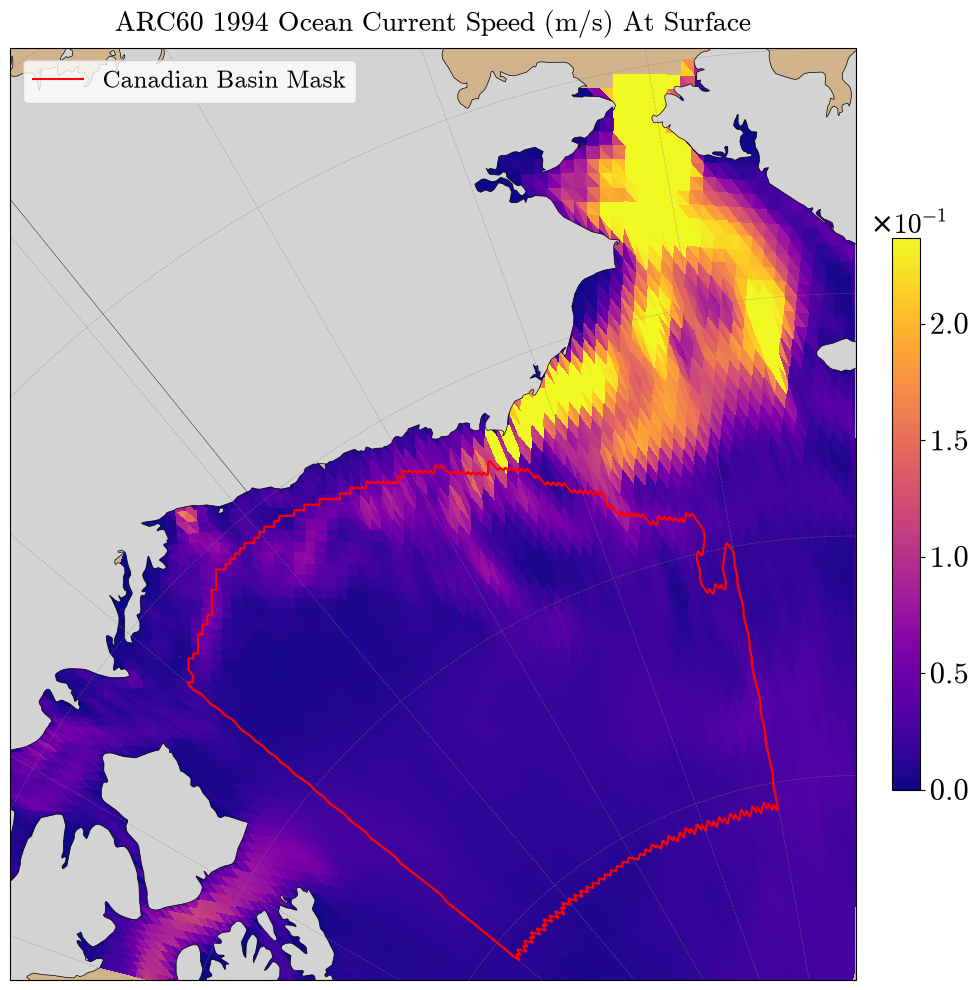

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'ARC60 1994 Ocean Current Speed (m/s) At Surface'}>)

In [7]:
speedField(1994, depth=0, integrated=False, cropped=True) # 1994 yearly avg at the surface (0 m) in the Bounding Box
graphFunction('speed_1994_0', show_mask=True, step=32) # show_mask shows the Canadian Basin Mask contour in the map

Already exists — skipping: full_eke_1998_50_int.npz
Loading full_eke_1998_50_int.npz ...
Loading cached triangulation from triangulation_step32_7025x7500.pkl ...


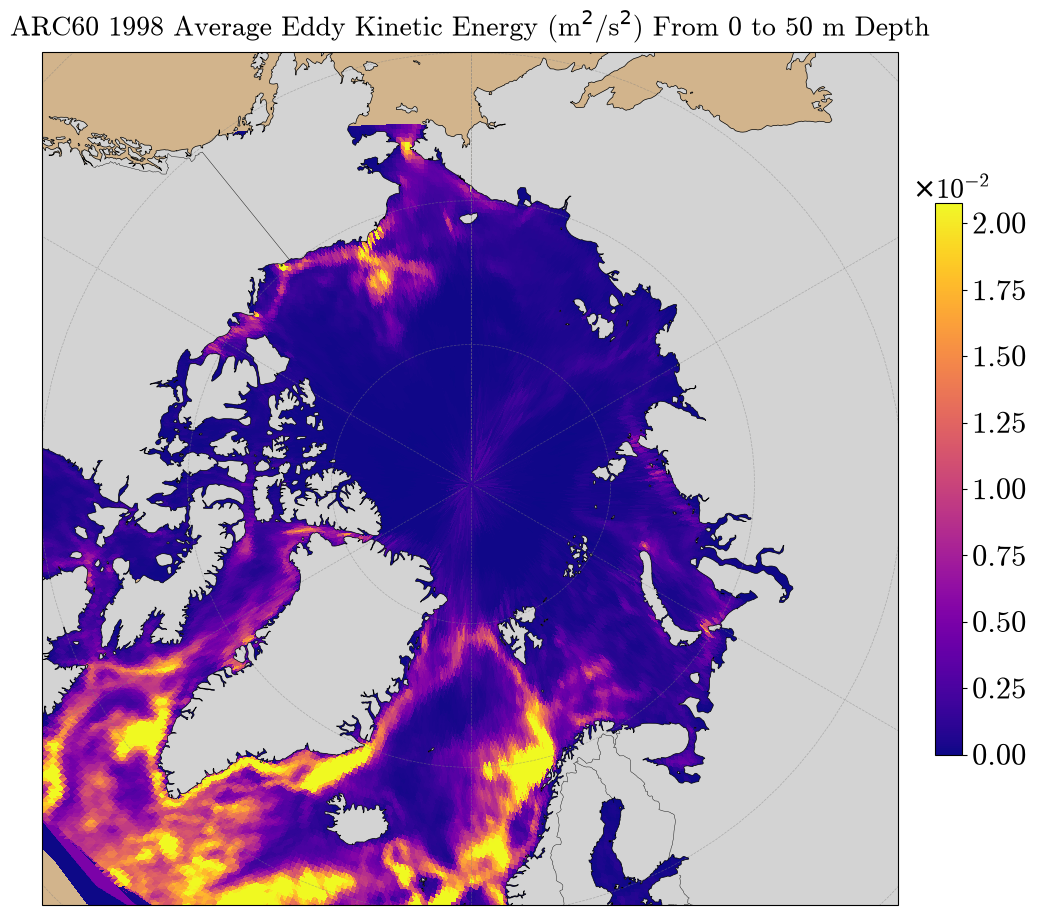

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'ARC60 1998 Average Eddy Kinetic Energy (m$^2$/s$^2$) From 0 to 50 m Depth'}>)

In [8]:
ekeField(1998, depth=50, integrated=True, cropped=False) # 1998 average depth weighted eke field between 0 and 50 m over the whole ARC60 domain 
graphFunction('full_eke_1998_50_int', step=32, full=True) # when graphing a Field over the whole domain full=True

### FWT Spatial Fields and Timeseries Plots

the `fwtField()` receives the same arguments as `speedField()` and `ekeField()` except for `depth` and `integrated` as it is simply a 2D variable. The timeseries generated is simply the average over the canadian basin for each day of the year and could be generated with:

Already exists — skipping: timeseries_fwt_1994.npz
Already exists — skipping: timeseries_fwt_1995.npz
Already exists — skipping: timeseries_fwt_1996.npz
Already exists — skipping: timeseries_fwt_1997.npz
Already exists — skipping: timeseries_fwt_1998.npz
Already exists — skipping: timeseries_fwt_1999.npz
Loading timeseries: fwt348  depth=None  integrated=False
  2186 daily values (1994-01-01 → 1999-12-31)


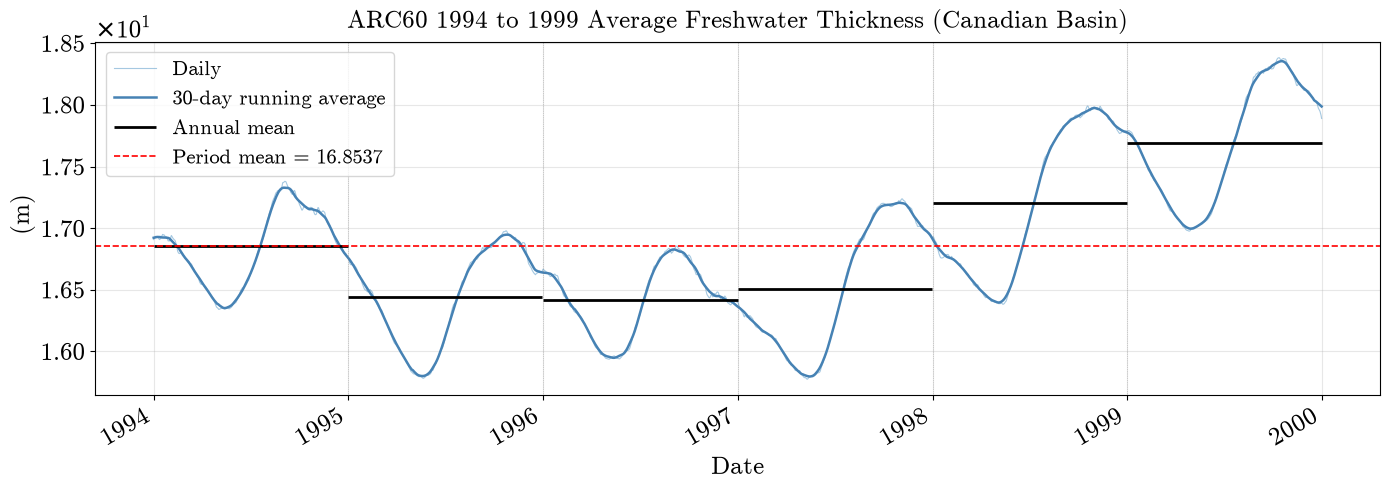

(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'ARC60 1994 to 1999 Average Freshwater Thickness (Canadian Basin)'}, xlabel='Date', ylabel=' (m)'>)

In [9]:
for year in range(YEAR_START, YEAR_END + 1): # if we want to extend any of the analysis to 2000 or 2001 we must  
    fwtField(year, timeseries=True)          # simply change YEAR_END=2000 or YEAR_END=2001 in cell 1
graphTimeseriesMultiyear('fwt348', show_mean=True, show_monthly=True, show_annual_means=True) 
#show_mean: red line, show_monthly: blue line, show_annual_means: black lines

### Vertical Profiles

The vertical profiles are generated simply by calling `speedVerticalProfile(timePeriod)` or `ekeVerticalProfile(timePeriod)` and passing the corresponding timeperiod which can be either a season string as in `'OND'` or a year int as `1995`. They are then graphed with graphVerticalProfile() that only receives the file name string. For example:

Already exists — skipping: vprofile_speed_OND.npz


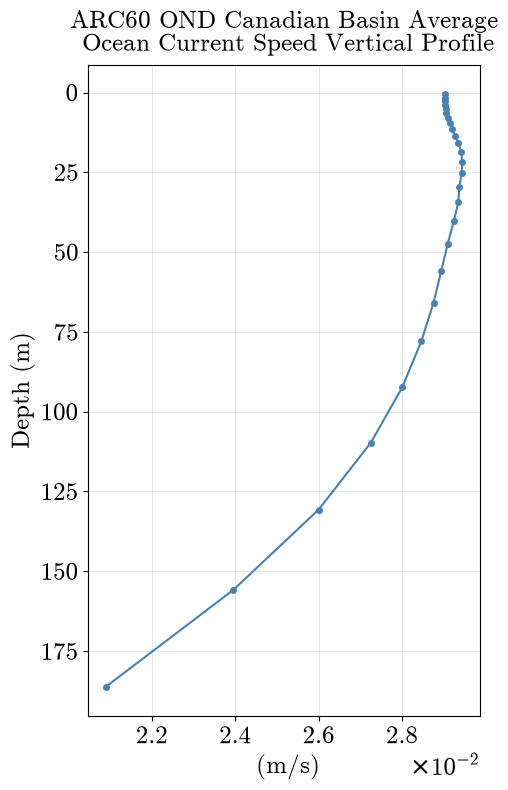

(<Figure size 500x800 with 1 Axes>,
 <Axes: title={'center': 'ARC60 OND Canadian Basin Average\n Ocean Current Speed Vertical Profile'}, xlabel=' (m/s)', ylabel='Depth (m)'>)

In [10]:
speedVerticalProfile('OND')
graphVerticalProfile('vprofile_speed_OND')

### Satellite Data Spatial Fields

The Satellite data was downloaded from https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_MY_008_047/services

Satellite Geostrophic Speed and Sea Level Anomaly Standard Deviation fields can be generated with `satSpeedField()` and `satSLAStd()` they receive:
* `timePeriod`: which can generate yearly, seasonal and now monthly time averages passed as strings as in `'Jan'` or `'Aug'`
* `mask_ice`: when `False` does nothing, when `True` generates an additional .npz file with an `'_icemask'` suffix that stores the points that where always ice covered during the correponding time period passed.
* `cropped`: works the same as in the speed, eke and fwt fields.

Here is some example of how to graph this data with `graphSatField()`

Already exists — skipping: sat_sla_std_Jul.npz
Loading sat_sla_std_Jul.npz ...


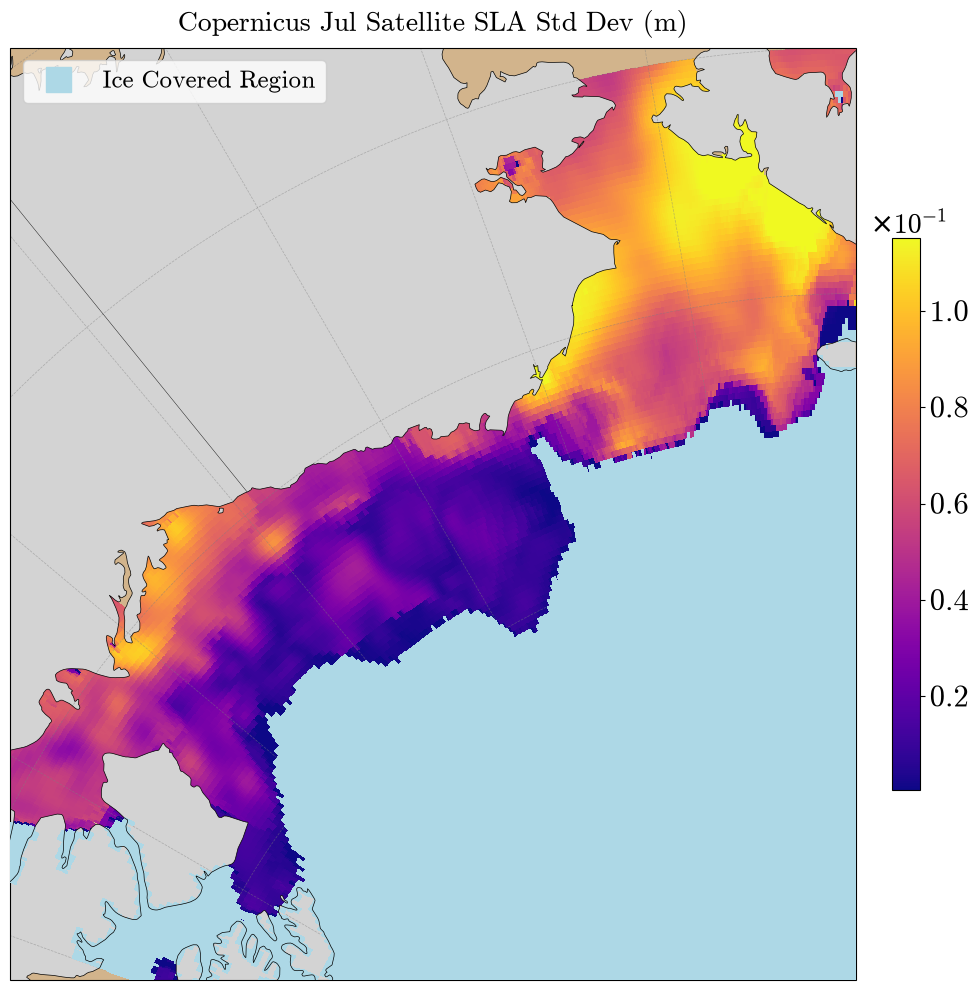

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Copernicus Jul Satellite SLA Std Dev (m)'}>)

In [11]:
satSLAStd('Jul', mask_ice=True) # Jul average Satellite SLA Standard Deviation, with ice_maks generated
graphSatField('sat_sla_std_Jul', show_ice=True) # show_ice=True shows the always ice covered region

### Model Geostrophic Speed and Model-Sat Graph Comparisons

 modelGeoSpeedField(timePeriod, ice_threshold=0.15, smooth_ssh=False, smooth_km=10, mask_ice=False, cropped=True)
Model Geostrophic Speed Spatial Fields can be generated by calling `modelGeoSpeedField(timePeriod, ice_threshold=0.15, smooth_ssh=False, smooth_km=10, mask_ice=False, cropped=True)` 

The `timePeriod` works exactly as for the Satellite data receiving years, seasons and months. The same for`cropped` and `mask_ice` variables, which generates an icemask .npz for pixels with over 15% ice concentration (`ice_threshold=0.15`) over the whole period. When `smooth_ssh=True` it smooths the final geostrophic speed field over 10 km windows (`smooth_km=10`) and adds a `'_smooth10km'` suffix to the file name. Here's an example:

Already exists — skipping: model_geo_speed_1994_smooth10km.npz
Loading model_geo_speed_1994_smooth10km.npz ...


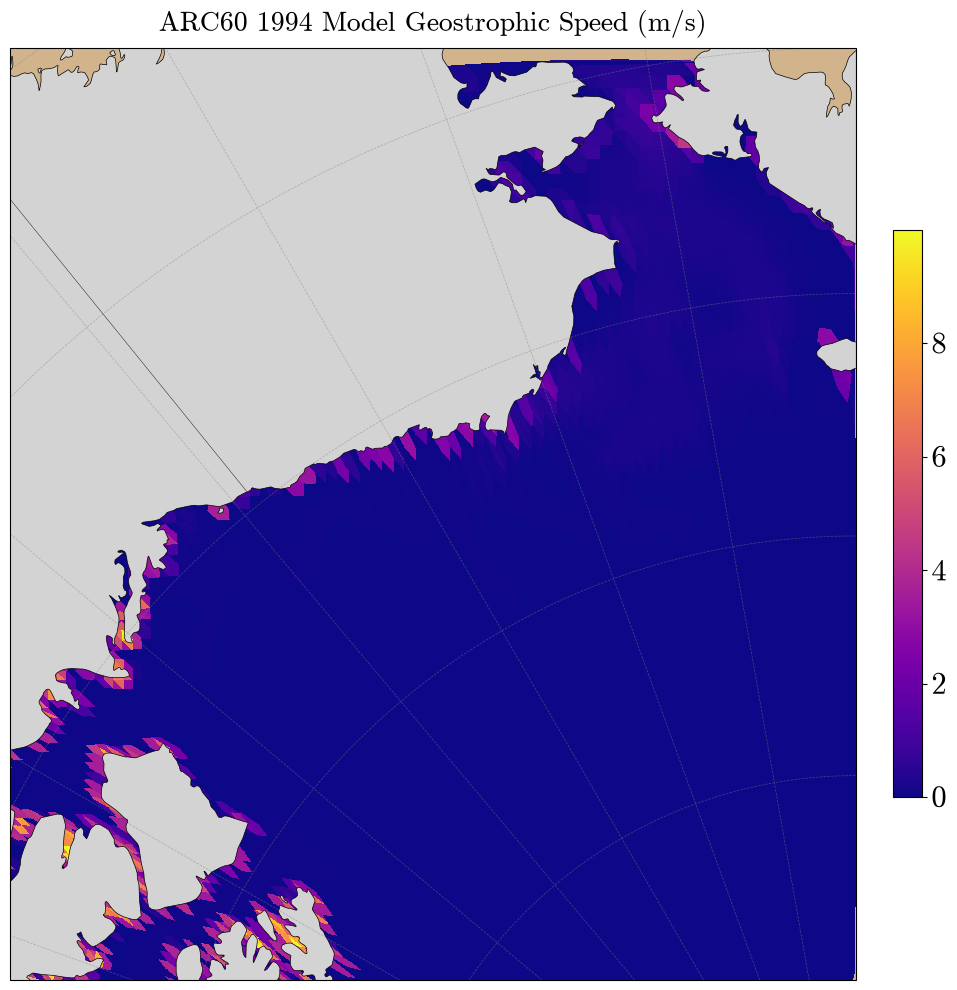

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'ARC60 1994 Model Geostrophic Speed (m/s)'}>)

In [12]:
modelGeoSpeedField(1994, smooth_ssh=True, smooth_km=10) # model geostrophic smoothed over 10km window averages
graphFunction('model_geo_speed_1994_smooth10km', step=32)

To compare directly the model and the satellite geospeed fields use `graphComparison(model_file, sat_file, show_bathy=True)` which receives the names of the corresponding model and satellite .npz files and matches the minimum and maximum value in the color bar of each map and adds a `'_comparison'` suffix to the figure name. Here the `show_bathy` variable masks the regions where the ocean depth is < 100 m when True in both `graphFunction()` and `graphSatField()`. Here is a usage example:

_vmin_model: 0.003009, _vmin_sat: 0.005312, vmin: 0.003009 

_vmax_model: 0.076802, _vmax_sat: 0.099027, vmin: 0.099027 

Loading model_geo_speed_1999.npz ...


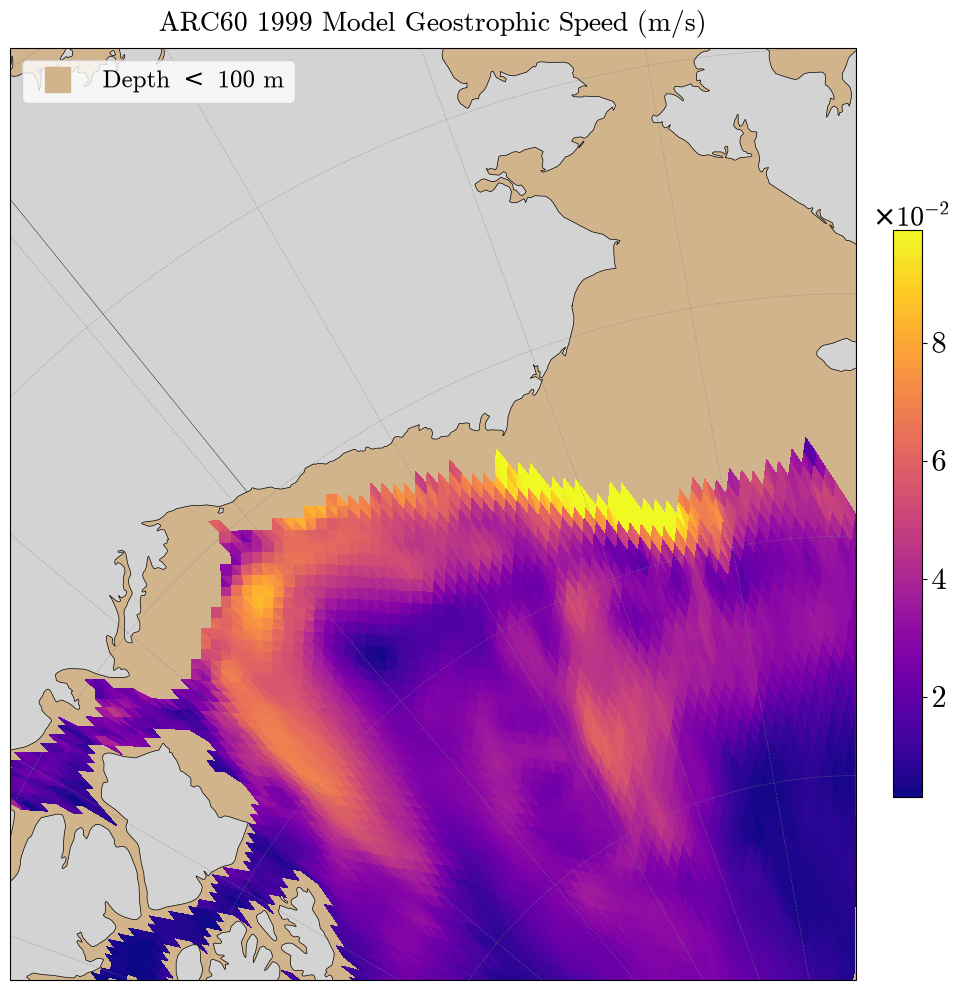

Loading sat_speed_1999.npz ...


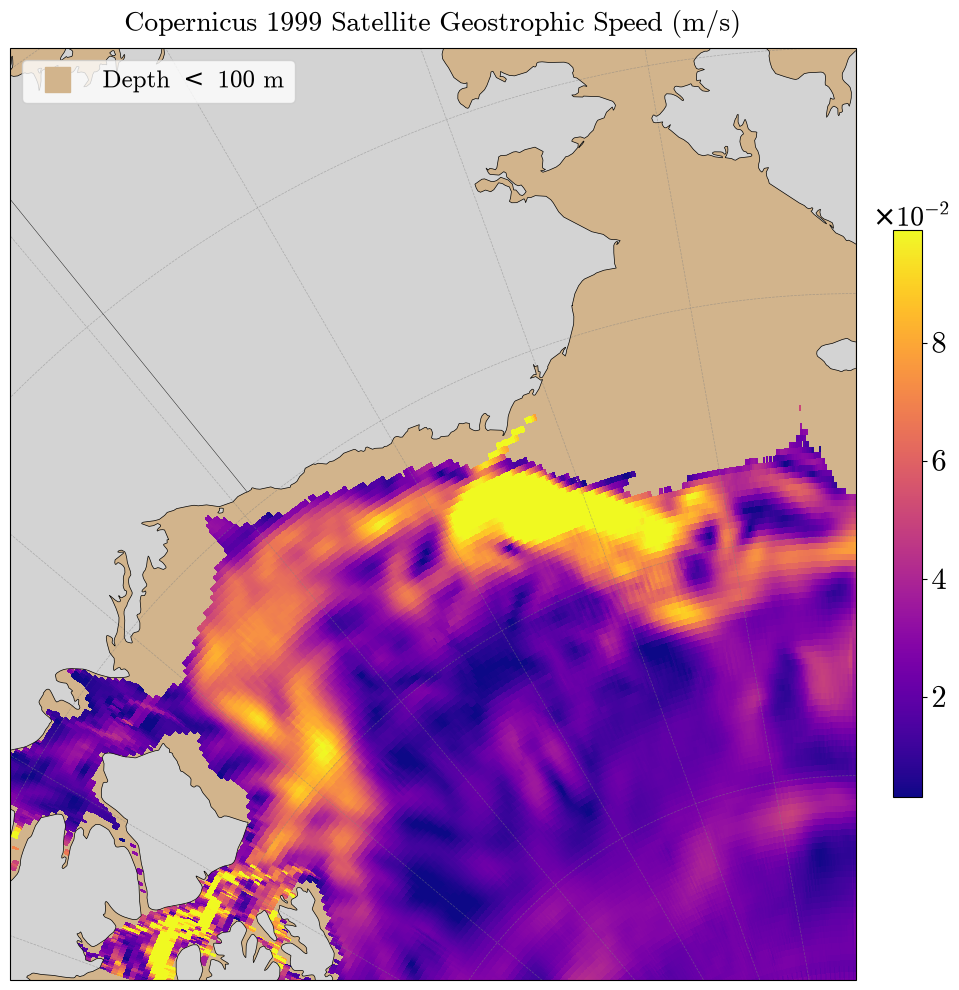

finished both plots


In [13]:
graphComparison('model_geo_speed_1999','sat_speed_1999', show_bathy=True, show=True, save=False, step=32) # show_bathy masks <100 m depth regions

### SSH Standard Deviation and Anomaly Fields

Sea Surface Height Standard Deviation fields can be generated by calling `modelSSHStd(timePeriod, ice_threshold=0.15, cropped=True, mask_ice=False)` and Anomaly Fields with `sshAnomalyField(timePeriod, cropped=True)` all parameters work exactly as explained in the functions before, generating yearly, seasonal and monthly fields. 

For SSH Anomaly fields the mean is calculated exclusively over points where the sea depth is lower than 100 m in the Bounding Box area (`cropped=True`) or in the whole ARC60 domain (`cropped=False`). And as it produces both negative and positive points it is useful to pass `cmap='coolwarm'` to `graphFunction()` that automatically sets the white color to the 0 values when that colormap is given, as shown here:

Already exists — skipping: ssh_anom_Aug.npz
Loading ssh_anom_Aug.npz ...


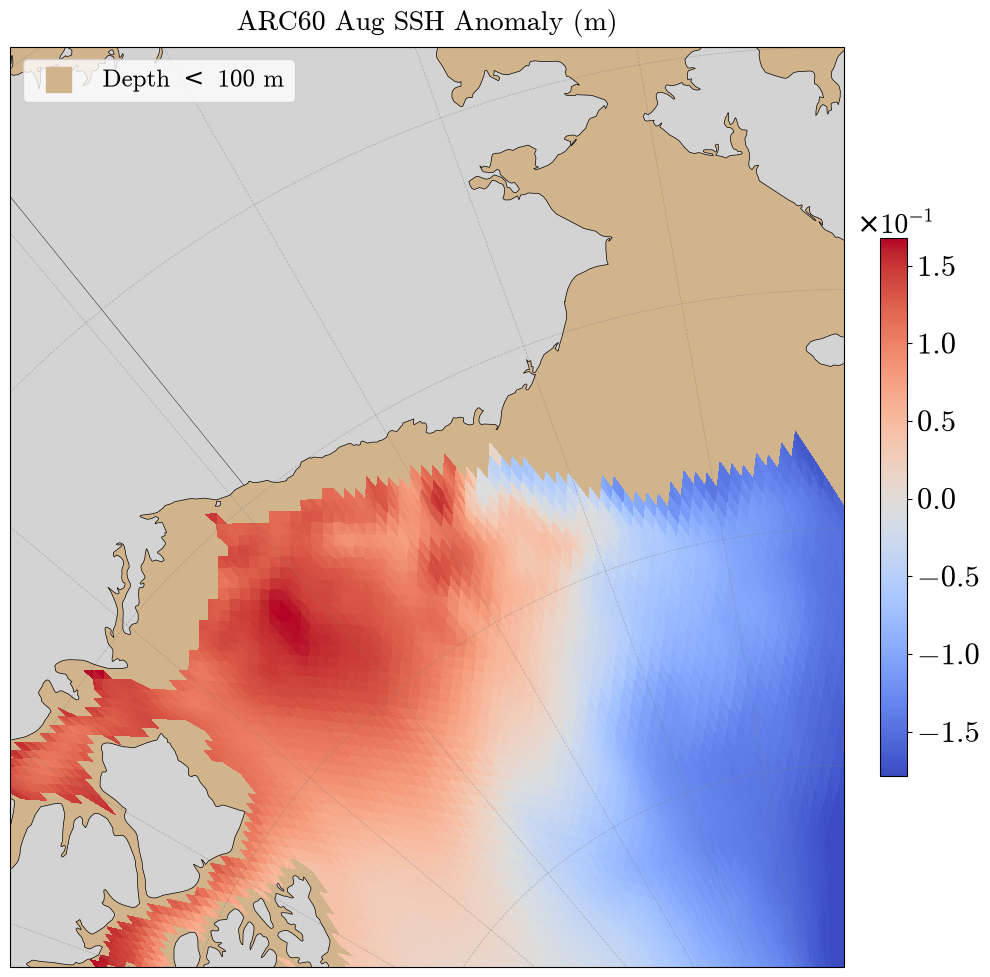

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'ARC60 Aug SSH Anomaly (m)'}>)

In [14]:
sshAnomalyField('Aug')
graphFunction('ssh_anom_Aug', cmap='coolwarm', show_bathy=True, step=32) # use cmap='coolwarm' for positive and negative data 

### First Cole Comparison (Window Averages)

The comparisons with Cole's work where focused on replicating Fig.5 and Fig.7 of that paper. Those figures show measurements done in the canadian basin region of the contribution of different spatial scales to the kinetic energy at different depth levels. To emulate them with the simulation data window averages were done for each point in the *Canadian Basin Mask* (shown in the first figure of the Example Usage section) varying the window lenght over the spatial scales reported in the paper (7, 30, 60, 120 and 240 km) for each depth level until 200 m depth. The function `sovProfiles(timePeriod)` does that for each day and averages over the time period given (year, season or month) saving also the temporal std dev for each point.

After the data is generated simply call graphSOVBandProfiles(timePeriod=None, speed=False) to generate a Fig.5 like figure for the `timePeriod` given, if no `timePeriod` argument is passed to the function it replicates the seasonal averages of the paper separating the Oct-Jun and the Jul-Sep periods. Also if `speed=True` the function shows the speed profiles intead of the KE profiles. It's usage is shown here:

Loading SOV profile: 2001 ...


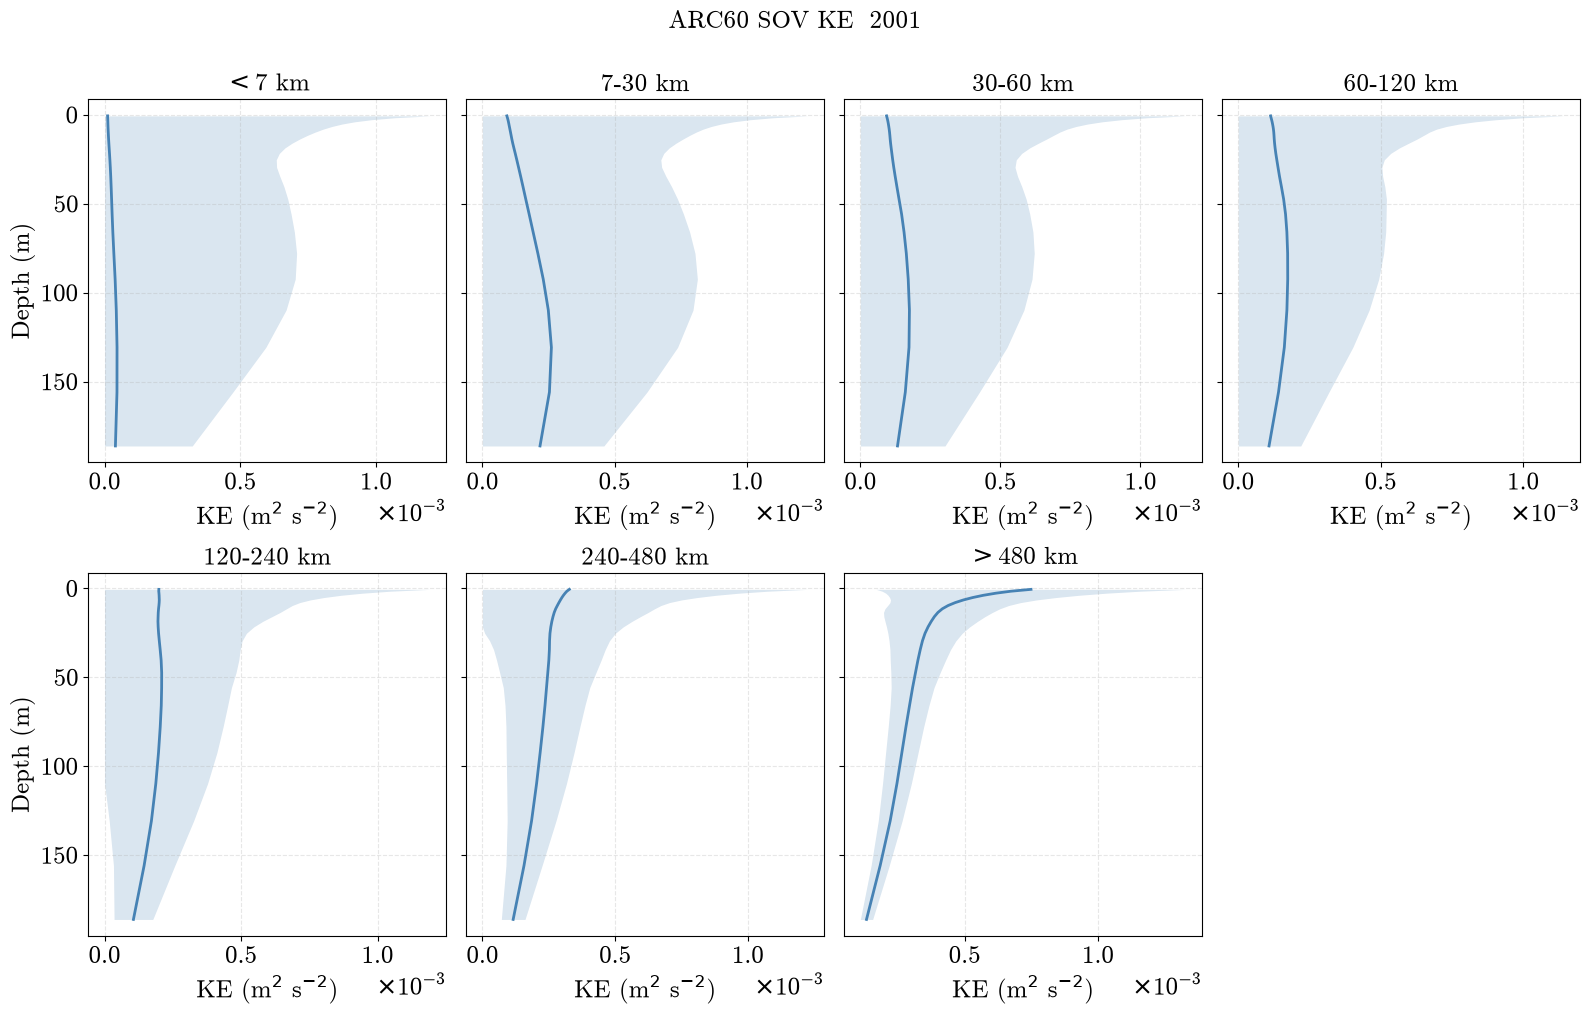

Loading Oct-Jun profiles ...
Loading Jul-Sep profiles ...


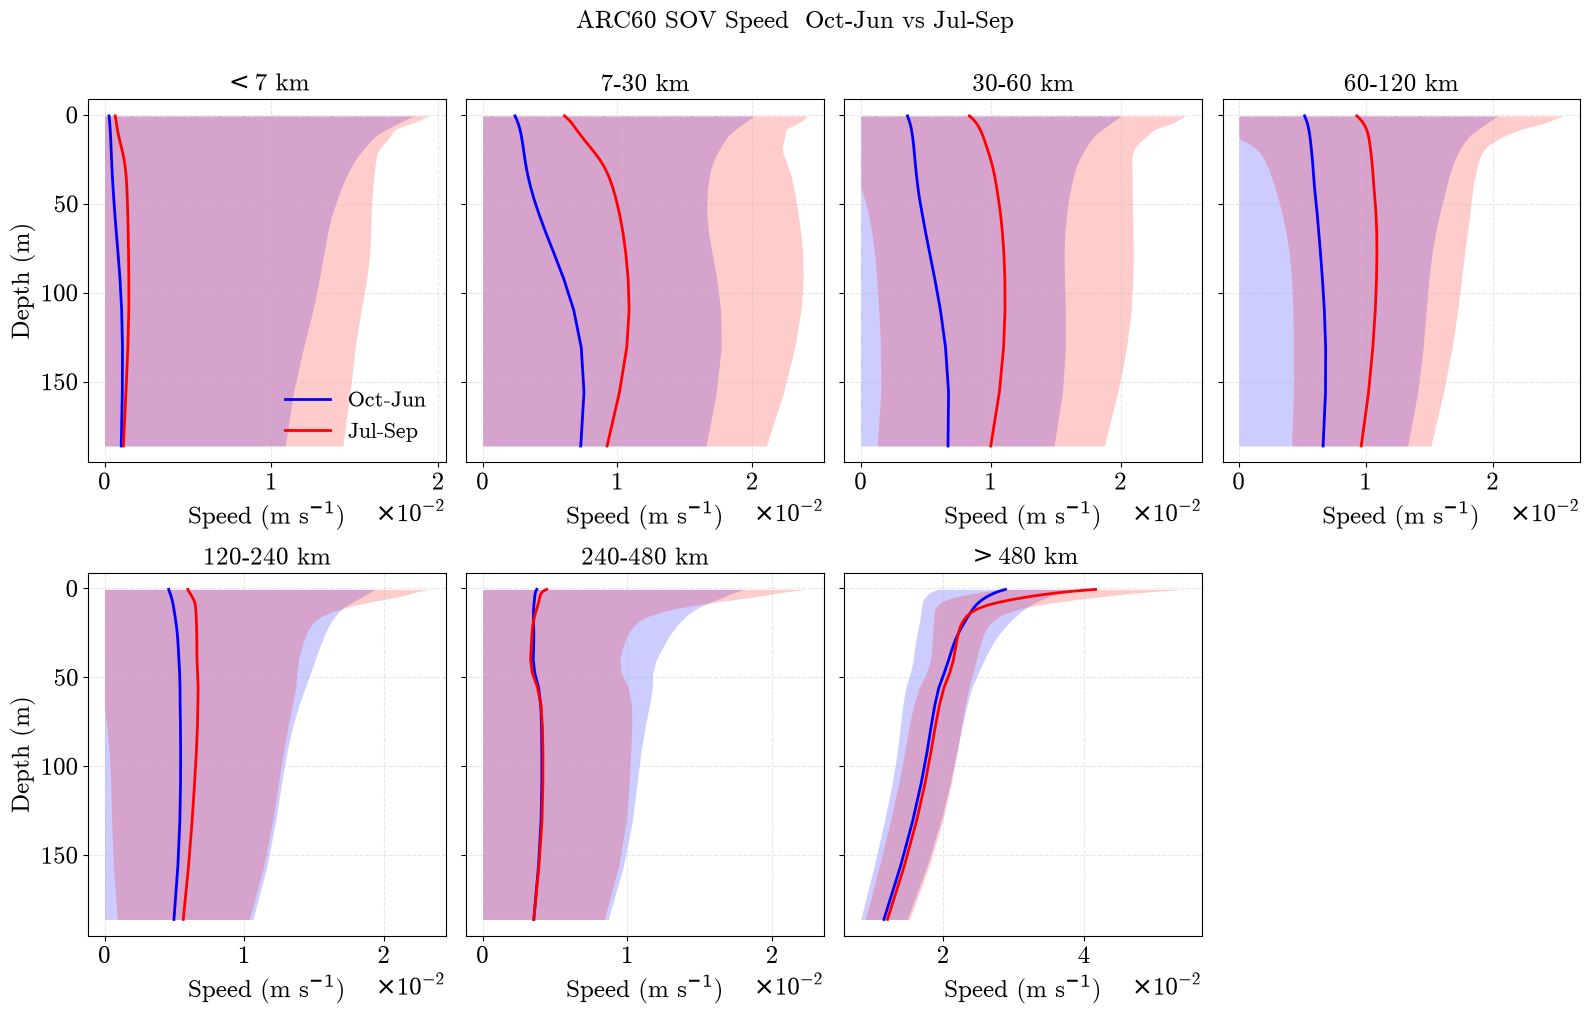

(<Figure size 1600x1000 with 8 Axes>,
 array([[<Axes: title={'center': '$<$7 km'}, xlabel='Speed (m s$^{-1}$)', ylabel='Depth (m)'>,
         <Axes: title={'center': '7-30 km'}, xlabel='Speed (m s$^{-1}$)'>,
         <Axes: title={'center': '30-60 km'}, xlabel='Speed (m s$^{-1}$)'>,
         <Axes: title={'center': '60-120 km'}, xlabel='Speed (m s$^{-1}$)'>],
        [<Axes: title={'center': '120-240 km'}, xlabel='Speed (m s$^{-1}$)', ylabel='Depth (m)'>,
         <Axes: title={'center': '240-480 km'}, xlabel='Speed (m s$^{-1}$)'>,
         <Axes: title={'center': '$>$480 km'}, xlabel='Speed (m s$^{-1}$)'>,
         <Axes: >]], dtype=object))

In [15]:
graphSOVBandProfiles(2001)
graphSOVBandProfiles(speed=True)

Now to generate Fig.7 like figures run `graphSOVFullPanel(timePeriod, speed=False)` which arguments work in the same way as in the previous function. Here's an example.

Loading sov_May.npz ...


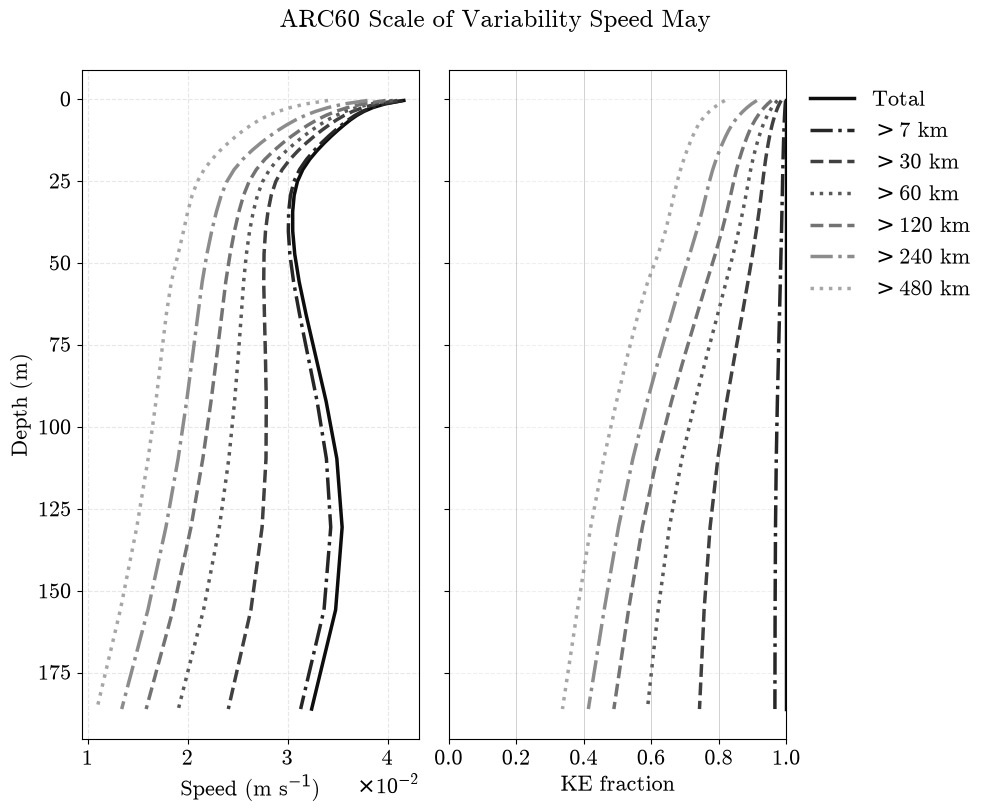

Loading all-seasons profiles ...


findfont: Failed to find font weight bold, now using 400.


Loading Oct-Jun profiles ...
Loading Jul-Sep profiles ...


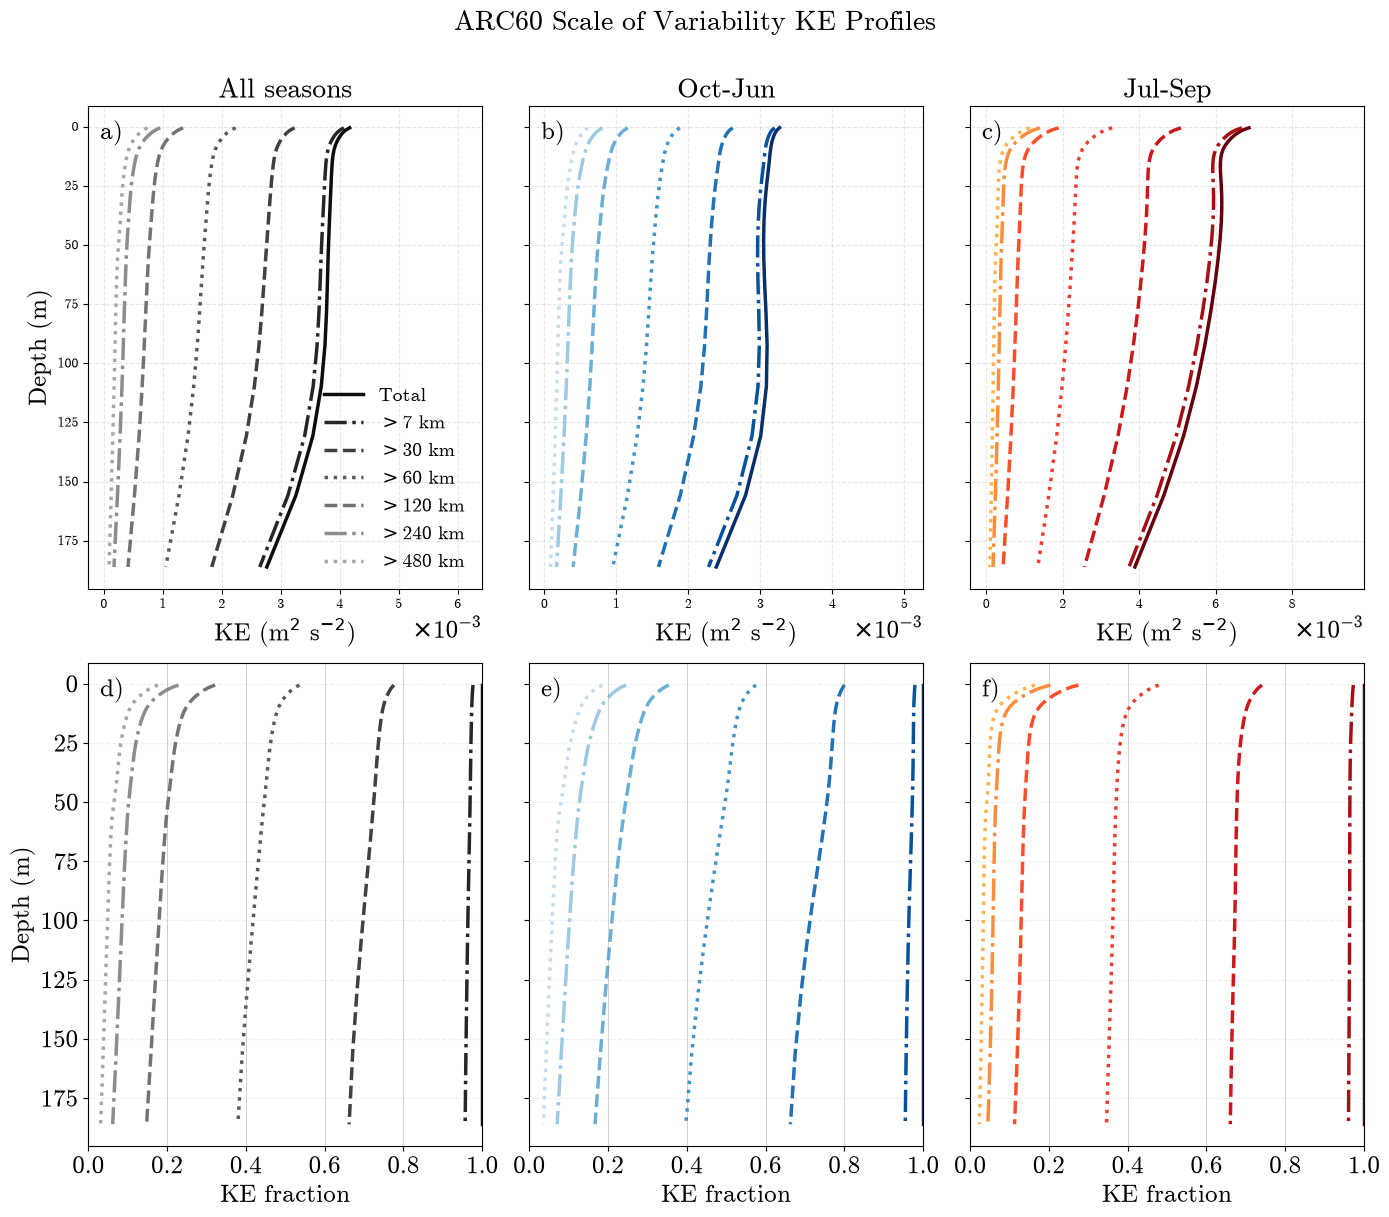

(<Figure size 1400x1200 with 6 Axes>,
 array([[<Axes: title={'center': 'All seasons'}, xlabel='KE (m$^2$ s$^{-2}$)', ylabel='Depth (m)'>,
         <Axes: title={'center': 'Oct-Jun'}, xlabel='KE (m$^2$ s$^{-2}$)'>,
         <Axes: title={'center': 'Jul-Sep'}, xlabel='KE (m$^2$ s$^{-2}$)'>],
        [<Axes: xlabel='KE fraction', ylabel='Depth (m)'>,
         <Axes: xlabel='KE fraction'>, <Axes: xlabel='KE fraction'>]],
       dtype=object))

In [16]:
graphSOVFullPanel('May', speed=True)
graphSOVFullPanel()

### Second Cole Comparison (ITP Tracks)

For this comparison I used the Ice Tethered Profilers' spatial track data (ITP) used by Cole from https://www2.whoi.edu/site/itp/data 
I saved the .dat file with hourly buoy location data for each of the ITPs mentioned in the paper in .txt files inside the processedData/itp_transects/ folder. With those files there I then ran `buildITPTransect()` for each ITP to store a file that has the positions of the files cut only to the dates mentioned in Table 1 of Cole's paper and that can be graphed via `graphITPTracks()`

Already exists — skipping: itp_070_transect.npz
Already exists — skipping: itp_077_transect.npz
Already exists — skipping: itp_078_transect.npz
Already exists — skipping: itp_079_transect.npz
Already exists — skipping: itp_080_transect.npz
Already exists — skipping: itp_113_transect.npz
Already exists — skipping: itp_114_transect.npz
ITP-70: 7638 / 9030 positions within Table 1 date range (2013-08-25 -- 2014-07-15)
ITP-70: 9030 raw -> 320 daily positions
ITP-77: 4886 / 4907 positions within Table 1 date range (2014-03-10 -- 2014-10-02)
ITP-77: 4907 raw -> 207 daily positions
ITP-78: 3442 / 31180 positions within Table 1 date range (2014-03-11 -- 2014-08-06)
ITP-78: 31180 raw -> 148 daily positions
ITP-79: 3377 / 4624 positions within Table 1 date range (2014-03-21 -- 2014-08-11)
ITP-79: 4624 raw -> 144 daily positions
ITP-80: 696 / 9030 positions within Table 1 date range (2014-08-13 -- 2015-05-24)
ITP-80: 9030 raw -> 29 daily positions
ITP-113: 23097 / 73730 positions within Table 1 d

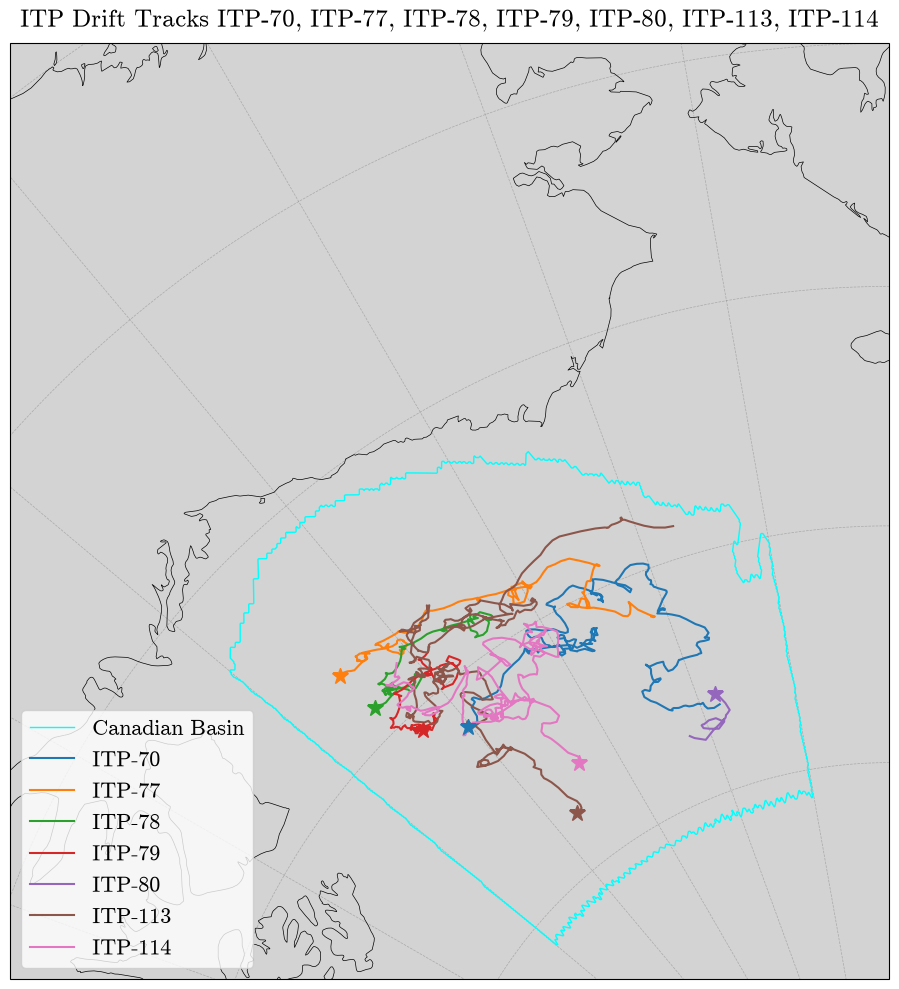

(<Figure size 1000x1000 with 1 Axes>,
 <GeoAxes: title={'center': 'ITP Drift Tracks ITP-70, ITP-77, ITP-78, ITP-79, ITP-80, ITP-113, ITP-114'}>)

In [17]:
for num in [70, 77, 78, 79, 80, 113, 114]:
     buildITPTransect(num)
graphITPTracks((70, 77, 78, 79, 80, 113, 114), show_mask=True)

After haveing those transect files I extracted the U and V data for each day in 1998 and 1999 years (as those are the ones where the Beaufort Gyre starts to be discernible in the model) with `extractTransectModelUV()` and then applied a fourth order butterworth low pass filter for each spatial scale to calculate its contribution with `computeTransectKEProfiles()` as done in the paper. After all the files where generated I finally ran `averageITPKEProfiles()` to generate a single .npz file with the total, Oct-Jul and Jun-Sep averages, I then deleted all intermediate data files. The comparison figure can be generated with `graphITPKEAvgProfiles()`. The following cell shows how this was all implemented:

dict_keys(['total', '7', '30', '60', '120', '240', '480'])


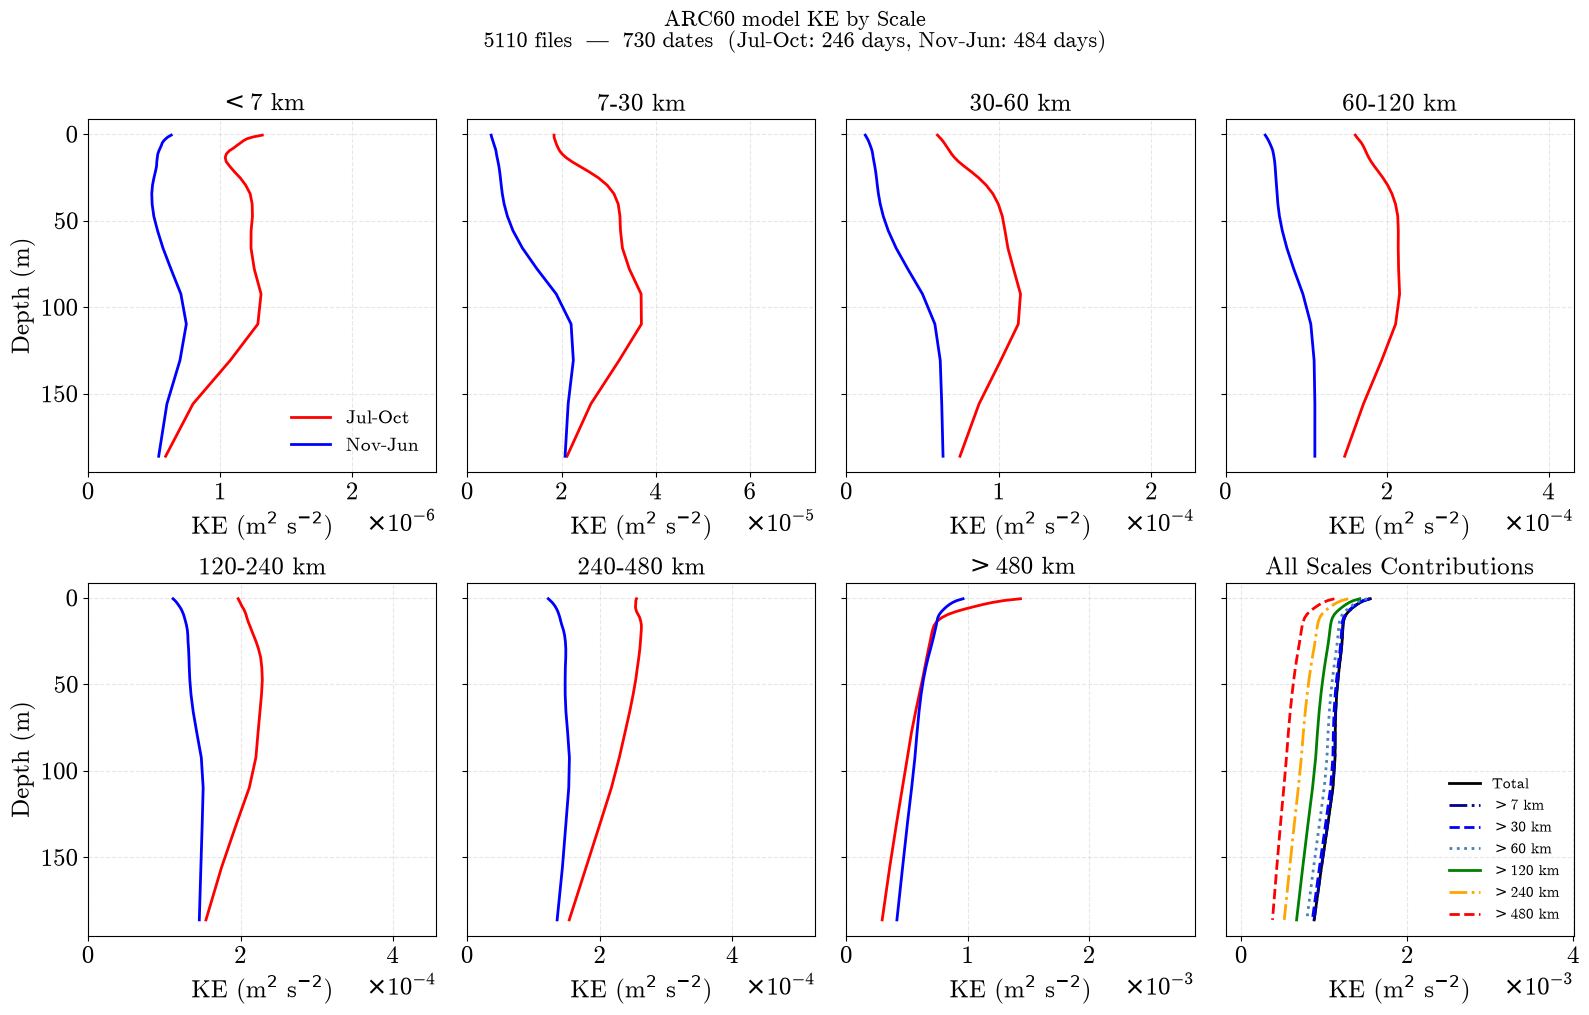

(<Figure size 1600x1000 with 8 Axes>,
 array([[<Axes: title={'center': '$<$7 km'}, xlabel='KE (m$^2$ s$^{-2}$)', ylabel='Depth (m)'>,
         <Axes: title={'center': '7-30 km'}, xlabel='KE (m$^2$ s$^{-2}$)'>,
         <Axes: title={'center': '30-60 km'}, xlabel='KE (m$^2$ s$^{-2}$)'>,
         <Axes: title={'center': '60-120 km'}, xlabel='KE (m$^2$ s$^{-2}$)'>],
        [<Axes: title={'center': '120-240 km'}, xlabel='KE (m$^2$ s$^{-2}$)', ylabel='Depth (m)'>,
         <Axes: title={'center': '240-480 km'}, xlabel='KE (m$^2$ s$^{-2}$)'>,
         <Axes: title={'center': '$>$480 km'}, xlabel='KE (m$^2$ s$^{-2}$)'>,
         <Axes: title={'center': 'All Scales Contributions'}, xlabel='KE (m$^2$ s$^{-2}$)'>]],
       dtype=object))

In [18]:
# the following section is commented to stop it from generating all the intemediate data files again:
"""
for num in [70, 77, 78, 79, 80, 113, 114]:
     for date in common_dates:
         if date.year == (1998 or 1999):
             try:
                 extractTransectModelUV(num, f'y{date.year:04d}m{date.month:02d}d{date.day:02d}')
                 computeTransectKEProfiles(num, f'y{date.year:04d}m{date.month:02d}d{date.day:02d}')
             except Exception as e:
                 print(f"  Failed ITP-{num} {date}: {e}")
averageITPKEProfiles()
"""
graphITPKEAvgProfiles()

### Von Appen Comparison

The moorings data used to create the Von Appen Fig.3 like figure is available a https://doi.pangaea.de/10.1594/PANGAEA.941165 

The function `graphVonAppenComparison(model_eke_file, depth_min=0, depth_max=200, year_start=None, year_end=None, season=None, full=False)`
takes any previously generated eke .npz file, graphs it as `graphFunction()` would and overlays moorings at depths between `depth_min` and `depth_max` variables and between `year_start` and `year_end`, which when `None` selects all available mooring at the specified depths in the whole dataset. The variable `season` is also useful if one only wants to select moorings over a specific season like `'JAS'` over the whole dataset.

For the last comparison I also generated a depth wheighted mean eke field from 0-200 m depth over 1998 and 1999 years from previously generated fields with `depthWeightedMeanEKE()` function, which was useful for this specific purpose but could be generalized further.

Already exists — skipping: full_eke_1998_1999_dw_mean_0_200.npz
Loading model field: full_eke_1998_1999_dw_mean_0_200.npz
Moorings after filtering: 212  depth 0--200 m  season: All seasons


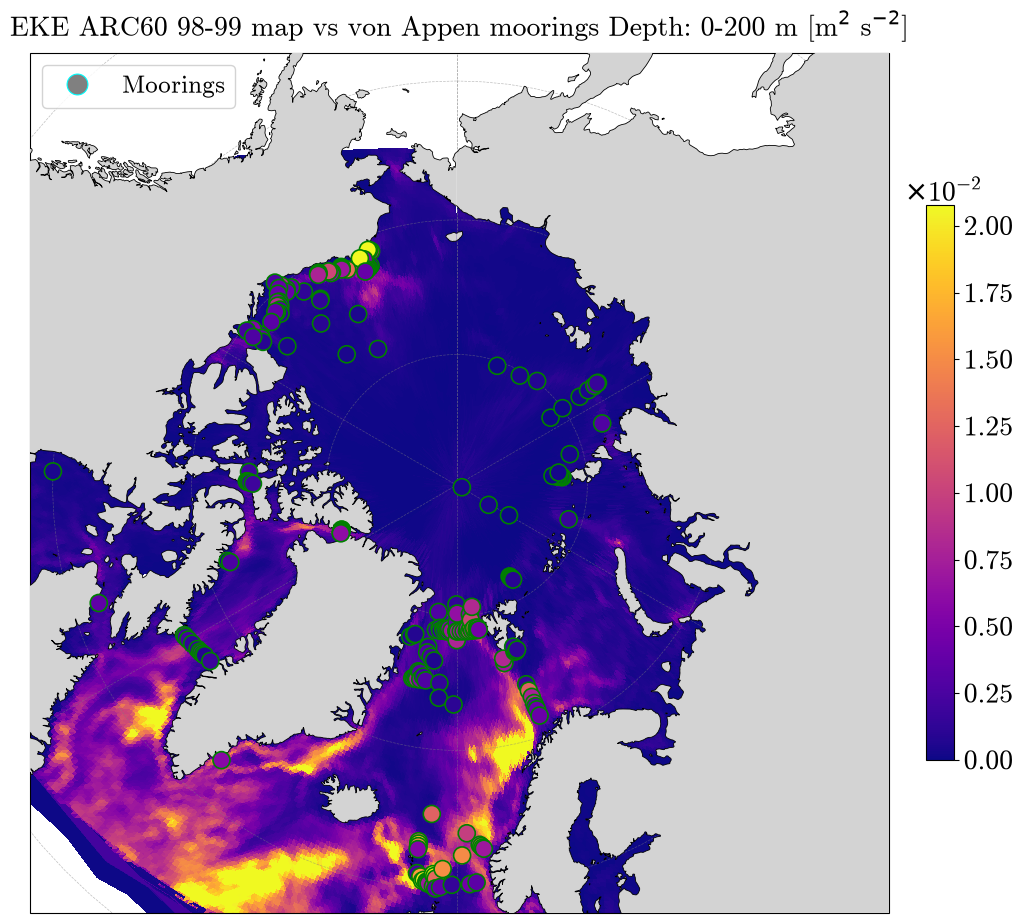

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'EKE ARC60 98-99 map vs von Appen moorings Depth: 0-200 m [m$^2$ s$^{-2}$]'}>)

In [19]:
depthWeightedMeanEKE(
 file_groups=[
         {50: 'full_eke_1998_50_int',
          100: 'full_eke_1998_100_int',
          200: 'full_eke_1998_200_int'},
         {50: 'full_eke_1999_50_int',
          100: 'full_eke_1999_100_int',
          200: 'full_eke_1999_200_int'},
     ],
     out_name='full_eke_1998_1999_dw_mean_0_200',
 )
graphVonAppenComparison('full_eke_1998_1999_dw_mean_0_200', depth_min=0, depth_max=200, step=32, full=True)

### Bering Strait Volume Transport SSH and SSH Anomaly Correlation

I first extracted the dates and volume transport between `year_start` and `year_end` using `loadBeringTransport()`. Then I pass them as arguments to the `beringSSHCorrelation()` function, which also rerceives `anom=True` to calculate the correlation with the SSH Anomaly field, and `anom=False` to calculate the correlation with the raw SSH field. I finally graph it `graphFunction()`

Loaded 2186 Bering transport values
  Mean : 2.845 Sv
  Range: -0.761 – 5.595 Sv
  NaNs : 0
Already exists — skipping: bering_ssh_anom_corr.npz
Loading bering_ssh_anom_corr.npz ...


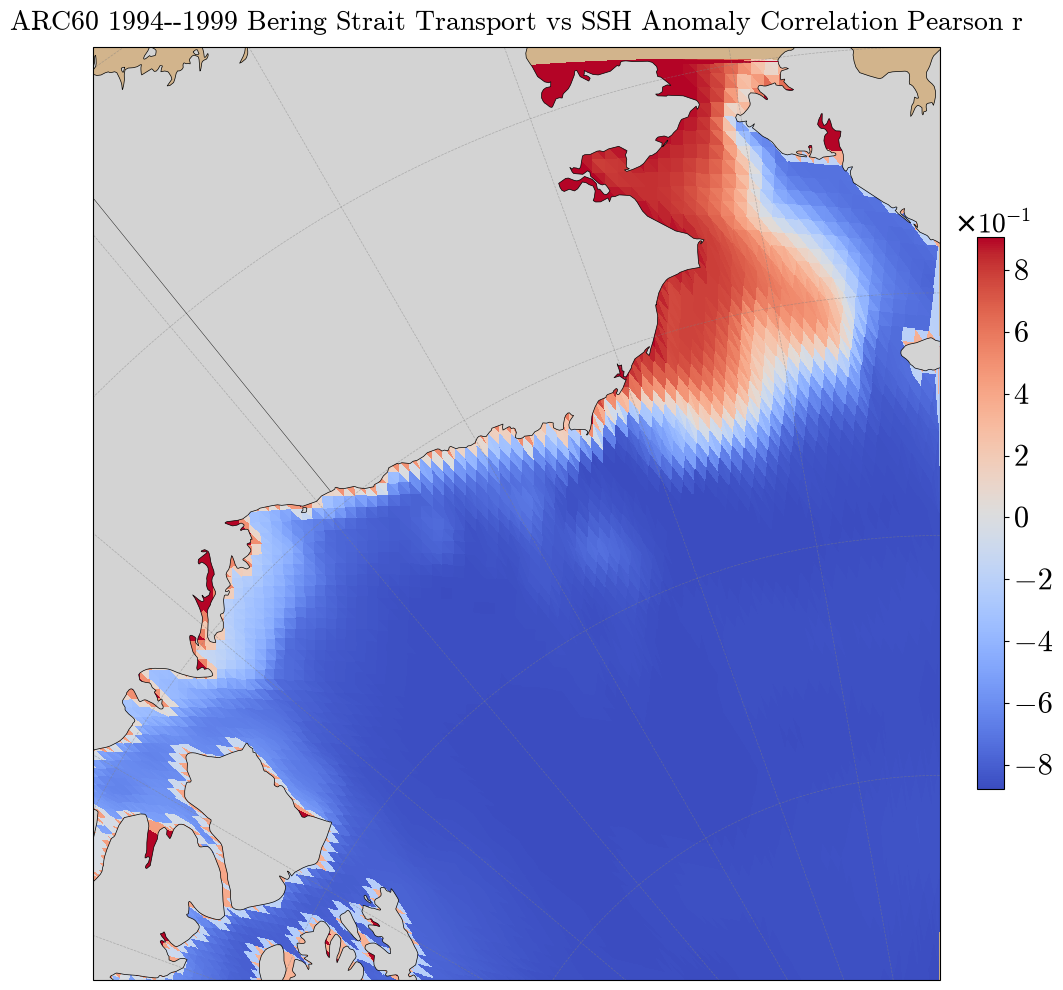

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'ARC60 1994--1999 Bering Strait Transport vs SSH Anomaly Correlation Pearson r'}>)

In [22]:
bering_dates, bering_vol = loadBeringTransport(year_start=1994, year_end=1999)
beringSSHCorrelation(bering_dates, bering_vol, cropped=True, anom=True)
graphFunction('bering_ssh_anom_corr', cmap='coolwarm', step=32)